# Title :  Evaluating Machine Learning and Deep Learning Models for Bank Customer Churn Prediction with Hyperparameter Optimization

# Mounting to the Drive

In [ ]:
# I imported the Google Drive module to access my files stored in Google Drive.
from google.colab import drive

# I mounted my Google Drive to the Colab environment so that I could access the dataset and project files.
drive.mount('/content/drive')

Mounted at /content/drive


# Importing Libraries , Loading the Dataset & Basic Few Operations

In [ ]:
# I imported the Pandas library to perform data manipulation and analysis.
import pandas as pd

# I imported the NumPy library to perform numerical computations.
import numpy as np

# I loaded the dataset from my Google Drive into a Pandas DataFrame.
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Churn_Modelling.csv')

# I displayed a confirmation message after successfully loading the dataset.
print("Dataset loaded successfully!")

# I displayed the number of rows and columns in the dataset.
print("Shape of dataset:", df.shape)

# I displayed a heading before viewing the first five records.
print("\nFirst 5 rows:\n")

# I displayed the first five rows of the dataset to inspect the data.
print(df.head())

# I displayed a heading before viewing the dataset information.
print("\nDataset Information:")

# I displayed the column names, data types, non-null values, and memory usage of the dataset.
print(df.info())

# I displayed a heading before viewing the descriptive statistics.
print("\nDescriptive Statistics:")

# I displayed summary statistics for all numerical columns in the dataset.
print(df.describe())

Dataset loaded successfully!
Shape of dataset: (10000, 14)

First 5 rows:

   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       

# Data Inspection

In [ ]:
# I imported the Matplotlib library for data visualization.
import matplotlib.pyplot as plt

# I imported the Seaborn library for statistical data visualization.
import seaborn as sns

# I printed the total number of observations (rows) in the dataset.
print("Number of observations (rows):", df.shape[0])

# I printed the total number of features (columns) in the dataset.
print("Number of features (columns):", df.shape[1])

# I printed the names of all features available in the dataset.
print("\nFeature Names:\n", df.columns.tolist())

# I identified all columns that contained exactly two unique values.
binary_cols = [col for col in df.columns if df[col].nunique() == 2]

# I detected the target (dependent) variable by selecting the last binary column, if available.
target_var = binary_cols[-1] if len(binary_cols) > 0 else None

# I displayed the detected target (dependent) variable.
print("\nDetected Target (Dependent) Variable:", target_var)

# I identified all remaining columns as independent variables.
independent_vars = [col for col in df.columns if col != target_var]

# I displayed the names of the independent variables.
print("\nIndependent Variables:\n", independent_vars)

# I identified all categorical features based on the object data type.
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

# I displayed the total number of categorical features.
print("\nNumber of categorical features:", len(categorical_features))

# I displayed the names of the categorical features.
print("Categorical feature names:", categorical_features)

Number of observations (rows): 10000
Number of features (columns): 14

Feature Names:
 ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Detected Target (Dependent) Variable: Exited

Independent Variables:
 ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

Number of categorical features: 3
Categorical feature names: ['Surname', 'Geography', 'Gender']


# Data Pre-Processing

In [ ]:
# I imported the LabelEncoder class to encode binary categorical features into numerical values.
from sklearn.preprocessing import LabelEncoder

# I imported the Pandas library to perform data manipulation and preprocessing.
import pandas as pd

# I specified the columns that were not useful for predicting customer churn because they
# represented unique identifiers or personal information rather than meaningful predictive features.
cols_to_drop = ['RowNumber', 'CustomerId', 'Surname']

# I removed the irrelevant columns from the dataset to eliminate unnecessary information
# and improve the efficiency of the machine learning models.
df_clean = df.drop(columns=cols_to_drop)

# I displayed the names of the columns that I removed.
print("Dropped Irrelevant Columns:", cols_to_drop)

# I displayed the new shape of the dataset after removing the irrelevant columns.
print("New Shape:", df_clean.shape)

# I checked each column for missing values to ensure the dataset was complete before further preprocessing.
print("\nMissing Values:\n", df_clean.isnull().sum())

# I created a LabelEncoder object to convert binary categorical values into numerical values.
le = LabelEncoder()

# I identified all categorical columns in the dataset.
for col in df_clean.select_dtypes(include='object').columns:

    # I checked whether the categorical column contained only two unique values.
    if df_clean[col].nunique() == 2:

        # I applied Label Encoding because binary categories could be represented efficiently
        # using 0 and 1 without increasing the number of features.
        df_clean[col] = le.fit_transform(df_clean[col])

        # I displayed the name of the encoded column.
        print(f"Label Encoded: {col}")

# I applied One-Hot Encoding to multi-class categorical features to convert each category
# into separate binary columns while preventing the machine learning models from assuming
# an ordinal relationship between the categories.
df_clean = pd.get_dummies(df_clean, drop_first=True)

# I displayed the shape of the dataset after applying One-Hot Encoding.
print("\nAfter One-Hot Encoding:", df_clean.shape)

Dropped Irrelevant Columns: ['RowNumber', 'CustomerId', 'Surname']
New Shape: (10000, 11)

Missing Values:
 CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64
Label Encoded: Gender

After One-Hot Encoding: (10000, 12)


# Exploratory Data Analysis

Number of observations (rows): 10000
Number of features (columns): 12

Feature Names:
 ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain']

Dependent Variable: Exited

Independent Variables:
 ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain']

Number of categorical features: 3
Categorical Feature Names: ['Surname', 'Geography', 'Gender']


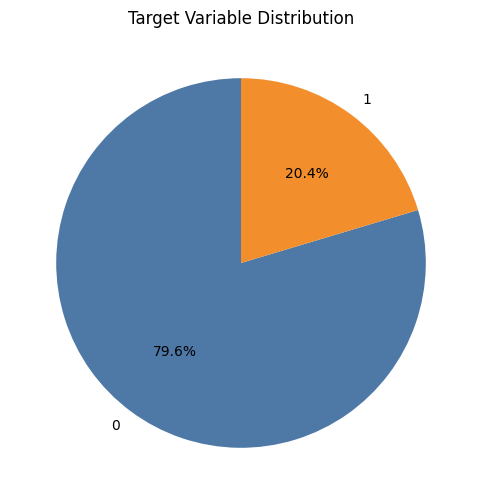

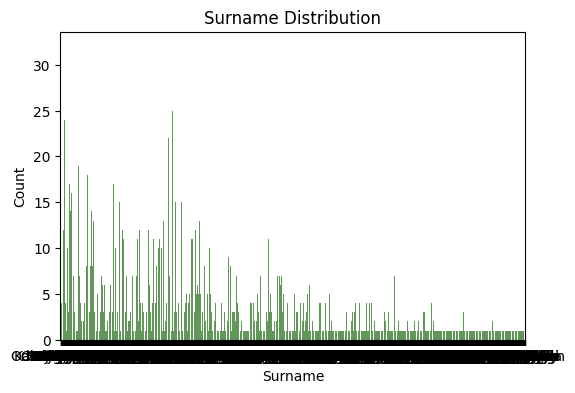

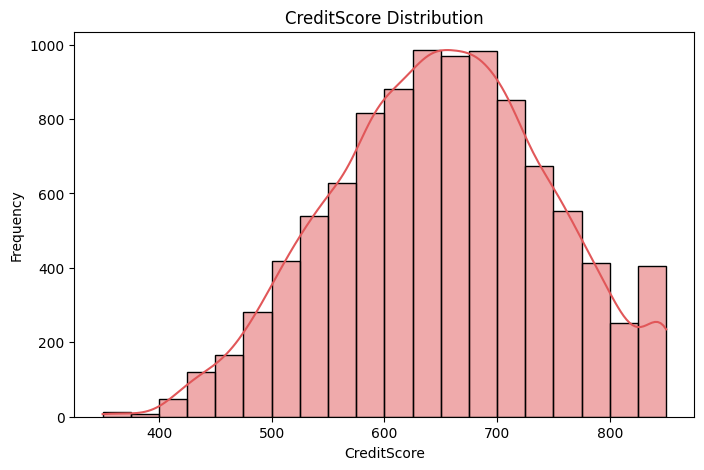

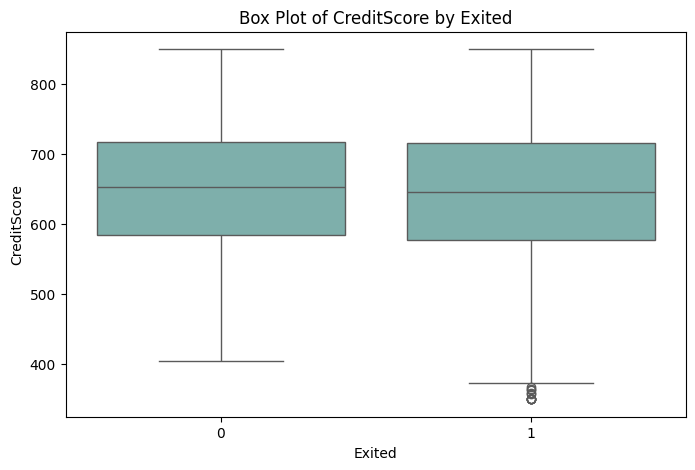

In [ ]:
# I imported the Matplotlib library to create data visualizations.
import matplotlib.pyplot as plt

# I imported the Seaborn library to create statistical plots.
import seaborn as sns

# I imported the NumPy library to perform numerical operations.
import numpy as np

# I displayed the total number of observations (rows) in the preprocessed dataset.
print("Number of observations (rows):", df_clean.shape[0])

# I displayed the total number of features (columns) in the preprocessed dataset.
print("Number of features (columns):", df_clean.shape[1])

# I displayed the names of all features in the dataset.
print("\nFeature Names:\n", df_clean.columns.tolist())

# I defined the target variable used for prediction.
target_var = "Exited"

# I displayed the name of the dependent variable.
print("\nDependent Variable:", target_var)

# I identified all independent variables by excluding the target variable.
independent_vars = [col for col in df_clean.columns if col != target_var]

# I displayed the names of the independent variables.
print("\nIndependent Variables:\n", independent_vars)

# I identified the categorical features from the original dataset before encoding.
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

# I displayed the total number of categorical features.
print("\nNumber of categorical features:", len(categorical_features))

# I displayed the names of the categorical features.
print("Categorical Feature Names:", categorical_features)

# I plotted the distribution of the target variable using a pie chart.
plt.figure(figsize=(6, 6))
df_clean[target_var].value_counts().plot.pie(
    autopct='%1.1f%%',
    startangle=90,
    colors=['#4E79A7', '#F28E2B']
)
plt.title("Target Variable Distribution")
plt.ylabel("")
plt.show()

# I plotted the distribution of the first categorical feature using a bar chart.
plt.figure(figsize=(6, 4))
sns.countplot(
    x=categorical_features[0],
    data=df,
    color='#59A14F'
)
plt.title(f"{categorical_features[0]} Distribution")
plt.xlabel(categorical_features[0])
plt.ylabel("Count")
plt.show()

# I identified all numerical features in the dataset.
numeric_features = df_clean.select_dtypes(include=np.number).columns.tolist()

# I plotted the distribution of the first numerical feature using a histogram.
plt.figure(figsize=(8, 5))
sns.histplot(
    df_clean[numeric_features[0]],
    bins=20,
    kde=True,
    color='#E15759'
)
plt.title(f"{numeric_features[0]} Distribution")
plt.xlabel(numeric_features[0])
plt.ylabel("Frequency")
plt.show()

# I compared the first numerical feature across the target classes using a box plot.
plt.figure(figsize=(8, 5))
sns.boxplot(
    x=target_var,
    y=numeric_features[0],
    data=df_clean,
    color='#76B7B2'
)
plt.title(f"Box Plot of {numeric_features[0]} by {target_var}")
plt.xlabel(target_var)
plt.ylabel(numeric_features[0])
plt.show()

# Splitting the Dataset & Feature Scaling

In [ ]:
# I imported the required libraries for data splitting and feature scaling.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# I separated the independent variables from the dependent variable.
X = df_clean.drop(target_var, axis=1)
y = df_clean[target_var]

# I displayed the shape of the feature matrix.
print("Shape of X:", X.shape)

# I displayed the shape of the target variable.
print("Shape of y:", y.shape)

# I split the dataset into training and testing sets using an 80:20 ratio while maintaining the class distribution.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# I displayed a confirmation message after completing the train-test split.
print("\nTrain-Test Split Completed Successfully!")

# I displayed the shape of the training feature set.
print("Training Features Shape:", X_train.shape)

# I displayed the shape of the testing feature set.
print("Testing Features Shape:", X_test.shape)

# I displayed the shape of the training target set.
print("Training Target Shape:", y_train.shape)

# I displayed the shape of the testing target set.
print("Testing Target Shape:", y_test.shape)

# I created a StandardScaler object to standardize the numerical feature values.
scaler = StandardScaler()

# I fitted the scaler on the training data and transformed the training features.
X_train_scaled = scaler.fit_transform(X_train)

# I transformed the testing features using the scaler fitted on the training data.
X_test_scaled = scaler.transform(X_test)

# I displayed a confirmation message after completing feature scaling.
print("\nFeature Scaling Completed Successfully!")

# I displayed the shape of the scaled training features.
print("Scaled Training Features Shape:", X_train_scaled.shape)

# I displayed the shape of the scaled testing features.
print("Scaled Testing Features Shape:", X_test_scaled.shape)

Shape of X: (10000, 11)
Shape of y: (10000,)

Train-Test Split Completed Successfully!
Training Features Shape: (8000, 11)
Testing Features Shape: (2000, 11)
Training Target Shape: (8000,)
Testing Target Shape: (2000,)

Feature Scaling Completed Successfully!
Scaled Training Features Shape: (8000, 11)
Scaled Testing Features Shape: (2000, 11)


# Handling Class Imbalance using SMOTE

Class Distribution Before SMOTE:
Exited
0    6370
1    1630
Name: count, dtype: int64

Class Distribution After SMOTE:
Exited
1    6370
0    6370
Name: count, dtype: int64


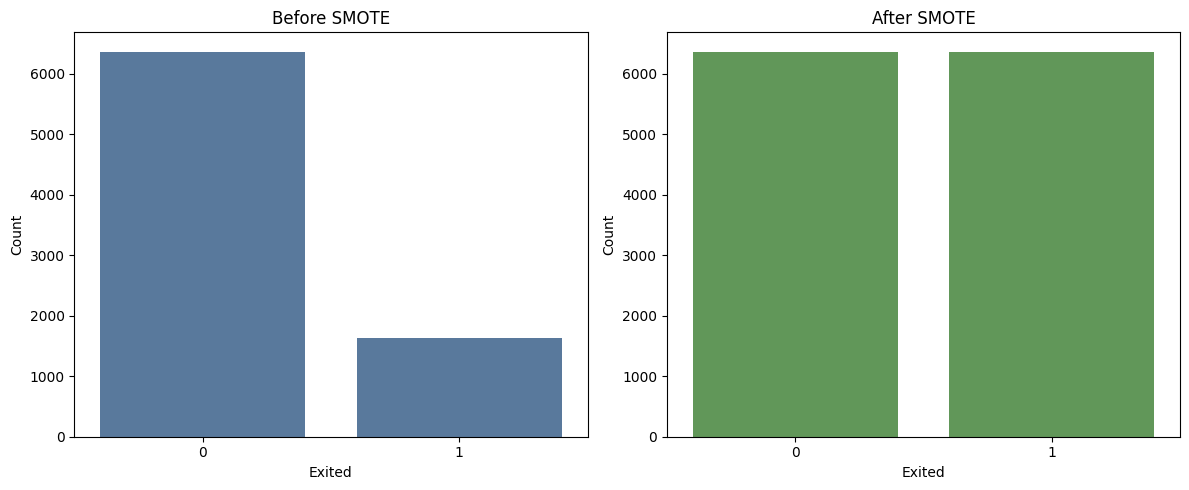


Training Feature Shape Before SMOTE: (8000, 11)
Training Target Shape Before SMOTE: (8000,)

Training Feature Shape After SMOTE: (12740, 11)
Training Target Shape After SMOTE: (12740,)


In [ ]:
# I imported the SMOTE class to balance the minority class in the training dataset.
from imblearn.over_sampling import SMOTE

# I imported the Matplotlib library to create visualizations.
import matplotlib.pyplot as plt

# I imported the Seaborn library to create statistical plots.
import seaborn as sns

# I displayed the class distribution before applying SMOTE to determine whether the training dataset was imbalanced.
print("Class Distribution Before SMOTE:")
print(y_train.value_counts())

# I created a figure to compare the class distributions before and after applying SMOTE.
plt.figure(figsize=(12, 5))

# I plotted the class distribution before applying SMOTE to visualize the imbalance between the classes.
plt.subplot(1, 2, 1)
sns.countplot(x=y_train, color="#4E79A7")
plt.title("Before SMOTE")
plt.xlabel("Exited")
plt.ylabel("Count")

# I created a SMOTE object with a fixed random state to ensure reproducibility.
smote = SMOTE(random_state=42)

# I applied SMOTE only to the training dataset because balancing the training data
# helped reduce the bias towards the majority class while preventing data leakage
# from the testing dataset.
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# I displayed the class distribution after applying SMOTE to verify that both classes
# had become balanced.
print("\nClass Distribution After SMOTE:")
print(y_train_smote.value_counts())

# I plotted the class distribution after applying SMOTE to visually compare it with the original distribution.
plt.subplot(1, 2, 2)
sns.countplot(x=y_train_smote, color="#59A14F")
plt.title("After SMOTE")
plt.xlabel("Exited")
plt.ylabel("Count")

# I adjusted the spacing between the plots to improve readability.
plt.tight_layout()

# I displayed both plots.
plt.show()

# I displayed the shape of the training feature set before applying SMOTE.
print("\nTraining Feature Shape Before SMOTE:", X_train_scaled.shape)

# I displayed the shape of the training target set before applying SMOTE.
print("Training Target Shape Before SMOTE:", y_train.shape)

# I displayed the shape of the balanced training feature set after applying SMOTE.
print("\nTraining Feature Shape After SMOTE:", X_train_smote.shape)

# I displayed the shape of the balanced training target set after applying SMOTE.
print("Training Target Shape After SMOTE:", y_train_smote.shape)

# Training and Evaluating the Models

# Machine Learning Algorithms

# 1. Logistic Regression

Logistic Regression Performance
Accuracy              : 0.7155
Weighted F1-Score     : 0.7399
ROC-AUC Score         : 0.7769
Training Time (s)     : 0.0196
Prediction Time (s)   : 0.007868
Memory Usage (MB)     : 0.081


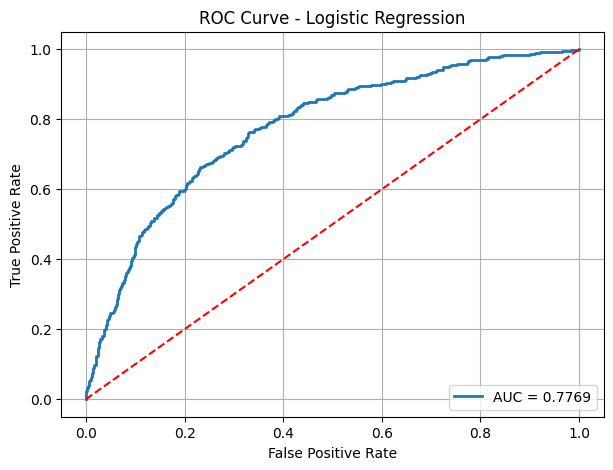

In [ ]:
# I imported the required libraries.
import time
import tracemalloc
import matplotlib.pyplot as plt

# I imported the Logistic Regression classifier.
from sklearn.linear_model import LogisticRegression

# I imported the required evaluation metrics.
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

# I created the Logistic Regression model.
lr_model = LogisticRegression(random_state=42)

# I recorded the starting time before training.
train_start = time.time()

# I trained the Logistic Regression model.
lr_model.fit(X_train_smote, y_train_smote)

# I calculated the training time.
lr_training_time = time.time() - train_start

# I started tracking memory usage.
tracemalloc.start()

# I recorded the starting time before prediction.
predict_start = time.time()

# I predicted the testing dataset.
y_pred_lr = lr_model.predict(X_test_scaled)

# I predicted the probability scores.
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# I calculated the prediction time.
lr_prediction_time = time.time() - predict_start

# I measured the peak memory usage.
current_memory, peak_memory = tracemalloc.get_traced_memory()

# I stopped tracking memory usage.
tracemalloc.stop()

# I converted memory usage into MB.
lr_memory_usage_mb = peak_memory / (1024 * 1024)

# I calculated the evaluation metrics.
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_f1_weighted = f1_score(y_test, y_pred_lr, average="weighted")
lr_auc = roc_auc_score(y_test, y_prob_lr)

# I stored all results for later comparison.
lr_results = {
    "Model": "Logistic Regression",
    "Accuracy": lr_accuracy,
    "Weighted F1-Score": lr_f1_weighted,
    "ROC-AUC": lr_auc,
    "Training Time (s)": lr_training_time,
    "Prediction Time (s)": lr_prediction_time,
    "Memory Usage (MB)": lr_memory_usage_mb
}

# I displayed the results.

print("Logistic Regression Performance")
print("Accuracy              :", round(lr_accuracy, 4))
print("Weighted F1-Score     :", round(lr_f1_weighted, 4))
print("ROC-AUC Score         :", round(lr_auc, 4))
print("Training Time (s)     :", round(lr_training_time, 4))
print("Prediction Time (s)   :", round(lr_prediction_time, 6))
print("Memory Usage (MB)     :", round(lr_memory_usage_mb, 4))

# I calculated the False Positive Rate and True Positive Rate.
fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)

# I plotted the ROC curve.
plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {lr_auc:.4f}")

# I plotted the reference line.
plt.plot([0, 1], [0, 1], linestyle="--", color="red")

# I added the title.
plt.title("ROC Curve - Logistic Regression")

# I labelled the x-axis.
plt.xlabel("False Positive Rate")

# I labelled the y-axis.
plt.ylabel("True Positive Rate")

# I displayed the legend.
plt.legend(loc="lower right")

# I displayed the grid.
plt.grid(True)

# I displayed the ROC curve.
plt.show()

# Cross Validation Results for Logistic Regression

In [ ]:
# I imported the required libraries to perform cross-validation.
from sklearn.model_selection import StratifiedKFold, cross_val_score

# I imported the Logistic Regression classifier.
from sklearn.linear_model import LogisticRegression

# I imported the NumPy library.
import numpy as np

# I created the Logistic Regression model.
log_reg = LogisticRegression(random_state=42)

# I created the Stratified K-Fold object.
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# I performed 5-fold cross-validation.
cv_acc_scores = cross_val_score(
    log_reg,
    X_train_smote,
    y_train_smote,
    cv=cv,
    scoring="accuracy"
)

# I calculated the mean cross-validation accuracy.
lr_cv_mean_accuracy = np.mean(cv_acc_scores)

# I calculated the standard deviation.
lr_cv_std_accuracy = np.std(cv_acc_scores)

# I stored the cross-validation results.
lr_cv_results = {
    "Model": "Logistic Regression",
    "CV Accuracy Scores": cv_acc_scores,
    "Mean CV Accuracy": lr_cv_mean_accuracy,
    "CV Standard Deviation": lr_cv_std_accuracy
}

# I displayed the cross-validation results.
print("Logistic Regression Cross-Validation Accuracy Scores:")
print(cv_acc_scores)

print("\nMean Cross-Validation Accuracy :", round(lr_cv_mean_accuracy, 4))
print("Cross-Validation Standard Deviation :", round(lr_cv_std_accuracy, 4))

Logistic Regression Cross-Validation Accuracy Scores:
[0.70918367 0.71703297 0.71428571 0.7032967  0.72095761]

Mean Cross-Validation Accuracy : 0.713
Cross-Validation Standard Deviation : 0.0062


# 2. Random Forest

Random Forest Performance
Accuracy              : 0.842
Weighted F1-Score     : 0.8419
ROC-AUC Score         : 0.8473
Training Time (s)     : 3.5313
Prediction Time (s)   : 0.212486
Memory Usage (MB)     : 0.1962


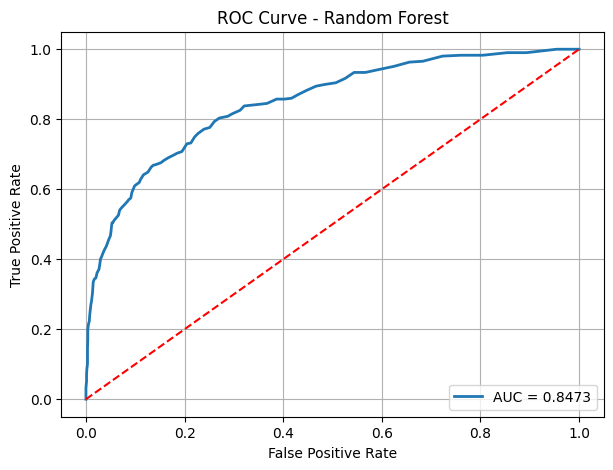

In [ ]:
# I imported the required libraries.
import time
import tracemalloc
import matplotlib.pyplot as plt

# I imported the Random Forest classifier.
from sklearn.ensemble import RandomForestClassifier

# I imported the required evaluation metrics.
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

# I created the Random Forest model with a fixed random state.
rf_model = RandomForestClassifier(
    random_state=42
)

# I recorded the starting time before training.
train_start = time.time()

# I trained the Random Forest model.
rf_model.fit(X_train_smote, y_train_smote)

# I calculated the training time.
rf_training_time = time.time() - train_start

# I started tracking memory usage.
tracemalloc.start()

# I recorded the starting time before prediction.
predict_start = time.time()

# I predicted the testing dataset.
y_pred_rf = rf_model.predict(X_test_scaled)

# I predicted the probability scores.
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# I calculated the prediction time.
rf_prediction_time = time.time() - predict_start

# I measured the peak memory usage.
current_memory, peak_memory = tracemalloc.get_traced_memory()

# I stopped tracking memory usage.
tracemalloc.stop()

# I converted memory usage into MB.
rf_memory_usage_mb = peak_memory / (1024 * 1024)

# I calculated the evaluation metrics.
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_f1_weighted = f1_score(y_test, y_pred_rf, average="weighted")
rf_auc = roc_auc_score(y_test, y_prob_rf)

# I stored all results for later comparison.
rf_results = {
    "Model": "Random Forest",
    "Accuracy": rf_accuracy,
    "Weighted F1-Score": rf_f1_weighted,
    "ROC-AUC": rf_auc,
    "Training Time (s)": rf_training_time,
    "Prediction Time (s)": rf_prediction_time,
    "Memory Usage (MB)": rf_memory_usage_mb
}

# I displayed the results.
print("Random Forest Performance")

print("Accuracy              :", round(rf_accuracy, 4))
print("Weighted F1-Score     :", round(rf_f1_weighted, 4))
print("ROC-AUC Score         :", round(rf_auc, 4))
print("Training Time (s)     :", round(rf_training_time, 4))
print("Prediction Time (s)   :", round(rf_prediction_time, 6))
print("Memory Usage (MB)     :", round(rf_memory_usage_mb, 4))

# I calculated the False Positive Rate and True Positive Rate.
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)

# I plotted the ROC curve.
plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {rf_auc:.4f}"
)

# I plotted the reference line.
plt.plot([0, 1], [0, 1], linestyle="--", color="red")

# I added the title.
plt.title("ROC Curve - Random Forest")

# I labelled the x-axis.
plt.xlabel("False Positive Rate")

# I labelled the y-axis.
plt.ylabel("True Positive Rate")

# I displayed the legend.
plt.legend(loc="lower right")

# I displayed the grid.
plt.grid(True)

# I displayed the ROC curve.
plt.show()

#  Cross Validation Results for Random Forest

In [ ]:
# I imported the required libraries to perform cross-validation.
from sklearn.model_selection import StratifiedKFold, cross_val_score

# I imported the Random Forest classifier.
from sklearn.ensemble import RandomForestClassifier

# I imported the NumPy library.
import numpy as np

# I created the Random Forest model.
rf_model = RandomForestClassifier(random_state=42)

# I created the Stratified K-Fold object.
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# I performed 5-fold cross-validation.
cv_acc_scores_rf = cross_val_score(
    rf_model,
    X_train_smote,
    y_train_smote,
    cv=cv,
    scoring="accuracy"
)

# I calculated the mean cross-validation accuracy.
rf_cv_mean_accuracy = np.mean(cv_acc_scores_rf)

# I calculated the standard deviation.
rf_cv_std_accuracy = np.std(cv_acc_scores_rf)

# I stored the cross-validation results.
rf_cv_results = {
    "Model": "Random Forest",
    "CV Accuracy Scores": cv_acc_scores_rf,
    "Mean CV Accuracy": rf_cv_mean_accuracy,
    "CV Standard Deviation": rf_cv_std_accuracy
}

# I displayed the cross-validation results.
print("Random Forest Cross-Validation Accuracy Scores:")
print(cv_acc_scores_rf)

print("\nMean Cross-Validation Accuracy :", round(rf_cv_mean_accuracy, 4))
print("Cross-Validation Standard Deviation :", round(rf_cv_std_accuracy, 4))

Random Forest Cross-Validation Accuracy Scores:
[0.88422292 0.89599686 0.89992151 0.90345369 0.89050235]

Mean Cross-Validation Accuracy : 0.8948
Cross-Validation Standard Deviation : 0.0068


# 3. XGBoost

XGBoost Performance
Accuracy              : 0.847
Weighted F1-Score     : 0.8413
ROC-AUC Score         : 0.8383
Training Time (s)     : 1.1398
Prediction Time (s)   : 0.043575
Memory Usage (MB)     : 0.0577


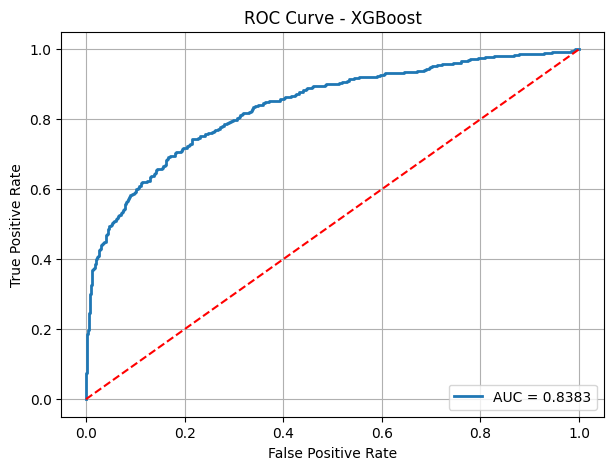

In [ ]:
# I imported the required libraries.
import time
import tracemalloc
import matplotlib.pyplot as plt

# I imported the XGBoost classifier.
from xgboost import XGBClassifier

# I imported the required evaluation metrics.
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

# I created the XGBoost model with a fixed random state.
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

# I recorded the starting time before training.
train_start = time.time()

# I trained the XGBoost model.
xgb_model.fit(X_train_smote, y_train_smote)

# I calculated the training time.
xgb_training_time = time.time() - train_start

# I started tracking memory usage.
tracemalloc.start()

# I recorded the starting time before prediction.
predict_start = time.time()

# I predicted the testing dataset.
y_pred_xgb = xgb_model.predict(X_test_scaled)

# I predicted the probability scores.
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

# I calculated the prediction time.
xgb_prediction_time = time.time() - predict_start

# I measured the peak memory usage.
current_memory, peak_memory = tracemalloc.get_traced_memory()

# I stopped tracking memory usage.
tracemalloc.stop()

# I converted memory usage into MB.
xgb_memory_usage_mb = peak_memory / (1024 * 1024)

# I calculated the evaluation metrics.
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_f1_weighted = f1_score(y_test, y_pred_xgb, average="weighted")
xgb_auc = roc_auc_score(y_test, y_prob_xgb)

# I stored all results for later comparison.
xgb_results = {
    "Model": "XGBoost",
    "Accuracy": xgb_accuracy,
    "Weighted F1-Score": xgb_f1_weighted,
    "ROC-AUC": xgb_auc,
    "Training Time (s)": xgb_training_time,
    "Prediction Time (s)": xgb_prediction_time,
    "Memory Usage (MB)": xgb_memory_usage_mb
}

# I displayed the results.
print("XGBoost Performance")

print("Accuracy              :", round(xgb_accuracy, 4))
print("Weighted F1-Score     :", round(xgb_f1_weighted, 4))
print("ROC-AUC Score         :", round(xgb_auc, 4))
print("Training Time (s)     :", round(xgb_training_time, 4))
print("Prediction Time (s)   :", round(xgb_prediction_time, 6))
print("Memory Usage (MB)     :", round(xgb_memory_usage_mb, 4))

# I calculated the False Positive Rate and True Positive Rate.
fpr, tpr, thresholds = roc_curve(y_test, y_prob_xgb)

# I plotted the ROC curve.
plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {xgb_auc:.4f}"
)

# I plotted the reference line.
plt.plot([0, 1], [0, 1], linestyle="--", color="red")

# I added the title.
plt.title("ROC Curve - XGBoost")

# I labelled the x-axis.
plt.xlabel("False Positive Rate")

# I labelled the y-axis.
plt.ylabel("True Positive Rate")

# I displayed the legend.
plt.legend(loc="lower right")

# I displayed the grid.
plt.grid(True)

# I displayed the ROC curve.
plt.show()

# Cross Validation Results for XGBoost

In [ ]:
# I imported the required libraries to perform cross-validation.
from sklearn.model_selection import StratifiedKFold, cross_val_score

# I imported the XGBoost classifier.
from xgboost import XGBClassifier

# I imported the NumPy library.
import numpy as np

# I created the XGBoost model.
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

# I created the Stratified K-Fold object.
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# I performed 5-fold cross-validation.
cv_acc_scores_xgb = cross_val_score(
    xgb_model,
    X_train_smote,
    y_train_smote,
    cv=cv,
    scoring="accuracy"
)

# I calculated the mean cross-validation accuracy.
xgb_cv_mean_accuracy = np.mean(cv_acc_scores_xgb)

# I calculated the standard deviation.
xgb_cv_std_accuracy = np.std(cv_acc_scores_xgb)

# I stored the cross-validation results.
xgb_cv_results = {
    "Model": "XGBoost",
    "CV Accuracy Scores": cv_acc_scores_xgb,
    "Mean CV Accuracy": xgb_cv_mean_accuracy,
    "CV Standard Deviation": xgb_cv_std_accuracy
}

# I displayed the cross-validation results.
print("XGBoost Cross-Validation Accuracy Scores:")
print(cv_acc_scores_xgb)

print("\nMean Cross-Validation Accuracy :", round(xgb_cv_mean_accuracy, 4))
print("Cross-Validation Standard Deviation :", round(xgb_cv_std_accuracy, 4))

XGBoost Cross-Validation Accuracy Scores:
[0.89246468 0.91208791 0.90620094 0.90620094 0.89756672]

Mean Cross-Validation Accuracy : 0.9029
Cross-Validation Standard Deviation : 0.007


# Deep Learning

# 4. Artificial Neural Network

Artificial Neural Network Performance
Accuracy              : 0.795
Weighted F1-Score     : 0.8081
ROC-AUC Score         : 0.8538
Training Time (s)     : 24.9849
Prediction Time (s)   : 0.759377
Memory Usage (MB)     : 0.3396


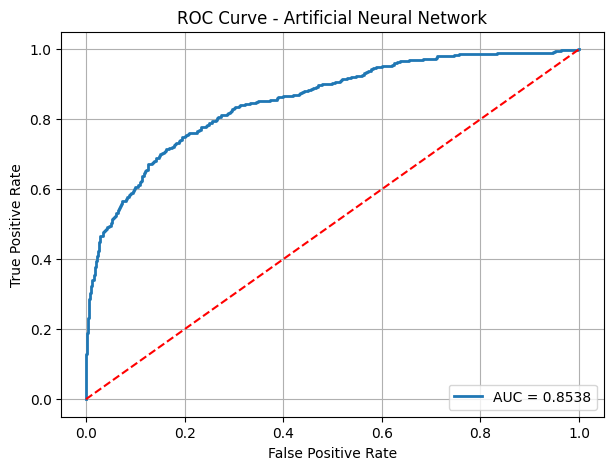

In [ ]:
# I imported the required libraries.
import time
import tracemalloc
import matplotlib.pyplot as plt

# I imported the required TensorFlow libraries.
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense

# I imported the required evaluation metrics.
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

# I created the Artificial Neural Network model.
ann_model = Sequential()

# I added the input layer.
ann_model.add(Input(shape=(X_train_smote.shape[1],)))

# I added the first hidden layer.
ann_model.add(Dense(16, activation='relu'))

# I added the second hidden layer.
ann_model.add(Dense(8, activation='relu'))

# I added the output layer.
ann_model.add(Dense(1, activation='sigmoid'))

# I compiled the Artificial Neural Network model.
ann_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# I recorded the starting time before training.
train_start = time.time()

# I trained the Artificial Neural Network model.
ann_model.fit(
    X_train_smote,
    y_train_smote,
    epochs=20,
    batch_size=32,
    verbose=0
)

# I calculated the training time.
ann_training_time = time.time() - train_start

# I started tracking memory usage.
tracemalloc.start()

# I recorded the starting time before prediction.
predict_start = time.time()

# I predicted the probability scores.
y_prob_ann = ann_model.predict(X_test_scaled, verbose=0)

# I converted the probability scores into binary class predictions.
y_pred_ann = (y_prob_ann > 0.5).astype(int).flatten()

# I calculated the prediction time.
ann_prediction_time = time.time() - predict_start

# I measured the peak memory usage.
current_memory, peak_memory = tracemalloc.get_traced_memory()

# I stopped tracking memory usage.
tracemalloc.stop()

# I converted memory usage into MB.
ann_memory_usage_mb = peak_memory / (1024 * 1024)

# I calculated the evaluation metrics.
ann_accuracy = accuracy_score(y_test, y_pred_ann)
ann_f1_weighted = f1_score(y_test, y_pred_ann, average="weighted")
ann_auc = roc_auc_score(y_test, y_prob_ann)

# I stored all results for later comparison.
ann_results = {
    "Model": "Artificial Neural Network",
    "Accuracy": ann_accuracy,
    "Weighted F1-Score": ann_f1_weighted,
    "ROC-AUC": ann_auc,
    "Training Time (s)": ann_training_time,
    "Prediction Time (s)": ann_prediction_time,
    "Memory Usage (MB)": ann_memory_usage_mb
}

# I displayed the results.
print("=" * 60)
print("Artificial Neural Network Performance")
print("=" * 60)

print("Accuracy              :", round(ann_accuracy, 4))
print("Weighted F1-Score     :", round(ann_f1_weighted, 4))
print("ROC-AUC Score         :", round(ann_auc, 4))
print("Training Time (s)     :", round(ann_training_time, 4))
print("Prediction Time (s)   :", round(ann_prediction_time, 6))
print("Memory Usage (MB)     :", round(ann_memory_usage_mb, 4))

# I calculated the False Positive Rate and True Positive Rate.
fpr, tpr, thresholds = roc_curve(y_test, y_prob_ann)

# I plotted the ROC curve.
plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {ann_auc:.4f}"
)

# I plotted the reference line.
plt.plot([0, 1], [0, 1], linestyle="--", color="red")

# I added the title.
plt.title("ROC Curve - Artificial Neural Network")

# I labelled the x-axis.
plt.xlabel("False Positive Rate")

# I labelled the y-axis.
plt.ylabel("True Positive Rate")

# I displayed the legend.
plt.legend(loc="lower right")

# I displayed the grid.
plt.grid(True)

# I displayed the ROC curve.
plt.show()

# Cross Validation Results for ANN

In [ ]:
# I imported the required libraries to perform cross-validation.
from sklearn.model_selection import StratifiedKFold

# I imported the required evaluation metric.
from sklearn.metrics import accuracy_score

# I imported the TensorFlow libraries.
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense

# I imported the NumPy library.
import numpy as np

# I created the Stratified K-Fold object.
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# I created an empty list to store the accuracy of each fold.
cv_acc_scores_ann = []

# I performed the 5-fold cross-validation.
for train_index, test_index in cv.split(X_train_smote, y_train_smote):

    X_train_fold = X_train_smote[train_index]
    X_test_fold = X_train_smote[test_index]

    y_train_fold = y_train_smote[train_index]
    y_test_fold = y_train_smote[test_index]

    # I created the Artificial Neural Network model.
    ann_cv_model = Sequential()

    # I added the input layer.
    ann_cv_model.add(Input(shape=(X_train_smote.shape[1],)))

    # I added the first hidden layer.
    ann_cv_model.add(Dense(16, activation='relu'))

    # I added the second hidden layer.
    ann_cv_model.add(Dense(8, activation='relu'))

    # I added the output layer.
    ann_cv_model.add(Dense(1, activation='sigmoid'))

    # I compiled the model.
    ann_cv_model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    # I trained the model.
    ann_cv_model.fit(
        X_train_fold,
        y_train_fold,
        epochs=20,
        batch_size=32,
        verbose=0
    )

    # I predicted the validation fold.
    y_pred = ann_cv_model.predict(X_test_fold, verbose=0)

    # I converted probabilities into class labels.
    y_pred = (y_pred > 0.5).astype(int).flatten()

    # I calculated the fold accuracy.
    fold_accuracy = accuracy_score(y_test_fold, y_pred)

    # I stored the fold accuracy.
    cv_acc_scores_ann.append(fold_accuracy)

# I converted the accuracy scores into a NumPy array.
cv_acc_scores_ann = np.array(cv_acc_scores_ann)

# I calculated the mean cross-validation accuracy.
ann_cv_mean_accuracy = np.mean(cv_acc_scores_ann)

# I calculated the standard deviation.
ann_cv_std_accuracy = np.std(cv_acc_scores_ann)

# I stored the cross-validation results.
ann_cv_results = {
    "Model": "Artificial Neural Network",
    "CV Accuracy Scores": cv_acc_scores_ann,
    "Mean CV Accuracy": ann_cv_mean_accuracy,
    "CV Standard Deviation": ann_cv_std_accuracy
}

# I displayed the cross-validation results.
print("Artificial Neural Network Cross-Validation Accuracy Scores:")
print(cv_acc_scores_ann)

print("\nMean Cross-Validation Accuracy :", round(ann_cv_mean_accuracy, 4))
print("Cross-Validation Standard Deviation :", round(ann_cv_std_accuracy, 4))

Artificial Neural Network Cross-Validation Accuracy Scores:
[0.78453689 0.80180534 0.80180534 0.79591837 0.78257457]

Mean Cross-Validation Accuracy : 0.7933
Cross-Validation Standard Deviation : 0.0083


# Comparative Table for all Default Models

In [ ]:
# I imported the Pandas library.
import pandas as pd

# I created the comparison table using the stored results from all models.
comparison_results = pd.DataFrame([
    lr_results,
    rf_results,
    xgb_results,
    ann_results
])

# I rearranged the columns.
comparison_results = comparison_results[
    [
        "Model",
        "Accuracy",
        "Weighted F1-Score",
        "ROC-AUC",
        "Training Time (s)",
        "Prediction Time (s)",
        "Memory Usage (MB)"
    ]
]

# I rounded all numerical values to four decimal places.
comparison_results = comparison_results.round(4)

# I displayed the comparison table.

print("Performance Comparison of Machine Learning and Deep Learning Models")


display(comparison_results)

Performance Comparison of Machine Learning and Deep Learning Models


,Model,Accuracy,Weighted F1-Score,ROC-AUC,Training Time (s),Prediction Time (s),Memory Usage (MB)
0,Logistic Regression,0.7155,0.7399,0.7769,0.0196,0.0079,0.0810
1,Random Forest,0.8420,0.8419,0.8473,3.5313,0.2125,0.1962
2,XGBoost,0.8470,0.8413,0.8383,1.1398,0.0436,0.0577
3,Artificial Neural Network,0.7950,0.8081,0.8538,24.9849,0.7594,0.3396


# Comparative Table for all Cross Validation  Models

In [ ]:
# I imported the Pandas library.
import pandas as pd

# I created the cross-validation comparison table using the stored results.
cv_comparison_results = pd.DataFrame([
    lr_cv_results,
    rf_cv_results,
    xgb_cv_results,
    ann_cv_results
])

# I selected the required columns.
cv_comparison_results = cv_comparison_results[
    [
        "Model",
        "Mean CV Accuracy",
        "CV Standard Deviation"
    ]
]

# I rounded the numerical values to four decimal places.
cv_comparison_results = cv_comparison_results.round(4)

# I displayed the cross-validation comparison table.

print("Cross-Validation Performance Comparison")


display(cv_comparison_results)

Cross-Validation Performance Comparison


,Model,Mean CV Accuracy,CV Standard Deviation
0,Logistic Regression,0.7130,0.0062
1,Random Forest,0.8948,0.0068
2,XGBoost,0.9029,0.0070
3,Artificial Neural Network,0.7933,0.0083


# Comparative Table for all Default and Cross-Validation Models

In [ ]:
# I imported the Pandas library.
import pandas as pd

# I created the combined comparison table.
combined_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Artificial Neural Network"
    ],

    "Accuracy": [
        lr_accuracy,
        rf_accuracy,
        xgb_accuracy,
        ann_accuracy
    ],

    "Weighted F1-Score": [
        lr_f1_weighted,
        rf_f1_weighted,
        xgb_f1_weighted,
        ann_f1_weighted
    ],

    "ROC-AUC": [
        lr_auc,
        rf_auc,
        xgb_auc,
        ann_auc
    ],

    "Training Time (s)": [
        lr_training_time,
        rf_training_time,
        xgb_training_time,
        ann_training_time
    ],

    "Prediction Time (s)": [
        lr_prediction_time,
        rf_prediction_time,
        xgb_prediction_time,
        ann_prediction_time
    ],

    "Memory Usage (MB)": [
        lr_memory_usage_mb,
        rf_memory_usage_mb,
        xgb_memory_usage_mb,
        ann_memory_usage_mb
    ],

    "Mean CV Accuracy": [
        lr_cv_mean_accuracy,
        rf_cv_mean_accuracy,
        xgb_cv_mean_accuracy,
        ann_cv_mean_accuracy
    ],

    "CV Standard Deviation": [
        lr_cv_std_accuracy,
        rf_cv_std_accuracy,
        xgb_cv_std_accuracy,
        ann_cv_std_accuracy
    ]
})

# I rounded the numerical values.
combined_comparison = combined_comparison.round(4)

# I displayed the combined comparison table.

print("Combined Performance Comparison of Machine Learning and Deep Learning Models")

display(combined_comparison)

Combined Performance Comparison of Machine Learning and Deep Learning Models


,Model,Accuracy,Weighted F1-Score,ROC-AUC,Training Time (s),Prediction Time (s),Memory Usage (MB),Mean CV Accuracy,CV Standard Deviation
0,Logistic Regression,0.7155,0.7399,0.7769,0.0196,0.0079,0.0810,0.7130,0.0062
1,Random Forest,0.8420,0.8419,0.8473,3.5313,0.2125,0.1962,0.8948,0.0068
2,XGBoost,0.8470,0.8413,0.8383,1.1398,0.0436,0.0577,0.9029,0.0070
3,Artificial Neural Network,0.7950,0.8081,0.8538,24.9849,0.7594,0.3396,0.7933,0.0083


# Visual Analysis

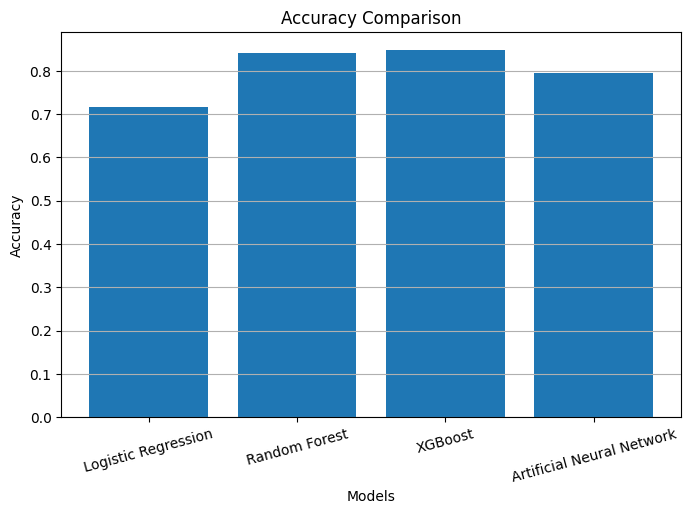

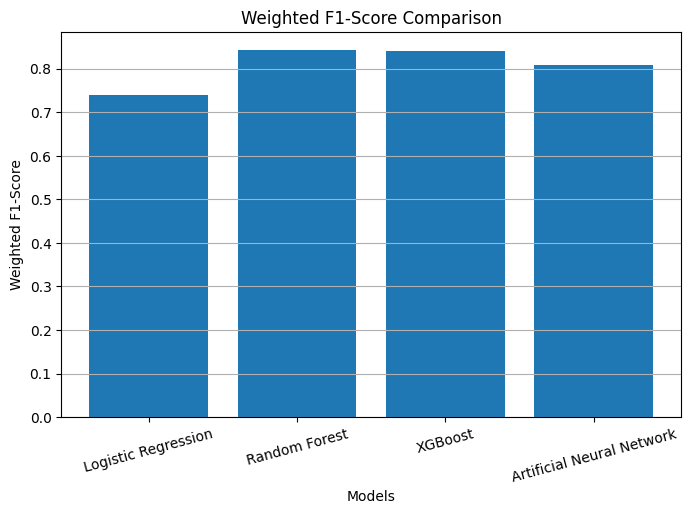

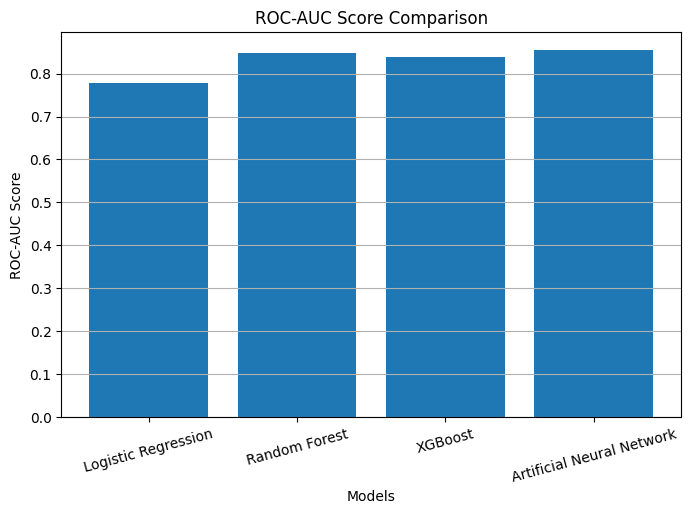

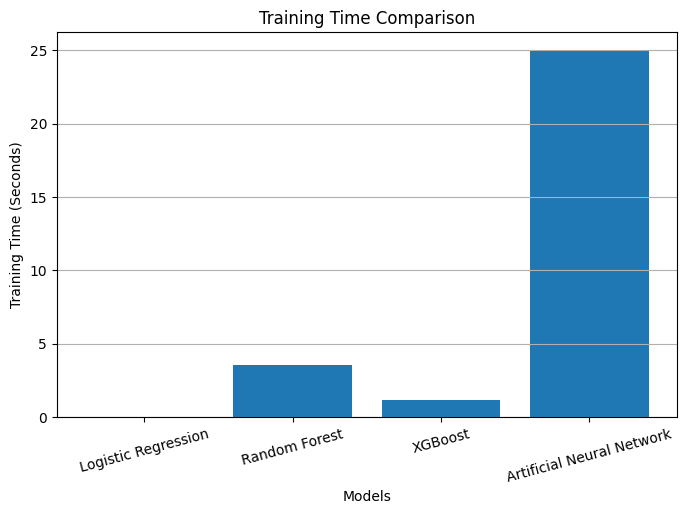

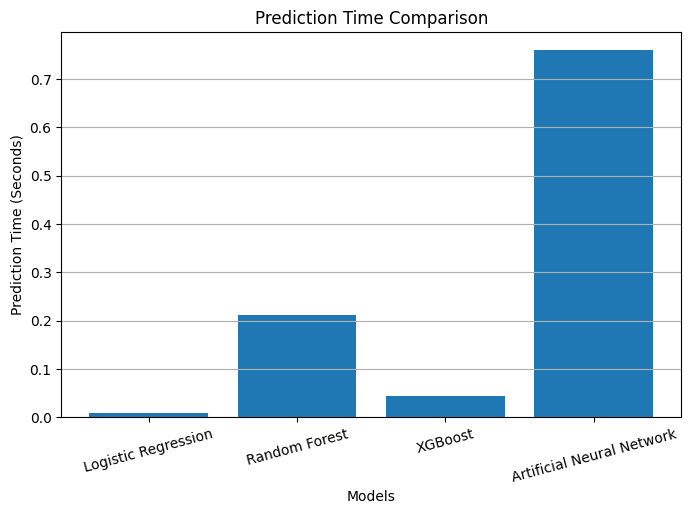

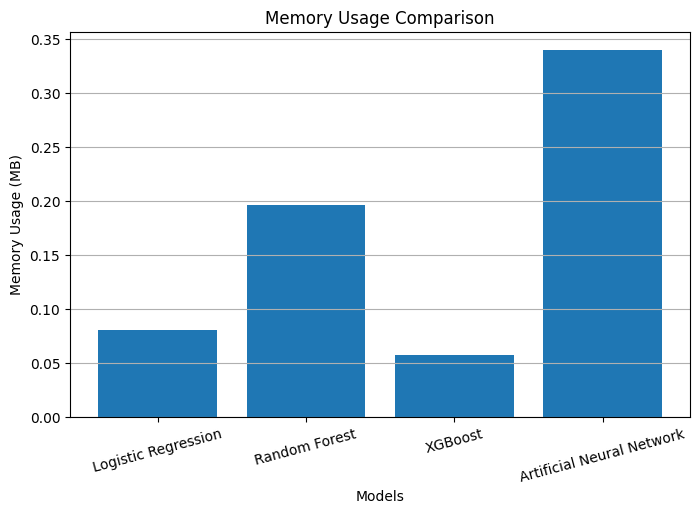

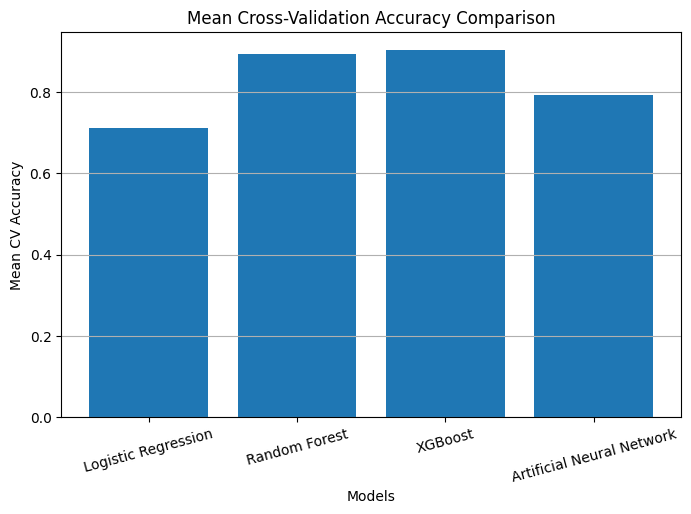

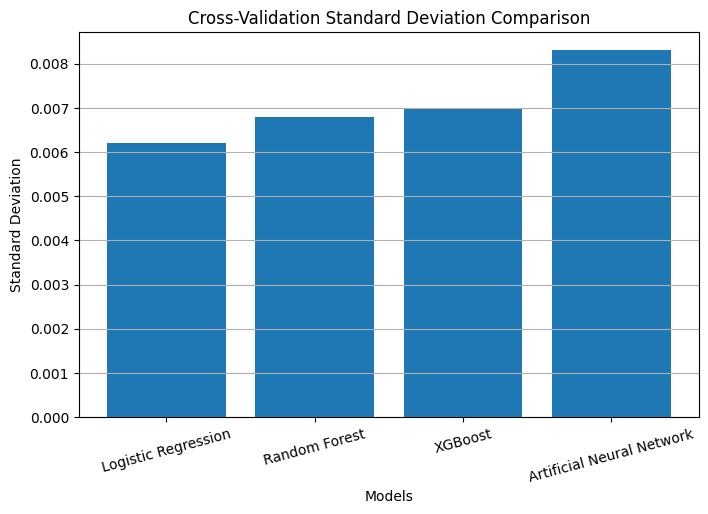

In [ ]:
# I imported the required libraries.
import matplotlib.pyplot as plt

# I extracted the model names.
models = combined_comparison["Model"]

# Accuracy Comparison
plt.figure(figsize=(8,5))
plt.bar(models, combined_comparison["Accuracy"])
plt.title("Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)
plt.grid(axis='y')
plt.show()

# Weighted F1-Score Comparison
plt.figure(figsize=(8,5))
plt.bar(models, combined_comparison["Weighted F1-Score"])
plt.title("Weighted F1-Score Comparison")
plt.xlabel("Models")
plt.ylabel("Weighted F1-Score")
plt.xticks(rotation=15)
plt.grid(axis='y')
plt.show()

# ROC-AUC Comparison
plt.figure(figsize=(8,5))
plt.bar(models, combined_comparison["ROC-AUC"])
plt.title("ROC-AUC Score Comparison")
plt.xlabel("Models")
plt.ylabel("ROC-AUC Score")
plt.xticks(rotation=15)
plt.grid(axis='y')
plt.show()

# Training Time Comparison
plt.figure(figsize=(8,5))
plt.bar(models, combined_comparison["Training Time (s)"])
plt.title("Training Time Comparison")
plt.xlabel("Models")
plt.ylabel("Training Time (Seconds)")
plt.xticks(rotation=15)
plt.grid(axis='y')
plt.show()

# Prediction Time Comparison
plt.figure(figsize=(8,5))
plt.bar(models, combined_comparison["Prediction Time (s)"])
plt.title("Prediction Time Comparison")
plt.xlabel("Models")
plt.ylabel("Prediction Time (Seconds)")
plt.xticks(rotation=15)
plt.grid(axis='y')
plt.show()

# Memory Usage Comparison
plt.figure(figsize=(8,5))
plt.bar(models, combined_comparison["Memory Usage (MB)"])
plt.title("Memory Usage Comparison")
plt.xlabel("Models")
plt.ylabel("Memory Usage (MB)")
plt.xticks(rotation=15)
plt.grid(axis='y')
plt.show()

# Mean Cross-Validation Accuracy Comparison
plt.figure(figsize=(8,5))
plt.bar(models, combined_comparison["Mean CV Accuracy"])
plt.title("Mean Cross-Validation Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Mean CV Accuracy")
plt.xticks(rotation=15)
plt.grid(axis='y')
plt.show()

# Cross-Validation Standard Deviation Comparison
plt.figure(figsize=(8,5))
plt.bar(models, combined_comparison["CV Standard Deviation"])
plt.title("Cross-Validation Standard Deviation Comparison")
plt.xlabel("Models")
plt.ylabel("Standard Deviation")
plt.xticks(rotation=15)
plt.grid(axis='y')
plt.show()

# Combined Bar Graph

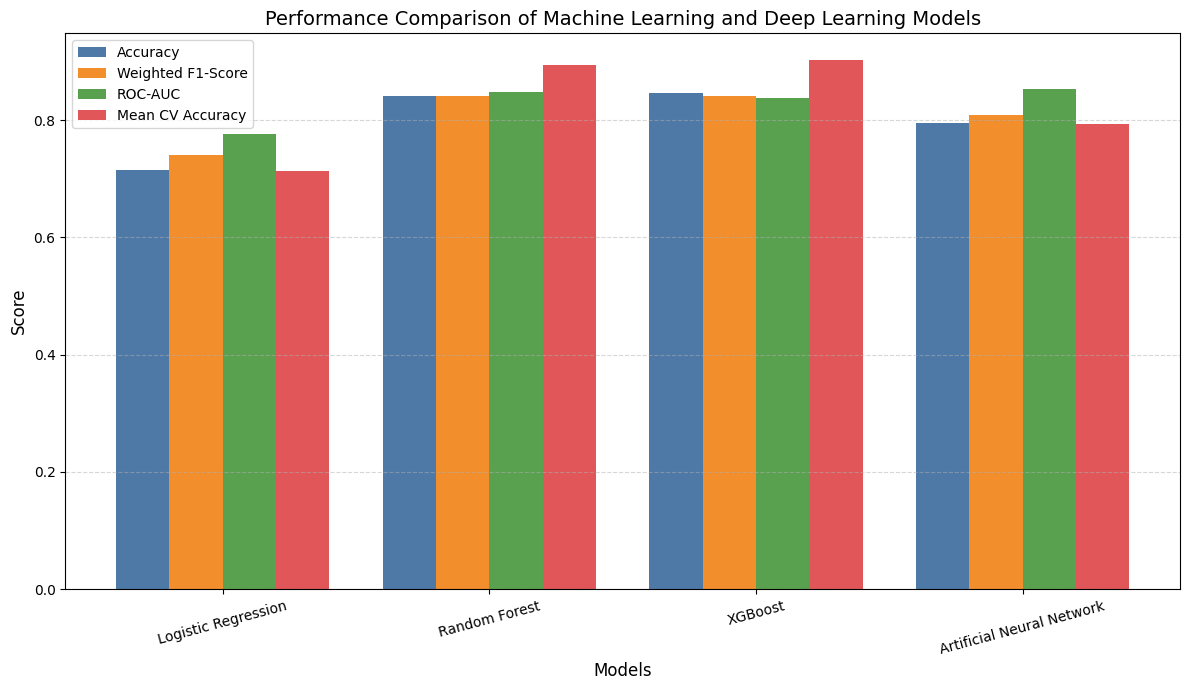

In [ ]:
# I imported the required libraries.
import numpy as np
import matplotlib.pyplot as plt

# I extracted the model names.
models = combined_comparison["Model"]

# I selected the performance metrics.
metrics = [
    "Accuracy",
    "Weighted F1-Score",
    "ROC-AUC",
    "Mean CV Accuracy"
]

# I created the x-axis positions.
x = np.arange(len(models))

# I set the width of each bar.
width = 0.20

# I created the figure.
plt.figure(figsize=(12,7))

# I plotted each metric using different colours.
plt.bar(x - 1.5*width,
        combined_comparison["Accuracy"],
        width,
        label="Accuracy",
        color="#4E79A7")

plt.bar(x - 0.5*width,
        combined_comparison["Weighted F1-Score"],
        width,
        label="Weighted F1-Score",
        color="#F28E2B")

plt.bar(x + 0.5*width,
        combined_comparison["ROC-AUC"],
        width,
        label="ROC-AUC",
        color="#59A14F")

plt.bar(x + 1.5*width,
        combined_comparison["Mean CV Accuracy"],
        width,
        label="Mean CV Accuracy",
        color="#E15759")

# I added the labels and title.
plt.xlabel("Models", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.title("Performance Comparison of Machine Learning and Deep Learning Models", fontsize=14)

# I added the model names.
plt.xticks(x, models, rotation=15)

# I displayed the legend.
plt.legend()

# I displayed the grid.
plt.grid(axis="y", linestyle="--", alpha=0.5)

# I adjusted the layout.
plt.tight_layout()

# I displayed the graph.
plt.show()

# Comparative Graph for all Models in terms of Accuracy (Mean ± SD)

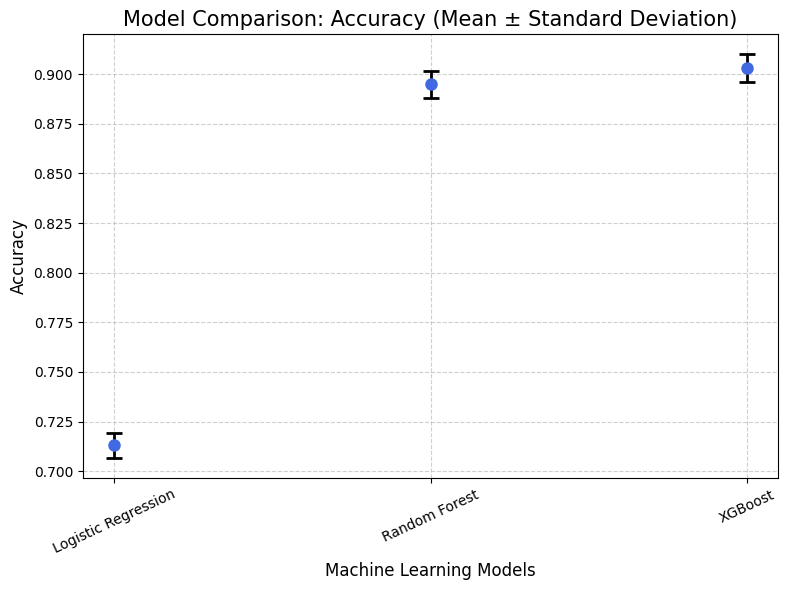

In [ ]:
# I imported the required libraries to create the comparative accuracy graph.
import matplotlib.pyplot as plt
import numpy as np

# I extracted the model names from the comparison table.
models = results_table["Model"]

# I extracted the mean accuracy values from the comparison table.
mean_accuracy = results_table["Accuracy (Mean ± SD)"].str.split(" ± ").str[0].astype(float)

# I extracted the standard deviation values from the comparison table.
std_accuracy = results_table["Accuracy (Mean ± SD)"].str.split(" ± ").str[1].astype(float)

# I created the figure.
plt.figure(figsize=(8, 6))

# I plotted the mean accuracies with error bars representing the standard deviation.
plt.errorbar(
    models,
    mean_accuracy,
    yerr=std_accuracy,
    fmt='o',
    color='royalblue',
    ecolor='black',
    elinewidth=2,
    capsize=6,
    capthick=2,
    markersize=8
)

# I added the graph title.
plt.title("Model Comparison: Accuracy (Mean ± Standard Deviation)", fontsize=15)

# I labelled the x-axis.
plt.xlabel("Machine Learning Models", fontsize=12)

# I labelled the y-axis.
plt.ylabel("Accuracy", fontsize=12)

# I rotated the x-axis labels for better readability.
plt.xticks(rotation=25)

# I displayed grid lines.
plt.grid(True, linestyle='--', alpha=0.6)

# I adjusted the layout.
plt.tight_layout()

# I displayed the graph.
plt.show()

# Comparative Graph in terms of accuracy

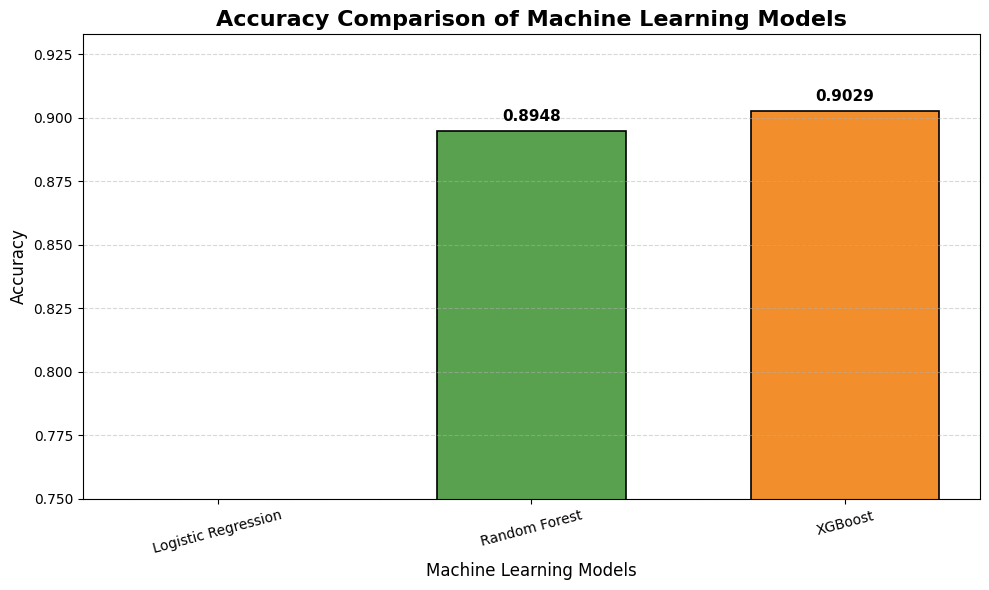

In [ ]:
# I imported the required library to create the comparative accuracy graph.
import matplotlib.pyplot as plt

# I extracted the model names from the comparison table.
models = results_table["Model"]

# I extracted the mean accuracy values from the comparison table.
accuracy = results_table["Accuracy (Mean ± SD)"].str.split(" ± ").str[0].astype(float)

# I created the figure.
plt.figure(figsize=(10, 6))

# I plotted the accuracy comparison using a bar chart.
bars = plt.bar(
    models,
    accuracy,
    color=["#4E79A7", "#59A14F", "#F28E2B", "#9C27B0"],
    edgecolor="black",
    linewidth=1.2,
    width=0.6
)

# I displayed the accuracy value above each bar.
for bar in bars:
    height = bar.get_height()
    plt.annotate(
        f"{height:.4f}",
        xy=(bar.get_x() + bar.get_width()/2, height),
        xytext=(0, 5),               # Move the label 5 points above the bar
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

# I added the graph title.
plt.title("Accuracy Comparison of Machine Learning Models", fontsize=16, fontweight="bold")

# I labelled the x-axis.
plt.xlabel("Machine Learning Models", fontsize=12)

# I labelled the y-axis.
plt.ylabel("Accuracy", fontsize=12)

# I set the y-axis limits to leave sufficient space above the tallest bar.
plt.ylim(0.75, max(accuracy) + 0.03)

# I displayed horizontal grid lines.
plt.grid(axis="y", linestyle="--", alpha=0.5)

# I rotated the x-axis labels.
plt.xticks(rotation=15)

# I adjusted the layout.
plt.tight_layout()

# I displayed the graph.
plt.show()

# Comparative Graph for Macro F1-Score

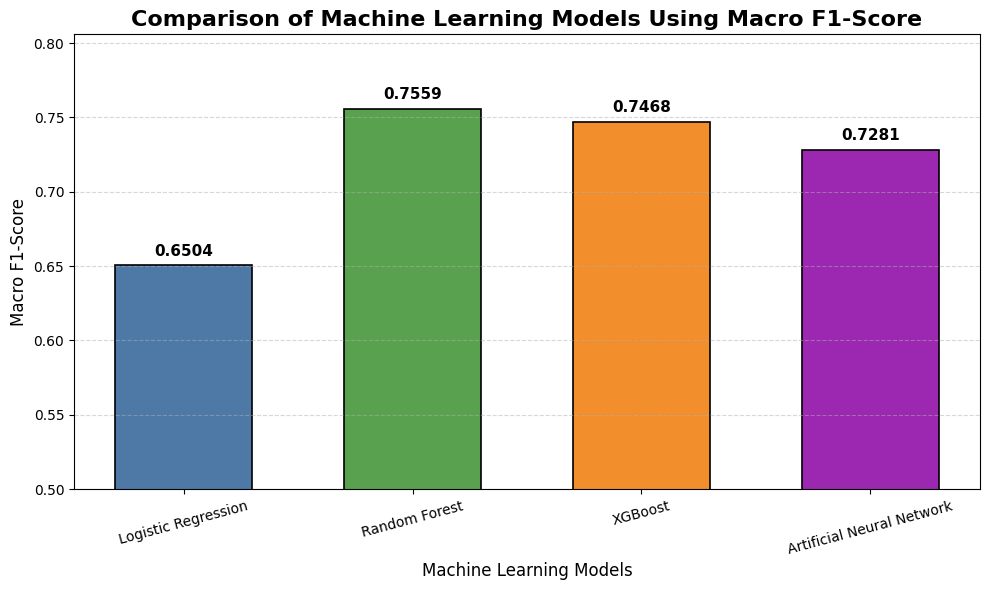

In [ ]:
# I imported the required libraries to calculate the F1-score.
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

# I calculated the Macro F1-score for the Logistic Regression model.
lr_f1 = f1_score(y_test, y_pred_lr, average='macro')

# I calculated the Macro F1-score for the Random Forest model.
rf_f1 = f1_score(y_test, y_pred_rf, average='macro')

# I calculated the Macro F1-score for the XGBoost model.
xgb_f1 = f1_score(y_test, y_pred_xgb, average='macro')

# I calculated the Macro F1-score for the Artificial Neural Network model.
ann_f1 = f1_score(y_test, y_pred_ann, average='macro')

# I stored the model names.
models = [
    "Logistic Regression",
    "Random Forest",
    "XGBoost",
    "Artificial Neural Network"
]

# I stored the Macro F1-score values.
f1_scores = [
    lr_f1,
    rf_f1,
    xgb_f1,
    ann_f1
]

# I created the figure.
plt.figure(figsize=(10, 6))

# I plotted the Macro F1-score comparison using a bar chart.
bars = plt.bar(
    models,
    f1_scores,
    color=["#4E79A7", "#59A14F", "#F28E2B", "#9C27B0"],
    edgecolor="black",
    linewidth=1.2,
    width=0.6
)

# I displayed the Macro F1-score above each bar.
for bar in bars:
    height = bar.get_height()
    plt.annotate(
        f"{height:.4f}",
        xy=(bar.get_x() + bar.get_width()/2, height),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

# I added the graph title.
plt.title("Comparison of Machine Learning Models Using Macro F1-Score", fontsize=16, fontweight="bold")

# I labelled the x-axis.
plt.xlabel("Machine Learning Models", fontsize=12)

# I labelled the y-axis.
plt.ylabel("Macro F1-Score", fontsize=12)

# I set the y-axis limits.
plt.ylim(0.50, max(f1_scores) + 0.05)

# I displayed horizontal grid lines.
plt.grid(axis='y', linestyle='--', alpha=0.5)

# I rotated the x-axis labels.
plt.xticks(rotation=15)

# I adjusted the layout.
plt.tight_layout()

# I displayed the graph.
plt.show()

# Cross Validation Results for Macro F1-Score

In [ ]:
# I imported the required libraries to perform cross-validation.
import numpy as np
import pandas as pd

# I imported the Stratified K-Fold and cross-validation functions.
from sklearn.model_selection import StratifiedKFold, cross_val_score

# I imported the machine learning models.
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# I created a Stratified K-Fold object because it preserved the class distribution in each fold.
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# I created a dictionary containing the machine learning models.
models = {
    "Logistic Regression": LogisticRegression(random_state=42),

    "Random Forest": RandomForestClassifier(random_state=42),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )
}

# I created an empty list to store the cross-validation results.
results = []

# I evaluated each model using the Macro F1-score.
for name, model in models.items():

    # I calculated the cross-validation Macro F1-score.
    f1_scores = cross_val_score(
        model,
        X_train_smote,
        y_train_smote,
        cv=cv,
        scoring="f1_macro"
    )

    # I stored the evaluation results.
    results.append({
        "Model": name,
        "F1-Macro (Mean ± SD)": f"{f1_scores.mean():.4f} ± {f1_scores.std():.4f}"
    })

# I created a DataFrame to summarize the model performance.
f1_results_table = pd.DataFrame(results)

# Cross Validation for Macro F1-Score : ANN

In [ ]:
# I imported the required libraries to perform cross-validation.
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
import numpy as np

# I created a Stratified K-Fold object because it preserved the class distribution in each fold.
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# I created an empty list to store the F1-score values.
ann_f1_scores = []

# I performed 5-fold cross-validation.
for train_index, val_index in cv.split(X_train_smote, y_train_smote):

    X_train_cv = X_train_smote[train_index]
    X_val_cv = X_train_smote[val_index]

    y_train_cv = y_train_smote.iloc[train_index]
    y_val_cv = y_train_smote.iloc[val_index]

    # I created the Artificial Neural Network model.
    ann_model = Sequential([
        Input(shape=(X_train_cv.shape[1],)),
        Dense(16, activation="relu"),
        Dense(8, activation="relu"),
        Dense(1, activation="sigmoid")
    ])

    # I compiled the model.
    ann_model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    # I trained the model.
    ann_model.fit(
        X_train_cv,
        y_train_cv,
        epochs=20,
        batch_size=32,
        verbose=0
    )

    # I predicted the validation classes.
    y_pred = (ann_model.predict(X_val_cv, verbose=0) > 0.5).astype(int)

    # I calculated the Macro F1-score.
    f1 = f1_score(y_val_cv, y_pred, average="macro")

    # I stored the Macro F1-score.
    ann_f1_scores.append(f1)

# I calculated the mean Macro F1-score.
ann_mean_f1 = np.mean(ann_f1_scores)

# I calculated the standard deviation.
ann_std_f1 = np.std(ann_f1_scores)

# I displayed the results.
print("ANN Cross-Validation Macro F1-Scores:")
print(ann_f1_scores)
print("\nMean F1-Macro:", round(ann_mean_f1, 4))
print("Standard Deviation:", round(ann_std_f1, 4))

ANN Cross-Validation Macro F1-Scores:
[0.7883480563424214, 0.7955220917216905, 0.8041468219523424, 0.7868772030463367, 0.798974358974359]

Mean F1-Macro: 0.7948
Standard Deviation: 0.0065


# Comparative Bar Graph for F1-Weighted Score

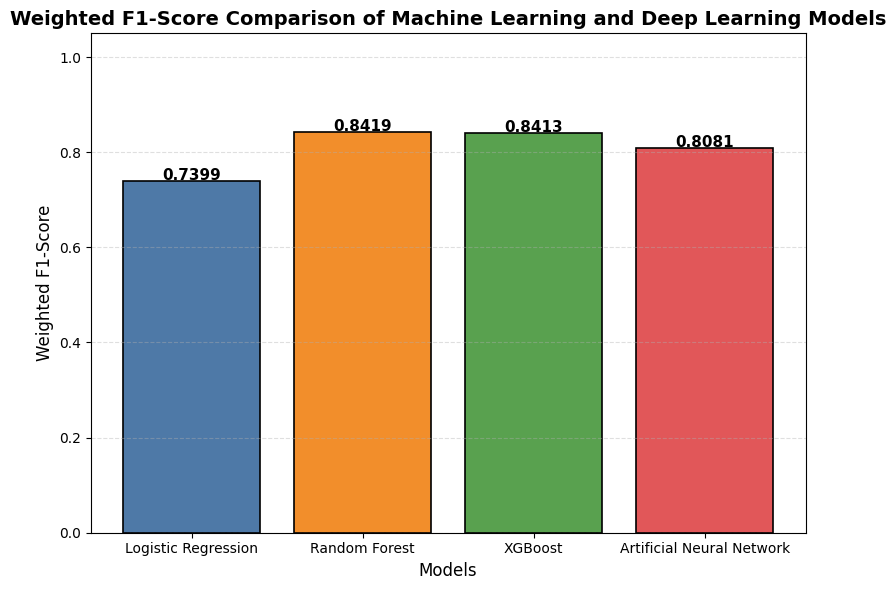

In [ ]:
# I imported the required library.
import matplotlib.pyplot as plt

# I created the figure.
plt.figure(figsize=(8,6))

# I plotted the Weighted F1-Score for all models.
bars = plt.bar(
    combined_comparison["Model"],
    combined_comparison["Weighted F1-Score"],
    color=["#4E79A7", "#F28E2B", "#59A14F", "#E15759"],
    edgecolor="black",
    linewidth=1.2
)

# I added the values on top of each bar.
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.002,
        f"{height:.4f}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

# I customised the graph.
plt.title("Weighted F1-Score Comparison of Machine Learning and Deep Learning Models",
          fontsize=14,
          fontweight="bold")

plt.xlabel("Models", fontsize=12)
plt.ylabel("Weighted F1-Score", fontsize=12)

plt.ylim(0, 1.05)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# Combined ROC-AUC Curve for all Models

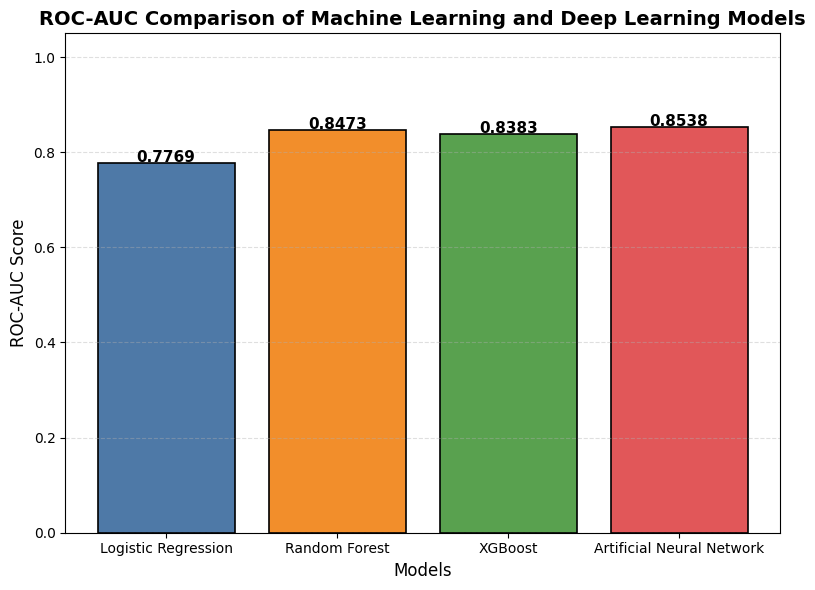

In [ ]:
# I imported the required library.
import matplotlib.pyplot as plt

# I created the figure.
plt.figure(figsize=(8,6))

# I plotted the ROC-AUC scores for all models.
bars = plt.bar(
    combined_comparison["Model"],
    combined_comparison["ROC-AUC"],
    color=["#4E79A7", "#F28E2B", "#59A14F", "#E15759"],
    edgecolor="black",
    linewidth=1.2
)

# I added the values on top of each bar.
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.002,
        f"{height:.4f}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

# I customised the graph.
plt.title("ROC-AUC Comparison of Machine Learning and Deep Learning Models",
          fontsize=14,
          fontweight="bold")

plt.xlabel("Models", fontsize=12)
plt.ylabel("ROC-AUC Score", fontsize=12)

plt.ylim(0, 1.05)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# Hyper Parameter Tuning

# Technique 1 : GridSearch CV

# Model 1 : Logistic Regression

In [ ]:
# I imported the required libraries.
import time
import tracemalloc

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# I defined the parameter grid.
param_grid = {
    "C": [0.5, 1, 2, 5],
    "solver": ["lbfgs"],
    "max_iter": [1000]
}

# I initialized the Logistic Regression model.
lr_base = LogisticRegression(random_state=42)

# I measured the training time and memory usage.
tracemalloc.start()
start_time = time.time()

# I performed Grid Search.
grid_search_lr = GridSearchCV(
    estimator=lr_base,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=1
)

# I trained the model using the SMOTE-balanced training data.
grid_search_lr.fit(X_train_smote, y_train_smote)

end_time = time.time()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

# I stored the best model and results.
grid_lr_best_model = grid_search_lr.best_estimator_
grid_lr_best_params = grid_search_lr.best_params_
grid_lr_best_score = grid_search_lr.best_score_

grid_lr_training_time = end_time - start_time
grid_lr_memory_usage_mb = peak / (1024 ** 2)

# I made predictions on the scaled test data.
y_pred_grid_lr = grid_lr_best_model.predict(X_test_scaled)
y_prob_grid_lr = grid_lr_best_model.predict_proba(X_test_scaled)[:, 1]

# I calculated the evaluation metrics.
grid_lr_accuracy = accuracy_score(y_test, y_pred_grid_lr)
grid_lr_f1_weighted = f1_score(y_test, y_pred_grid_lr, average="weighted")
grid_lr_auc = roc_auc_score(y_test, y_prob_grid_lr)

# I displayed the results.
print("Logistic Regression - Grid Search Results")
print("Best Parameters:", grid_lr_best_params)
print("Best Cross-Validation Accuracy:", round(grid_lr_best_score, 4))
print("Test Accuracy:", round(grid_lr_accuracy, 4))
print("Weighted F1-Score:", round(grid_lr_f1_weighted, 4))
print("ROC-AUC:", round(grid_lr_auc, 4))
print("Training Time (s):", round(grid_lr_training_time, 4))
print("Memory Usage (MB):", round(grid_lr_memory_usage_mb, 4))

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Logistic Regression - Grid Search Results
Best Parameters: {'C': 0.5, 'max_iter': 1000, 'solver': 'lbfgs'}
Best Cross-Validation Accuracy: 0.713
Test Accuracy: 0.7155
Weighted F1-Score: 0.7399
ROC-AUC: 0.7769
Training Time (s): 0.6724
Memory Usage (MB): 1.6485


# Model 2 : Random Forest

In [ ]:
# I imported the required libraries.
import time
import tracemalloc

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# I defined the parameter grid.
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20],
    "min_samples_split": [2, 5]
}

# I initialized the Random Forest model.
rf_base = RandomForestClassifier(random_state=42)

# I measured the training time and memory usage.
tracemalloc.start()
start_time = time.time()

# I performed Grid Search.
grid_search_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search_rf.fit(X_train_smote, y_train_smote)

end_time = time.time()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

# I stored the best model and results.
grid_rf_best_model = grid_search_rf.best_estimator_
grid_rf_best_params = grid_search_rf.best_params_
grid_rf_best_score = grid_search_rf.best_score_

grid_rf_training_time = end_time - start_time
grid_rf_memory_usage_mb = peak / (1024 ** 2)

# I made predictions.
y_pred_grid_rf = grid_rf_best_model.predict(X_test_scaled)
y_prob_grid_rf = grid_rf_best_model.predict_proba(X_test_scaled)[:, 1]

# I calculated the evaluation metrics.
grid_rf_accuracy = accuracy_score(y_test, y_pred_grid_rf)
grid_rf_f1_weighted = f1_score(y_test, y_pred_grid_rf, average="weighted")
grid_rf_auc = roc_auc_score(y_test, y_prob_grid_rf)

# I displayed the results.
print("Random Forest - Grid Search Results")
print("Best Parameters:", grid_rf_best_params)
print("Best Cross-Validation Accuracy:", round(grid_rf_best_score, 4))
print("Test Accuracy:", round(grid_rf_accuracy, 4))
print("Weighted F1-Score:", round(grid_rf_f1_weighted, 4))
print("ROC-AUC:", round(grid_rf_auc, 4))
print("Training Time (s):", round(grid_rf_training_time, 4))
print("Memory Usage (MB):", round(grid_rf_memory_usage_mb, 4))

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Random Forest - Grid Search Results
Best Parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross-Validation Accuracy: 0.9005
Test Accuracy: 0.8445
Weighted F1-Score: 0.8443
ROC-AUC: 0.8513
Training Time (s): 102.0959
Memory Usage (MB): 1.8836


# Model 3 : XGBoost

In [ ]:
# I imported the required libraries.
import time
import tracemalloc

from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# I defined the parameter grid.
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1]
}

# I initialized the XGBoost model.
xgb_base = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

# I measured the training time and memory usage.
tracemalloc.start()
start_time = time.time()

# I performed Grid Search.
grid_search_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search_xgb.fit(X_train_smote, y_train_smote)

end_time = time.time()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

# I stored the best model and results.
grid_xgb_best_model = grid_search_xgb.best_estimator_
grid_xgb_best_params = grid_search_xgb.best_params_
grid_xgb_best_score = grid_search_xgb.best_score_

grid_xgb_training_time = end_time - start_time
grid_xgb_memory_usage_mb = peak / (1024 ** 2)

# I made predictions.
y_pred_grid_xgb = grid_xgb_best_model.predict(X_test_scaled)
y_prob_grid_xgb = grid_xgb_best_model.predict_proba(X_test_scaled)[:, 1]

# I calculated the evaluation metrics.
grid_xgb_accuracy = accuracy_score(y_test, y_pred_grid_xgb)
grid_xgb_f1_weighted = f1_score(y_test, y_pred_grid_xgb, average="weighted")
grid_xgb_auc = roc_auc_score(y_test, y_prob_grid_xgb)

# I displayed the results.
print("XGBoost - Grid Search Results")
print("Best Parameters:", grid_xgb_best_params)
print("Best Cross-Validation Accuracy:", round(grid_xgb_best_score, 4))
print("Test Accuracy:", round(grid_xgb_accuracy, 4))
print("Weighted F1-Score:", round(grid_xgb_f1_weighted, 4))
print("ROC-AUC:", round(grid_xgb_auc, 4))
print("Training Time (s):", round(grid_xgb_training_time, 4))
print("Memory Usage (MB):", round(grid_xgb_memory_usage_mb, 4))

Fitting 5 folds for each of 8 candidates, totalling 40 fits
XGBoost - Grid Search Results
Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Best Cross-Validation Accuracy: 0.8878
Test Accuracy: 0.8625
Weighted F1-Score: 0.8566
ROC-AUC: 0.858
Training Time (s): 13.2366
Memory Usage (MB): 1.6667


# Model 4 : Artificial Neural Network

In [ ]:
# I imported the required libraries.
import time
import tracemalloc

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# I built the Artificial Neural Network.
ann_model = Sequential()

# Input Layer
ann_model.add(Input(shape=(X_train_smote.shape[1],)))

# Hidden Layer 1
ann_model.add(Dense(128, activation="relu"))
ann_model.add(Dropout(0.30))

# Hidden Layer 2
ann_model.add(Dense(64, activation="relu"))
ann_model.add(Dropout(0.20))

# Hidden Layer 3
ann_model.add(Dense(32, activation="relu"))

# Hidden Layer 4
ann_model.add(Dense(16, activation="relu"))

# Output Layer
ann_model.add(Dense(1, activation="sigmoid"))

# I compiled the model.
ann_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# I measured the training time and memory usage.
tracemalloc.start()
start_time = time.time()

history = ann_model.fit(
    X_train_smote,
    y_train_smote,
    epochs=30,
    batch_size=64,
    validation_split=0.20,
    verbose=0
)

end_time = time.time()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

ann_training_time = end_time - start_time
ann_memory_usage_mb = peak / (1024 ** 2)

# I measured the prediction time.
prediction_start = time.time()

y_prob_ann = ann_model.predict(X_test_scaled, verbose=0)
y_pred_ann = (y_prob_ann > 0.5).astype(int)

prediction_end = time.time()

ann_prediction_time = prediction_end - prediction_start

# I calculated the evaluation metrics.
ann_accuracy = accuracy_score(y_test, y_pred_ann)
ann_f1_weighted = f1_score(y_test, y_pred_ann, average="weighted")
ann_auc = roc_auc_score(y_test, y_prob_ann)

# I displayed the results.
print("Artificial Neural Network Results")
print("Accuracy:", round(ann_accuracy, 4))
print("Weighted F1-Score:", round(ann_f1_weighted, 4))
print("ROC-AUC:", round(ann_auc, 4))
print("Training Time (s):", round(ann_training_time, 4))
print("Prediction Time (s):", round(ann_prediction_time, 4))
print("Memory Usage (MB):", round(ann_memory_usage_mb, 4))

Artificial Neural Network Results
Accuracy: 0.832
Weighted F1-Score: 0.8375
ROC-AUC: 0.8599
Training Time (s): 42.4292
Prediction Time (s): 0.767
Memory Usage (MB): 8.6937


# Technique 2 : RandomizedSearch CV

# Model 1 : Logistic Regression

In [ ]:
# I imported the required libraries.
import time
import tracemalloc

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# I defined the parameter distributions.
param_dist = {
    "C": [0.01, 0.1, 0.5, 1, 2, 5, 10],
    "solver": ["lbfgs", "liblinear"],
    "max_iter": [500, 1000]
}

# I initialized the Logistic Regression model.
lr_base = LogisticRegression(random_state=42)

# I measured the training time and memory usage.
tracemalloc.start()
start_time = time.time()

# I performed Randomized Search.
random_search_lr = RandomizedSearchCV(
    estimator=lr_base,
    param_distributions=param_dist,
    n_iter=10,
    scoring="accuracy",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search_lr.fit(X_train_smote, y_train_smote)

end_time = time.time()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

# I stored the best model and results.
random_lr_best_model = random_search_lr.best_estimator_
random_lr_best_params = random_search_lr.best_params_
random_lr_best_score = random_search_lr.best_score_

random_lr_training_time = end_time - start_time
random_lr_memory_usage_mb = peak / (1024 ** 2)

# I made predictions on the scaled test data.
y_pred_random_lr = random_lr_best_model.predict(X_test_scaled)
y_prob_random_lr = random_lr_best_model.predict_proba(X_test_scaled)[:, 1]

# I calculated the evaluation metrics.
random_lr_accuracy = accuracy_score(y_test, y_pred_random_lr)
random_lr_f1_weighted = f1_score(y_test, y_pred_random_lr, average="weighted")
random_lr_auc = roc_auc_score(y_test, y_prob_random_lr)

# I displayed the results.
print("Logistic Regression - Randomized Search Results")
print("Best Parameters:", random_lr_best_params)
print("Best Cross-Validation Accuracy:", round(random_lr_best_score, 4))
print("Test Accuracy:", round(random_lr_accuracy, 4))
print("Weighted F1-Score:", round(random_lr_f1_weighted, 4))
print("ROC-AUC:", round(random_lr_auc, 4))
print("Training Time (s):", round(random_lr_training_time, 4))
print("Memory Usage (MB):", round(random_lr_memory_usage_mb, 4))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Logistic Regression - Randomized Search Results
Best Parameters: {'solver': 'lbfgs', 'max_iter': 500, 'C': 0.01}
Best Cross-Validation Accuracy: 0.713
Test Accuracy: 0.718
Weighted F1-Score: 0.742
ROC-AUC: 0.7765
Training Time (s): 2.5413
Memory Usage (MB): 1.7138


# Model 2 : Random Forest

In [ ]:
# I imported the required libraries.
import time
import tracemalloc

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# I defined the parameter distributions.
param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# I initialized the Random Forest model.
rf_base = RandomForestClassifier(random_state=42)

# I measured the training time and memory usage.
tracemalloc.start()
start_time = time.time()

# I performed Randomized Search.
random_search_rf = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=10,
    scoring="accuracy",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search_rf.fit(X_train_smote, y_train_smote)

end_time = time.time()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

# I stored the best model and results.
random_rf_best_model = random_search_rf.best_estimator_
random_rf_best_params = random_search_rf.best_params_
random_rf_best_score = random_search_rf.best_score_

random_rf_training_time = end_time - start_time
random_rf_memory_usage_mb = peak / (1024 ** 2)

# I made predictions.
y_pred_random_rf = random_rf_best_model.predict(X_test_scaled)
y_prob_random_rf = random_rf_best_model.predict_proba(X_test_scaled)[:, 1]

# I calculated the evaluation metrics.
random_rf_accuracy = accuracy_score(y_test, y_pred_random_rf)
random_rf_f1_weighted = f1_score(y_test, y_pred_random_rf, average="weighted")
random_rf_auc = roc_auc_score(y_test, y_prob_random_rf)

# I displayed the results.
print("Random Forest - Randomized Search Results")
print("Best Parameters:", random_rf_best_params)
print("Best Cross-Validation Accuracy:", round(random_rf_best_score, 4))
print("Test Accuracy:", round(random_rf_accuracy, 4))
print("Weighted F1-Score:", round(random_rf_f1_weighted, 4))
print("ROC-AUC:", round(random_rf_auc, 4))
print("Training Time (s):", round(random_rf_training_time, 4))
print("Memory Usage (MB):", round(random_rf_memory_usage_mb, 4))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Random Forest - Randomized Search Results
Best Parameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}
Best Cross-Validation Accuracy: 0.9015
Test Accuracy: 0.841
Weighted F1-Score: 0.84
ROC-AUC: 0.8501
Training Time (s): 186.1452
Memory Usage (MB): 2.0052


# Model 3 : XGBoost

In [ ]:
# I imported the required libraries.
import time
import tracemalloc

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# I defined the parameter distributions.
param_dist = {
    "n_estimators": [100, 150, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

# I initialized the XGBoost model.
xgb_base = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

# I measured the training time and memory usage.
tracemalloc.start()
start_time = time.time()

# I performed Randomized Search.
random_search_xgb = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=10,
    scoring="accuracy",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search_xgb.fit(X_train_smote, y_train_smote)

end_time = time.time()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

# I stored the best model and results.
random_xgb_best_model = random_search_xgb.best_estimator_
random_xgb_best_params = random_search_xgb.best_params_
random_xgb_best_score = random_search_xgb.best_score_

random_xgb_training_time = end_time - start_time
random_xgb_memory_usage_mb = peak / (1024 ** 2)

# I made predictions.
y_pred_random_xgb = random_xgb_best_model.predict(X_test_scaled)
y_prob_random_xgb = random_xgb_best_model.predict_proba(X_test_scaled)[:, 1]

# I calculated the evaluation metrics.
random_xgb_accuracy = accuracy_score(y_test, y_pred_random_xgb)
random_xgb_f1_weighted = f1_score(y_test, y_pred_random_xgb, average="weighted")
random_xgb_auc = roc_auc_score(y_test, y_prob_random_xgb)

# I displayed the results.
print("XGBoost - Randomized Search Results")
print("Best Parameters:", random_xgb_best_params)
print("Best Cross-Validation Accuracy:", round(random_xgb_best_score, 4))
print("Test Accuracy:", round(random_xgb_accuracy, 4))
print("Weighted F1-Score:", round(random_xgb_f1_weighted, 4))
print("ROC-AUC:", round(random_xgb_auc, 4))
print("Training Time (s):", round(random_xgb_training_time, 4))
print("Memory Usage (MB):", round(random_xgb_memory_usage_mb, 4))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
XGBoost - Randomized Search Results
Best Parameters: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Best Cross-Validation Accuracy: 0.8911
Test Accuracy: 0.858
Weighted F1-Score: 0.8532
ROC-AUC: 0.8522
Training Time (s): 46.2696
Memory Usage (MB): 1.7168


# Model 4 : Artificial Neural Network

In [ ]:
# I imported the required libraries.
import time
import tracemalloc

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# I built the Artificial Neural Network.
ann_model = Sequential()

# Input Layer
ann_model.add(Input(shape=(X_train_smote.shape[1],)))

# Hidden Layer 1
ann_model.add(Dense(256, activation="relu"))
ann_model.add(BatchNormalization())
ann_model.add(Dropout(0.30))

# Hidden Layer 2
ann_model.add(Dense(128, activation="relu"))
ann_model.add(BatchNormalization())
ann_model.add(Dropout(0.30))

# Hidden Layer 3
ann_model.add(Dense(64, activation="relu"))
ann_model.add(BatchNormalization())
ann_model.add(Dropout(0.25))

# Hidden Layer 4
ann_model.add(Dense(32, activation="relu"))
ann_model.add(Dropout(0.20))

# Hidden Layer 5
ann_model.add(Dense(16, activation="relu"))

# Output Layer
ann_model.add(Dense(1, activation="sigmoid"))

# I compiled the model.
ann_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# I used Early Stopping.
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# I measured the training time and memory usage.
tracemalloc.start()
start_time = time.time()

history = ann_model.fit(
    X_train_smote,
    y_train_smote,
    validation_split=0.20,
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    verbose=0
)

end_time = time.time()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

ann_training_time = end_time - start_time
ann_memory_usage_mb = peak / (1024 ** 2)

# I measured the prediction time.
prediction_start = time.time()

y_prob_ann = ann_model.predict(X_test_scaled, verbose=0)
y_pred_ann = (y_prob_ann > 0.5).astype(int)

prediction_end = time.time()

ann_prediction_time = prediction_end - prediction_start

# I calculated the evaluation metrics.
ann_accuracy = accuracy_score(y_test, y_pred_ann)
ann_f1_weighted = f1_score(y_test, y_pred_ann, average="weighted")
ann_auc = roc_auc_score(y_test, y_prob_ann)

# I displayed the results.
print("Artificial Neural Network Results")
print("Accuracy:", round(ann_accuracy, 4))
print("Weighted F1-Score:", round(ann_f1_weighted, 4))
print("ROC-AUC:", round(ann_auc, 4))
print("Training Time (s):", round(ann_training_time, 4))
print("Prediction Time (s):", round(ann_prediction_time, 4))
print("Memory Usage (MB):", round(ann_memory_usage_mb, 4))

Artificial Neural Network Results
Accuracy: 0.821
Weighted F1-Score: 0.828
ROC-AUC: 0.8585
Training Time (s): 35.6513
Prediction Time (s): 0.9979
Memory Usage (MB): 7.0737


# Comparative Table Results for GridSearch CV

In [ ]:
# I created a Grid Search comparison table.
grid_search_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Best Parameters": [
        str(grid_lr_best_params),
        str(grid_rf_best_params),
        str(grid_xgb_best_params)
    ],
    "Best CV Accuracy": [
        grid_lr_best_score,
        grid_rf_best_score,
        grid_xgb_best_score
    ],
    "Test Accuracy": [
        grid_lr_accuracy,
        grid_rf_accuracy,
        grid_xgb_accuracy
    ],
    "Weighted F1-Score": [
        grid_lr_f1_weighted,
        grid_rf_f1_weighted,
        grid_xgb_f1_weighted
    ],
    "ROC-AUC": [
        grid_lr_auc,
        grid_rf_auc,
        grid_xgb_auc
    ],
    "Training Time (s)": [
        grid_lr_training_time,
        grid_rf_training_time,
        grid_xgb_training_time
    ],
    "Memory Usage (MB)": [
        grid_lr_memory_usage_mb,
        grid_rf_memory_usage_mb,
        grid_xgb_memory_usage_mb
    ]
})

grid_search_results = grid_search_results.round(4)

display(grid_search_results)

,Model,Best Parameters,Best CV Accuracy,Test Accuracy,Weighted F1-Score,ROC-AUC,Training Time (s),Memory Usage (MB)
0,Logistic Regression,"{'C': 0.5, 'max_iter': 1000, 'solver': 'lbfgs'}",0.7130,0.7155,0.7399,0.7769,0.6724,1.6485
1,Random Forest,"{'max_depth': 20, 'min_samples_split': 2, 'n_e...",0.9005,0.8445,0.8443,0.8513,102.0959,1.8836
2,XGBoost,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti...",0.8878,0.8625,0.8566,0.8580,13.2366,1.6667


# Comparative Table Results for RandomizedSearch CV

In [ ]:
# I created a Randomized Search comparison table.
random_search_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Best Parameters": [
        str(random_lr_best_params),
        str(random_rf_best_params),
        str(random_xgb_best_params)
    ],
    "Best CV Accuracy": [
        random_lr_best_score,
        random_rf_best_score,
        random_xgb_best_score
    ],
    "Test Accuracy": [
        random_lr_accuracy,
        random_rf_accuracy,
        random_xgb_accuracy
    ],
    "Weighted F1-Score": [
        random_lr_f1_weighted,
        random_rf_f1_weighted,
        random_xgb_f1_weighted
    ],
    "ROC-AUC": [
        random_lr_auc,
        random_rf_auc,
        random_xgb_auc
    ],
    "Training Time (s)": [
        random_lr_training_time,
        random_rf_training_time,
        random_xgb_training_time
    ],
    "Memory Usage (MB)": [
        random_lr_memory_usage_mb,
        random_rf_memory_usage_mb,
        random_xgb_memory_usage_mb
    ]
})

random_search_results = random_search_results.round(4)

display(random_search_results)

,Model,Best Parameters,Best CV Accuracy,Test Accuracy,Weighted F1-Score,ROC-AUC,Training Time (s),Memory Usage (MB)
0,Logistic Regression,"{'solver': 'lbfgs', 'max_iter': 500, 'C': 0.01}",0.7130,0.718,0.7420,0.7765,2.5413,1.7138
1,Random Forest,"{'n_estimators': 300, 'min_samples_split': 2, ...",0.9015,0.841,0.8400,0.8501,186.1452,2.0052
2,XGBoost,"{'subsample': 1.0, 'n_estimators': 300, 'max_d...",0.8911,0.858,0.8532,0.8522,46.2696,1.7168


# Comparative Table Results for GridSearch CV & RandomizedSearch CV

In [ ]:
# I created the combined hyperparameter tuning comparison table.
combined_tuning_results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Grid Search Best Parameters": [
        str(grid_lr_best_params),
        str(grid_rf_best_params),
        str(grid_xgb_best_params)
    ],

    "Randomized Search Best Parameters": [
        str(random_lr_best_params),
        str(random_rf_best_params),
        str(random_xgb_best_params)
    ],

    "Grid CV Accuracy": [
        grid_lr_best_score,
        grid_rf_best_score,
        grid_xgb_best_score
    ],

    "Random CV Accuracy": [
        random_lr_best_score,
        random_rf_best_score,
        random_xgb_best_score
    ],

    "Grid Test Accuracy": [
        grid_lr_accuracy,
        grid_rf_accuracy,
        grid_xgb_accuracy
    ],

    "Random Test Accuracy": [
        random_lr_accuracy,
        random_rf_accuracy,
        random_xgb_accuracy
    ],

    "Grid F1-Score": [
        grid_lr_f1_weighted,
        grid_rf_f1_weighted,
        grid_xgb_f1_weighted
    ],

    "Random F1-Score": [
        random_lr_f1_weighted,
        random_rf_f1_weighted,
        random_xgb_f1_weighted
    ],

    "Grid ROC-AUC": [
        grid_lr_auc,
        grid_rf_auc,
        grid_xgb_auc
    ],

    "Random ROC-AUC": [
        random_lr_auc,
        random_rf_auc,
        random_xgb_auc
    ],

    "Grid Training Time (s)": [
        grid_lr_training_time,
        grid_rf_training_time,
        grid_xgb_training_time
    ],

    "Random Training Time (s)": [
        random_lr_training_time,
        random_rf_training_time,
        random_xgb_training_time
    ],

    "Grid Memory (MB)": [
        grid_lr_memory_usage_mb,
        grid_rf_memory_usage_mb,
        grid_xgb_memory_usage_mb
    ],

    "Random Memory (MB)": [
        random_lr_memory_usage_mb,
        random_rf_memory_usage_mb,
        random_xgb_memory_usage_mb
    ]

})

combined_tuning_results = combined_tuning_results.round(4)

display(combined_tuning_results)

,Model,Grid Search Best Parameters,Randomized Search Best Parameters,Grid CV Accuracy,Random CV Accuracy,Grid Test Accuracy,Random Test Accuracy,Grid F1-Score,Random F1-Score,Grid ROC-AUC,Random ROC-AUC,Grid Training Time (s),Random Training Time (s),Grid Memory (MB),Random Memory (MB)
0,Logistic Regression,"{'C': 0.5, 'max_iter': 1000, 'solver': 'lbfgs'}","{'solver': 'lbfgs', 'max_iter': 500, 'C': 0.01}",0.7130,0.7130,0.7155,0.718,0.7399,0.7420,0.7769,0.7765,0.6724,2.5413,1.6485,1.7138
1,Random Forest,"{'max_depth': 20, 'min_samples_split': 2, 'n_e...","{'n_estimators': 300, 'min_samples_split': 2, ...",0.9005,0.9015,0.8445,0.841,0.8443,0.8400,0.8513,0.8501,102.0959,186.1452,1.8836,2.0052
2,XGBoost,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti...","{'subsample': 1.0, 'n_estimators': 300, 'max_d...",0.8878,0.8911,0.8625,0.858,0.8566,0.8532,0.8580,0.8522,13.2366,46.2696,1.6667,1.7168


#  Comparative Bar Graph Results  for GridSearch CV & RandomizedSearch CV

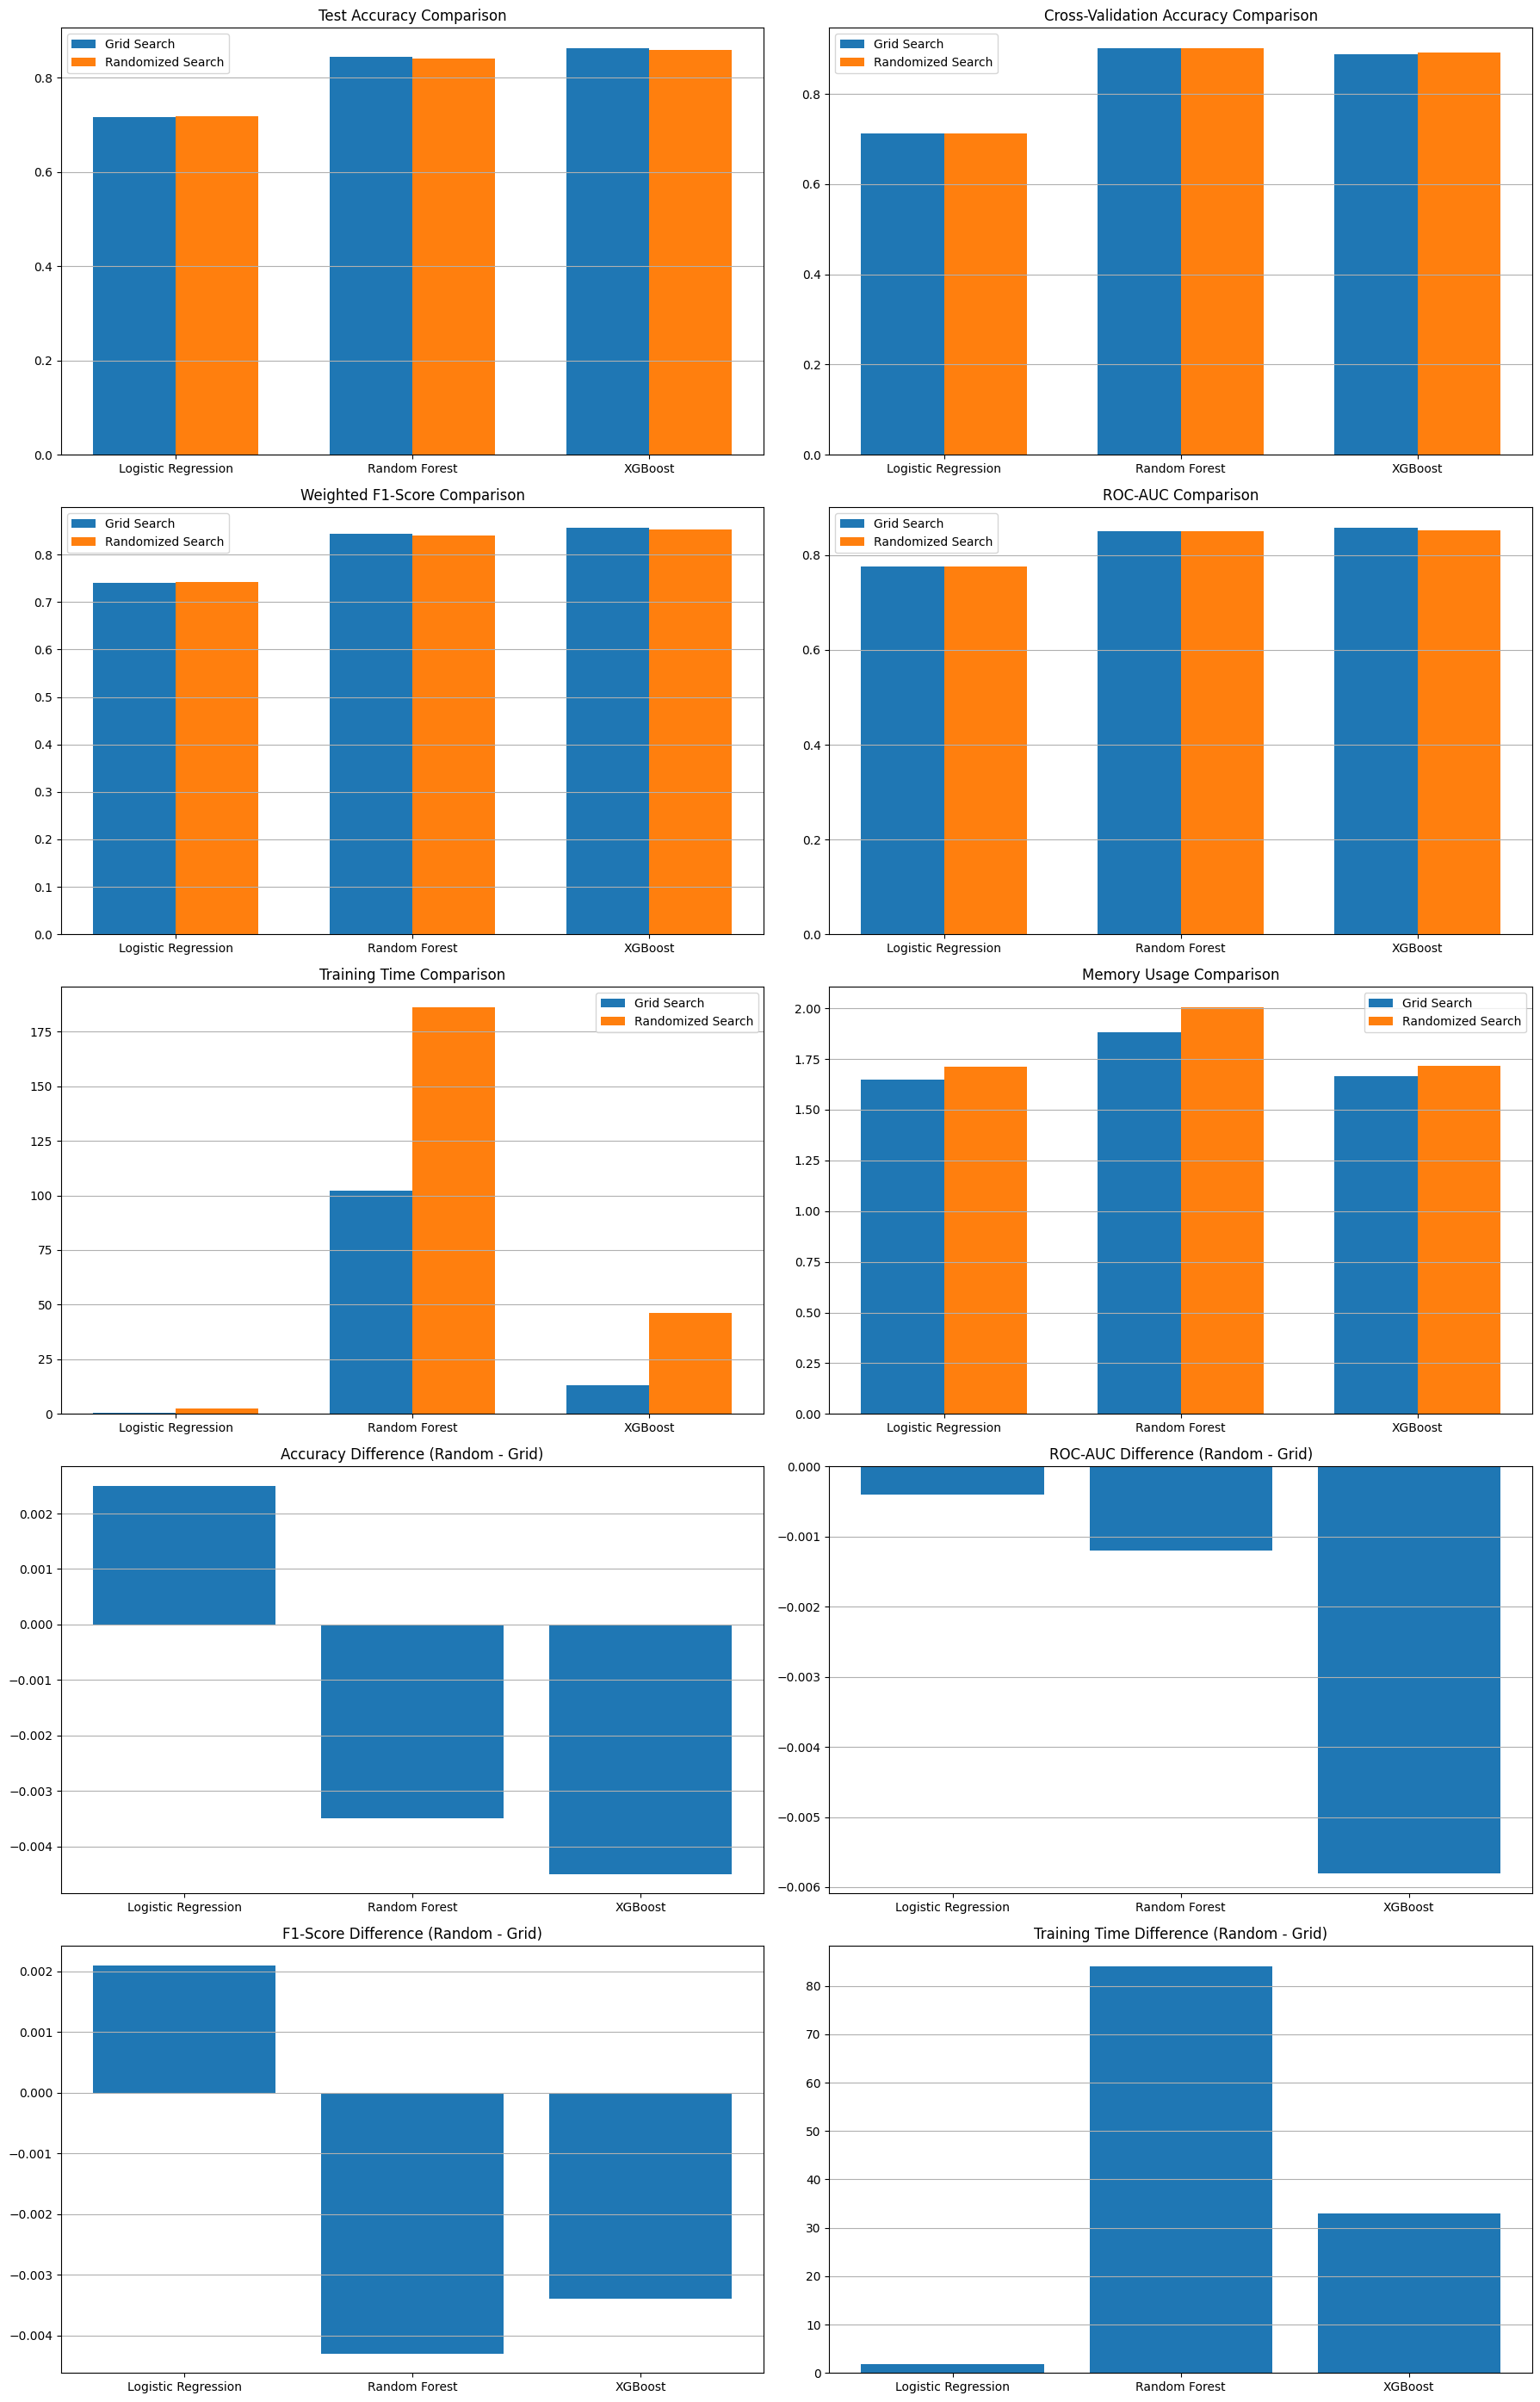

In [ ]:
# I imported the required libraries.
import matplotlib.pyplot as plt
import numpy as np

models = combined_tuning_results["Model"]

fig, axes = plt.subplots(5, 2, figsize=(18, 28))

bar_width = 0.35
x = np.arange(len(models))

# 1. Test Accuracy
axes[0,0].bar(x - bar_width/2, combined_tuning_results["Grid Test Accuracy"], bar_width, label="Grid Search")
axes[0,0].bar(x + bar_width/2, combined_tuning_results["Random Test Accuracy"], bar_width, label="Randomized Search")
axes[0,0].set_title("Test Accuracy Comparison")
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(models)
axes[0,0].legend()
axes[0,0].grid(axis='y')

# 2. CV Accuracy
axes[0,1].bar(x - bar_width/2, combined_tuning_results["Grid CV Accuracy"], bar_width, label="Grid Search")
axes[0,1].bar(x + bar_width/2, combined_tuning_results["Random CV Accuracy"], bar_width, label="Randomized Search")
axes[0,1].set_title("Cross-Validation Accuracy Comparison")
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(models)
axes[0,1].legend()
axes[0,1].grid(axis='y')

# 3. Weighted F1-Score
axes[1,0].bar(x - bar_width/2, combined_tuning_results["Grid F1-Score"], bar_width, label="Grid Search")
axes[1,0].bar(x + bar_width/2, combined_tuning_results["Random F1-Score"], bar_width, label="Randomized Search")
axes[1,0].set_title("Weighted F1-Score Comparison")
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(models)
axes[1,0].legend()
axes[1,0].grid(axis='y')

# 4. ROC-AUC
axes[1,1].bar(x - bar_width/2, combined_tuning_results["Grid ROC-AUC"], bar_width, label="Grid Search")
axes[1,1].bar(x + bar_width/2, combined_tuning_results["Random ROC-AUC"], bar_width, label="Randomized Search")
axes[1,1].set_title("ROC-AUC Comparison")
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(models)
axes[1,1].legend()
axes[1,1].grid(axis='y')

# 5. Training Time
axes[2,0].bar(x - bar_width/2, combined_tuning_results["Grid Training Time (s)"], bar_width, label="Grid Search")
axes[2,0].bar(x + bar_width/2, combined_tuning_results["Random Training Time (s)"], bar_width, label="Randomized Search")
axes[2,0].set_title("Training Time Comparison")
axes[2,0].set_xticks(x)
axes[2,0].set_xticklabels(models)
axes[2,0].legend()
axes[2,0].grid(axis='y')

# 6. Memory Usage
axes[2,1].bar(x - bar_width/2, combined_tuning_results["Grid Memory (MB)"], bar_width, label="Grid Search")
axes[2,1].bar(x + bar_width/2, combined_tuning_results["Random Memory (MB)"], bar_width, label="Randomized Search")
axes[2,1].set_title("Memory Usage Comparison")
axes[2,1].set_xticks(x)
axes[2,1].set_xticklabels(models)
axes[2,1].legend()
axes[2,1].grid(axis='y')

# 7. Grid vs Random Accuracy Difference
difference = combined_tuning_results["Random Test Accuracy"] - combined_tuning_results["Grid Test Accuracy"]
axes[3,0].bar(models, difference)
axes[3,0].set_title("Accuracy Difference (Random - Grid)")
axes[3,0].grid(axis='y')

# 8. Grid vs Random ROC Difference
difference = combined_tuning_results["Random ROC-AUC"] - combined_tuning_results["Grid ROC-AUC"]
axes[3,1].bar(models, difference)
axes[3,1].set_title("ROC-AUC Difference (Random - Grid)")
axes[3,1].grid(axis='y')

# 9. Grid vs Random F1 Difference
difference = combined_tuning_results["Random F1-Score"] - combined_tuning_results["Grid F1-Score"]
axes[4,0].bar(models, difference)
axes[4,0].set_title("F1-Score Difference (Random - Grid)")
axes[4,0].grid(axis='y')

# 10. Grid vs Random Training Time Difference
difference = combined_tuning_results["Random Training Time (s)"] - combined_tuning_results["Grid Training Time (s)"]
axes[4,1].bar(models, difference)
axes[4,1].set_title("Training Time Difference (Random - Grid)")
axes[4,1].grid(axis='y')

plt.tight_layout()
plt.show()

# Comparative Bar Graph Results  for GridSearch CV & RandomizedSearch CV

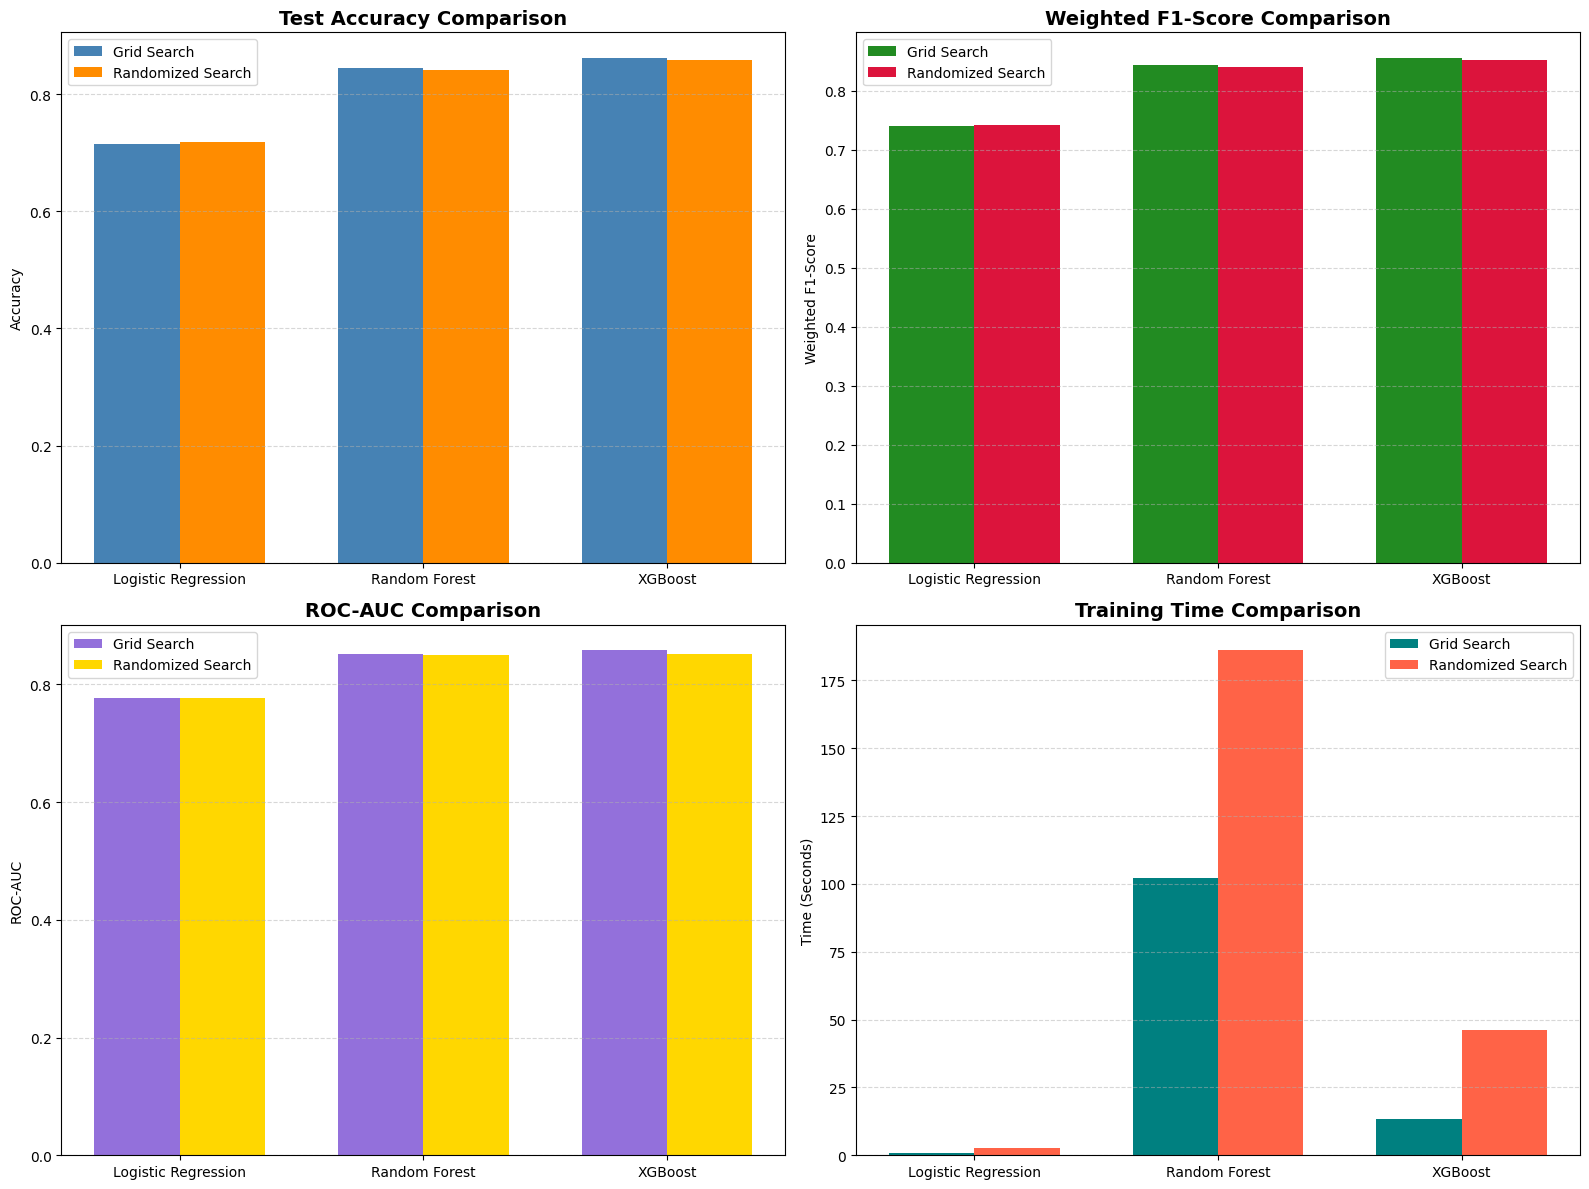

In [ ]:
# I imported the required libraries.
import matplotlib.pyplot as plt
import numpy as np

models = combined_tuning_results["Model"]
x = np.arange(len(models))
width = 0.35

fig, axes = plt.subplots(2, 2, figsize=(16, 12))


# Test Accuracy

axes[0,0].bar(x - width/2,
              combined_tuning_results["Grid Test Accuracy"],
              width,
              color="steelblue",
              label="Grid Search")

axes[0,0].bar(x + width/2,
              combined_tuning_results["Random Test Accuracy"],
              width,
              color="darkorange",
              label="Randomized Search")

axes[0,0].set_title("Test Accuracy Comparison", fontsize=14, fontweight="bold")
axes[0,0].set_ylabel("Accuracy")
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(models)
axes[0,0].legend()
axes[0,0].grid(axis="y", linestyle="--", alpha=0.5)


# Weighted F1-Score

axes[0,1].bar(x - width/2,
              combined_tuning_results["Grid F1-Score"],
              width,
              color="forestgreen",
              label="Grid Search")

axes[0,1].bar(x + width/2,
              combined_tuning_results["Random F1-Score"],
              width,
              color="crimson",
              label="Randomized Search")

axes[0,1].set_title("Weighted F1-Score Comparison", fontsize=14, fontweight="bold")
axes[0,1].set_ylabel("Weighted F1-Score")
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(models)
axes[0,1].legend()
axes[0,1].grid(axis="y", linestyle="--", alpha=0.5)


# ROC-AUC

axes[1,0].bar(x - width/2,
              combined_tuning_results["Grid ROC-AUC"],
              width,
              color="mediumpurple",
              label="Grid Search")

axes[1,0].bar(x + width/2,
              combined_tuning_results["Random ROC-AUC"],
              width,
              color="gold",
              label="Randomized Search")

axes[1,0].set_title("ROC-AUC Comparison", fontsize=14, fontweight="bold")
axes[1,0].set_ylabel("ROC-AUC")
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(models)
axes[1,0].legend()
axes[1,0].grid(axis="y", linestyle="--", alpha=0.5)


# Training Time

axes[1,1].bar(x - width/2,
              combined_tuning_results["Grid Training Time (s)"],
              width,
              color="teal",
              label="Grid Search")

axes[1,1].bar(x + width/2,
              combined_tuning_results["Random Training Time (s)"],
              width,
              color="tomato",
              label="Randomized Search")

axes[1,1].set_title("Training Time Comparison", fontsize=14, fontweight="bold")
axes[1,1].set_ylabel("Time (Seconds)")
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(models)
axes[1,1].legend()
axes[1,1].grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# Analysis

In [ ]:
combined_tuning_results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Artificial Neural Network"
    ],

    "Grid Accuracy": [
        grid_lr_accuracy,
        grid_rf_accuracy,
        grid_xgb_accuracy,
        np.nan
    ],

    "Random Accuracy": [
        random_lr_accuracy,
        random_rf_accuracy,
        random_xgb_accuracy,
        np.nan
    ],

    "ANN Accuracy": [
        np.nan,
        np.nan,
        np.nan,
        ann_accuracy
    ],

    "Grid F1": [
        grid_lr_f1_weighted,
        grid_rf_f1_weighted,
        grid_xgb_f1_weighted,
        np.nan
    ],

    "Random F1": [
        random_lr_f1_weighted,
        random_rf_f1_weighted,
        random_xgb_f1_weighted,
        np.nan
    ],

    "ANN F1": [
        np.nan,
        np.nan,
        np.nan,
        ann_f1_weighted
    ],

    "Grid ROC": [
        grid_lr_auc,
        grid_rf_auc,
        grid_xgb_auc,
        np.nan
    ],

    "Random ROC": [
        random_lr_auc,
        random_rf_auc,
        random_xgb_auc,
        np.nan
    ],

    "ANN ROC": [
        np.nan,
        np.nan,
        np.nan,
        ann_auc
    ]

})

# Visual Analysis

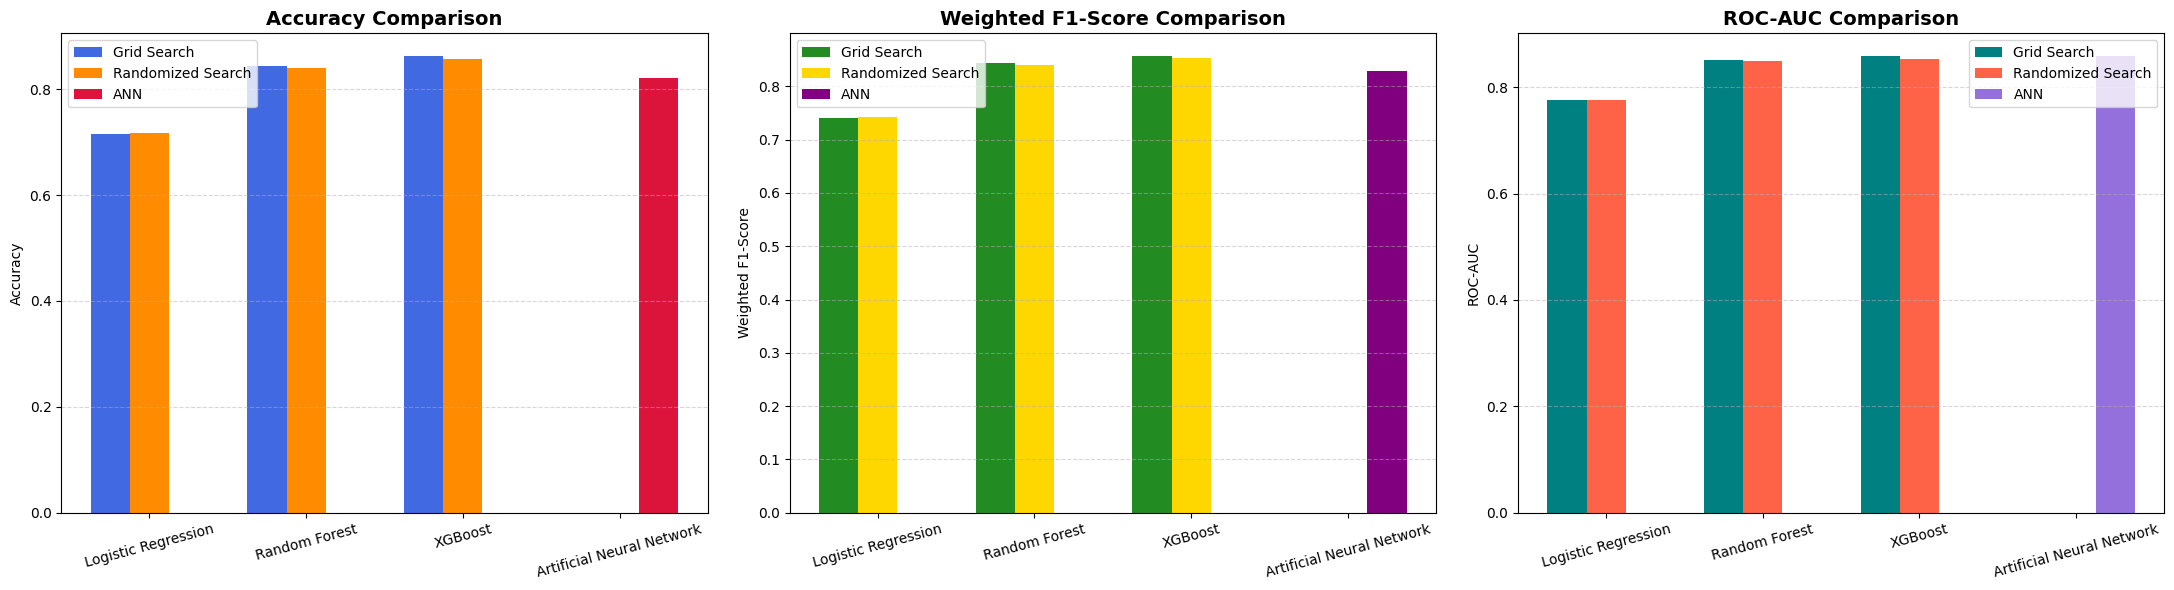

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ["Logistic Regression",
          "Random Forest",
          "XGBoost",
          "Artificial Neural Network"]

fig, axes = plt.subplots(1, 3, figsize=(22,6))

width = 0.25
x = np.arange(len(models))

#  Accuracy
axes[0].bar(x-width,
            combined_tuning_results["Grid Accuracy"],
            width,
            color="royalblue",
            label="Grid Search")

axes[0].bar(x,
            combined_tuning_results["Random Accuracy"],
            width,
            color="darkorange",
            label="Randomized Search")

axes[0].bar(x+width,
            combined_tuning_results["ANN Accuracy"],
            width,
            color="crimson",
            label="ANN")

axes[0].set_title("Accuracy Comparison",fontsize=14,fontweight="bold")
axes[0].set_ylabel("Accuracy")
axes[0].set_xticks(x)
axes[0].set_xticklabels(models,rotation=15)
axes[0].grid(axis='y',linestyle='--',alpha=0.5)
axes[0].legend()

#  F1
axes[1].bar(x-width,
            combined_tuning_results["Grid F1"],
            width,
            color="forestgreen",
            label="Grid Search")

axes[1].bar(x,
            combined_tuning_results["Random F1"],
            width,
            color="gold",
            label="Randomized Search")

axes[1].bar(x+width,
            combined_tuning_results["ANN F1"],
            width,
            color="purple",
            label="ANN")

axes[1].set_title("Weighted F1-Score Comparison",fontsize=14,fontweight="bold")
axes[1].set_ylabel("Weighted F1-Score")
axes[1].set_xticks(x)
axes[1].set_xticklabels(models,rotation=15)
axes[1].grid(axis='y',linestyle='--',alpha=0.5)
axes[1].legend()

#  ROC
axes[2].bar(x-width,
            combined_tuning_results["Grid ROC"],
            width,
            color="teal",
            label="Grid Search")

axes[2].bar(x,
            combined_tuning_results["Random ROC"],
            width,
            color="tomato",
            label="Randomized Search")

axes[2].bar(x+width,
            combined_tuning_results["ANN ROC"],
            width,
            color="mediumpurple",
            label="ANN")

axes[2].set_title("ROC-AUC Comparison",fontsize=14,fontweight="bold")
axes[2].set_ylabel("ROC-AUC")
axes[2].set_xticks(x)
axes[2].set_xticklabels(models,rotation=15)
axes[2].grid(axis='y',linestyle='--',alpha=0.5)
axes[2].legend()

plt.tight_layout()
plt.show()

 # Combined Comparative Table Results for Default , Cross , GridSearch CV & RandomizedSearch CV

In [ ]:
# I created the final comparison table for all evaluation methods.

final_model_comparison = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Artificial Neural Network"
    ],

    #  Default Model
    "Default Accuracy": [
        lr_accuracy,
        rf_accuracy,
        xgb_accuracy,
        ann_accuracy
    ],

    "Default F1-Score": [
        lr_f1_weighted,
        rf_f1_weighted,
        xgb_f1_weighted,
        ann_f1_weighted
    ],

    "Default ROC-AUC": [
        lr_auc,
        rf_auc,
        xgb_auc,
        ann_auc
    ],

    #  Cross Validation
    "CV Mean Accuracy": [
        lr_cv_results["Mean CV Accuracy"],
        rf_cv_results["Mean CV Accuracy"],
        xgb_cv_results["Mean CV Accuracy"],
        ann_cv_results["Mean CV Accuracy"]
    ],

    "CV Std Dev": [
        lr_cv_results["CV Standard Deviation"],
        rf_cv_results["CV Standard Deviation"],
        xgb_cv_results["CV Standard Deviation"],
        ann_cv_results["CV Standard Deviation"]
    ],

    #  Grid Search
    "Grid Accuracy": [
        grid_lr_accuracy,
        grid_rf_accuracy,
        grid_xgb_accuracy,
        np.nan
    ],

    "Grid F1-Score": [
        grid_lr_f1_weighted,
        grid_rf_f1_weighted,
        grid_xgb_f1_weighted,
        np.nan
    ],

    "Grid ROC-AUC": [
        grid_lr_auc,
        grid_rf_auc,
        grid_xgb_auc,
        np.nan
    ],

    # Randomized Search
    "Random Accuracy": [
        random_lr_accuracy,
        random_rf_accuracy,
        random_xgb_accuracy,
        np.nan
    ],

    "Random F1-Score": [
        random_lr_f1_weighted,
        random_rf_f1_weighted,
        random_xgb_f1_weighted,
        np.nan
    ],

    "Random ROC-AUC": [
        random_lr_auc,
        random_rf_auc,
        random_xgb_auc,
        np.nan
    ]

})

final_model_comparison = final_model_comparison.round(4)

display(final_model_comparison)

,Model,Default Accuracy,Default F1-Score,Default ROC-AUC,CV Mean Accuracy,CV Std Dev,Grid Accuracy,Grid F1-Score,Grid ROC-AUC,Random Accuracy,Random F1-Score,Random ROC-AUC
0,Logistic Regression,0.7155,0.7399,0.7769,0.7130,0.0062,0.7155,0.7399,0.7769,0.718,0.7420,0.7765
1,Random Forest,0.8420,0.8419,0.8473,0.8948,0.0068,0.8445,0.8443,0.8513,0.841,0.8400,0.8501
2,XGBoost,0.8470,0.8413,0.8383,0.9029,0.0070,0.8625,0.8566,0.8580,0.858,0.8532,0.8522
3,Artificial Neural Network,0.8210,0.8280,0.8585,0.7933,0.0083,NaN,NaN,NaN,NaN,NaN,NaN


# Visual Analysis

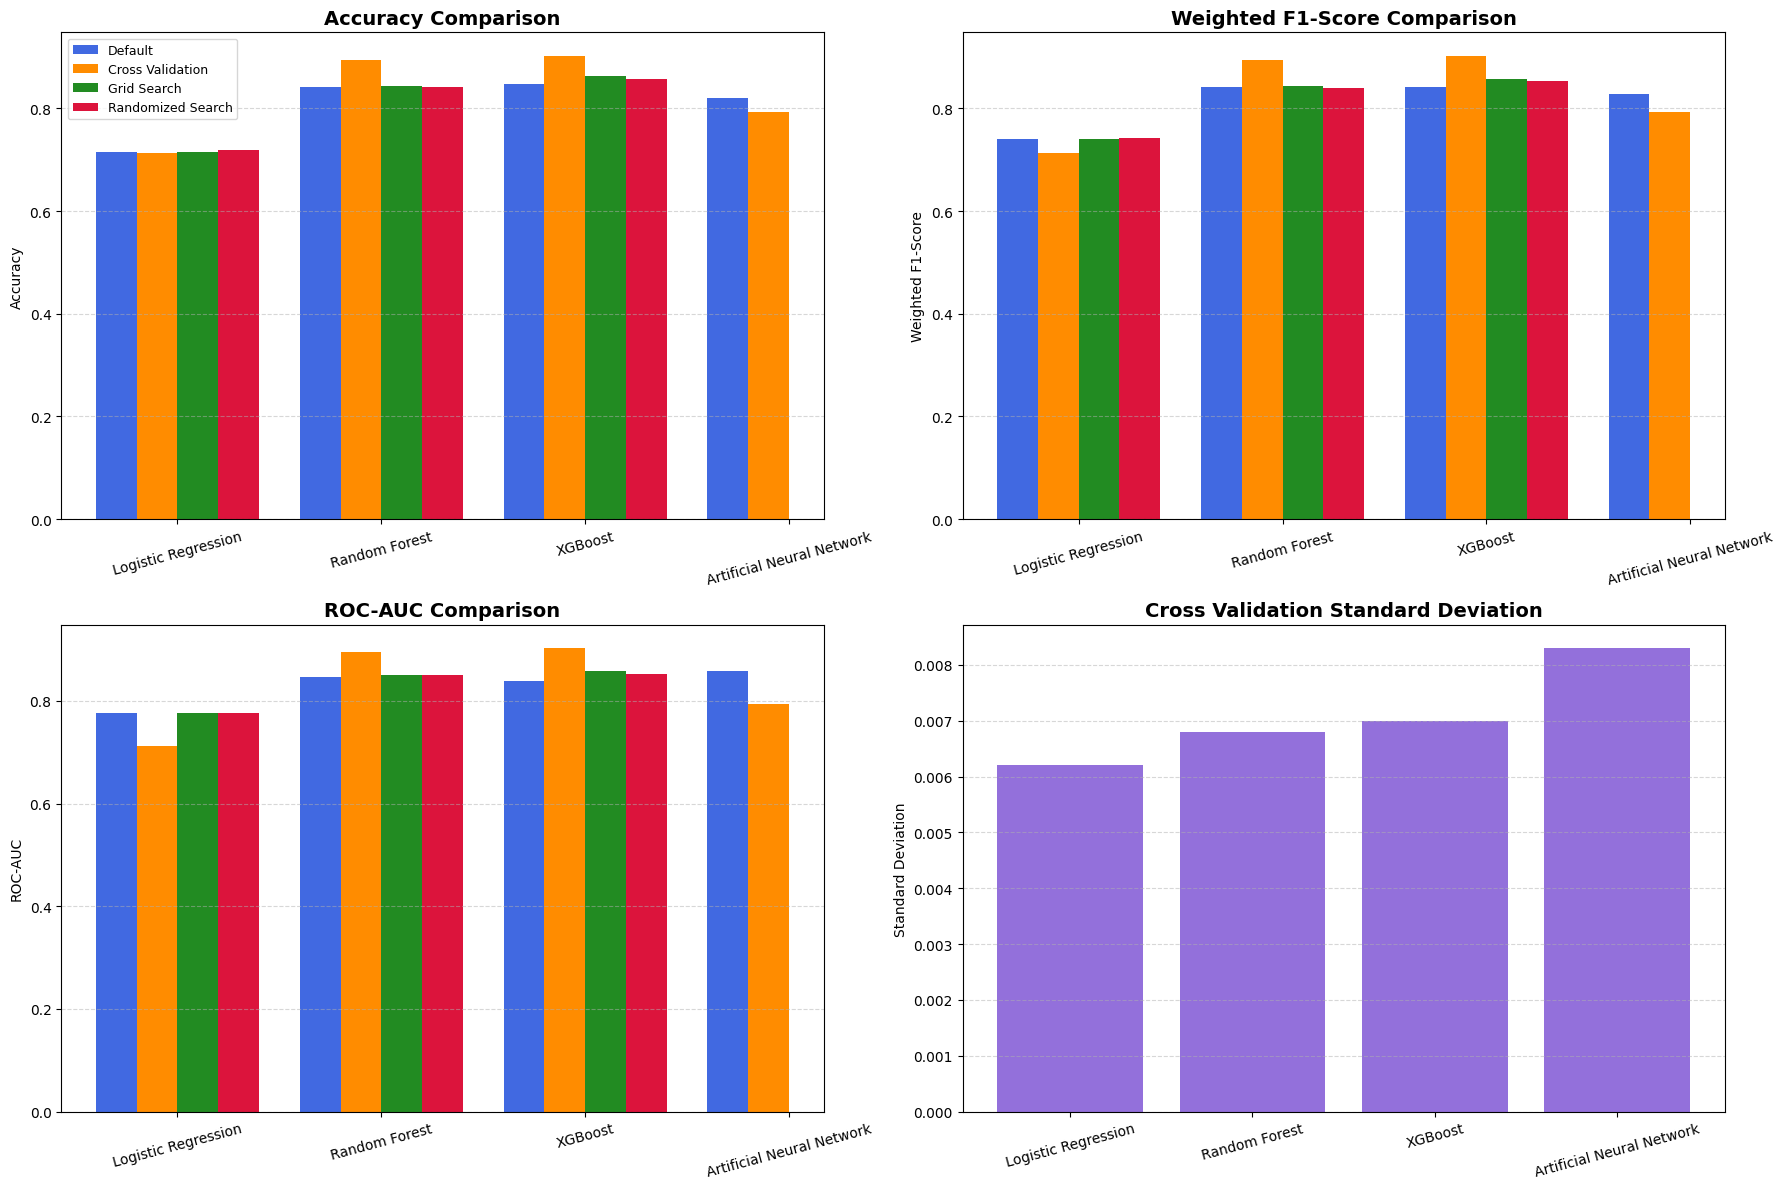

In [ ]:
# I imported the required libraries.
import matplotlib.pyplot as plt
import numpy as np

models = final_model_comparison["Model"]
x = np.arange(len(models))
width = 0.20

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Color palette
colors = ["royalblue", "darkorange", "forestgreen", "crimson"]


# Accuracy

axes[0,0].bar(x-1.5*width, final_model_comparison["Default Accuracy"],
              width, label="Default", color=colors[0])

axes[0,0].bar(x-0.5*width, final_model_comparison["CV Mean Accuracy"],
              width, label="Cross Validation", color=colors[1])

axes[0,0].bar(x+0.5*width, final_model_comparison["Grid Accuracy"],
              width, label="Grid Search", color=colors[2])

axes[0,0].bar(x+1.5*width, final_model_comparison["Random Accuracy"],
              width, label="Randomized Search", color=colors[3])

axes[0,0].set_title("Accuracy Comparison", fontsize=14, fontweight="bold")
axes[0,0].set_ylabel("Accuracy")
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(models, rotation=15)
axes[0,0].grid(axis='y', linestyle='--', alpha=0.5)
axes[0,0].legend(fontsize=9)


# Weighted F1-Score

axes[0,1].bar(x-1.5*width, final_model_comparison["Default F1-Score"],
              width, color=colors[0])

axes[0,1].bar(x-0.5*width, final_model_comparison["CV Mean Accuracy"],
              width, color=colors[1])

axes[0,1].bar(x+0.5*width, final_model_comparison["Grid F1-Score"],
              width, color=colors[2])

axes[0,1].bar(x+1.5*width, final_model_comparison["Random F1-Score"],
              width, color=colors[3])

axes[0,1].set_title("Weighted F1-Score Comparison", fontsize=14, fontweight="bold")
axes[0,1].set_ylabel("Weighted F1-Score")
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(models, rotation=15)
axes[0,1].grid(axis='y', linestyle='--', alpha=0.5)

# ROC-AUC

axes[1,0].bar(x-1.5*width, final_model_comparison["Default ROC-AUC"],
              width, color=colors[0])

axes[1,0].bar(x-0.5*width, final_model_comparison["CV Mean Accuracy"],
              width, color=colors[1])

axes[1,0].bar(x+0.5*width, final_model_comparison["Grid ROC-AUC"],
              width, color=colors[2])

axes[1,0].bar(x+1.5*width, final_model_comparison["Random ROC-AUC"],
              width, color=colors[3])

axes[1,0].set_title("ROC-AUC Comparison", fontsize=14, fontweight="bold")
axes[1,0].set_ylabel("ROC-AUC")
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(models, rotation=15)
axes[1,0].grid(axis='y', linestyle='--', alpha=0.5)


# Cross Validation Stability

axes[1,1].bar(models,
              final_model_comparison["CV Std Dev"],
              color="mediumpurple")

axes[1,1].set_title("Cross Validation Standard Deviation", fontsize=14, fontweight="bold")
axes[1,1].set_ylabel("Standard Deviation")
axes[1,1].tick_params(axis='x', rotation=15)
axes[1,1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Combined Bar Graph

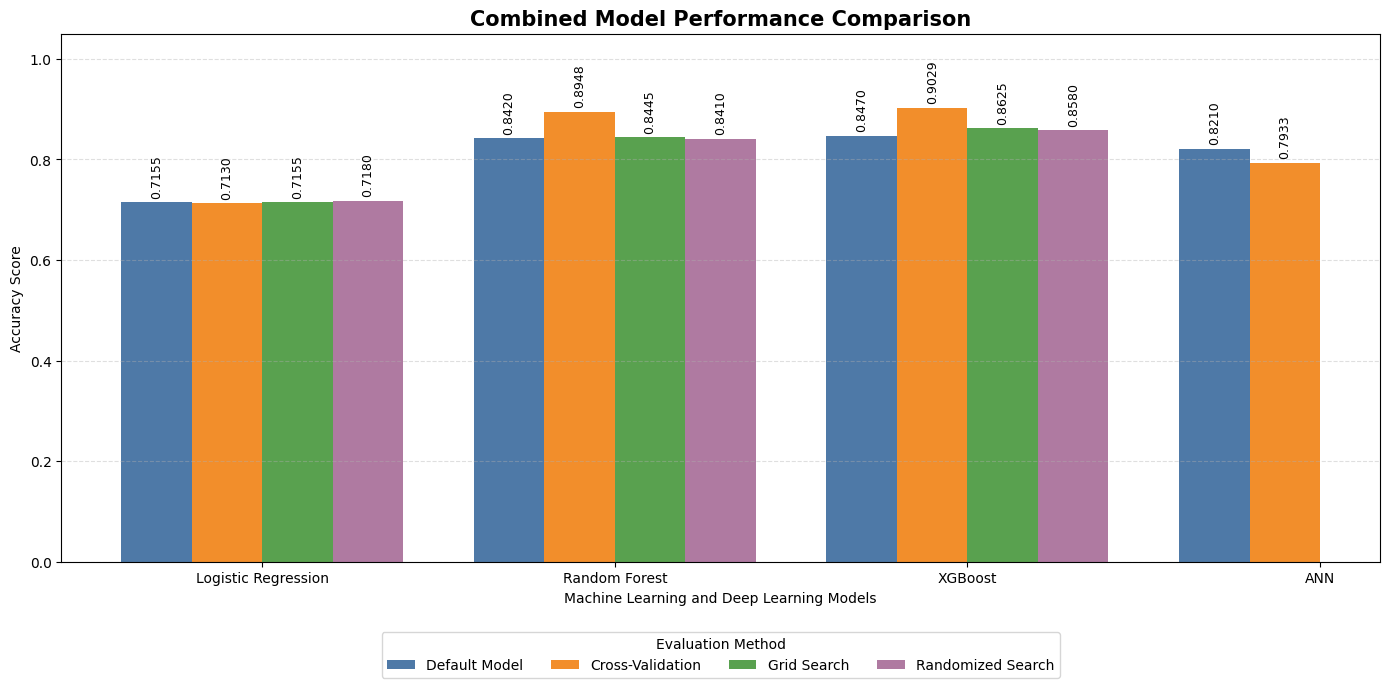

In [ ]:
# I imported the required libraries.
import matplotlib.pyplot as plt
import numpy as np

# I defined the model names.
models = [
    "Logistic Regression",
    "Random Forest",
    "XGBoost",
    "ANN"
]

# I extracted the accuracy results.
default_results = final_model_comparison["Default Accuracy"].values
cross_results = final_model_comparison["CV Mean Accuracy"].values
grid_results = final_model_comparison["Grid Accuracy"].values
random_results = final_model_comparison["Random Accuracy"].values

# I created positions for each model.
x = np.arange(len(models))

# I defined the width of each bar.
width = 0.20

# I created the figure.
plt.figure(figsize=(14, 7))

# I plotted the Default Model results.
bars1 = plt.bar(
    x - 1.5 * width,
    default_results,
    width,
    label="Default Model",
    color="#4E79A7"
)

# I plotted the Cross-Validation results.
bars2 = plt.bar(
    x - 0.5 * width,
    cross_results,
    width,
    label="Cross-Validation",
    color="#F28E2B"
)

# I plotted the Grid Search results.
bars3 = plt.bar(
    x + 0.5 * width,
    grid_results,
    width,
    label="Grid Search",
    color="#59A14F"
)

# I plotted the Randomized Search results.
bars4 = plt.bar(
    x + 1.5 * width,
    random_results,
    width,
    label="Randomized Search",
    color="#AF7AA1"
)

# I added values above each available bar.
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        height = bar.get_height()

        if not np.isnan(height):
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.008,
                f"{height:.4f}",
                ha="center",
                va="bottom",
                fontsize=9,
                rotation=90
            )

# I added the graph title.
plt.title(
    "Combined Model Performance Comparison",
    fontsize=15,
    fontweight="bold"
)

# I labelled the axes.
plt.xlabel("Machine Learning and Deep Learning Models")
plt.ylabel("Accuracy Score")

# I added the model names.
plt.xticks(x, models)

# I set the y-axis range.
plt.ylim(0, 1.05)

# I added the legend.
plt.legend(
    title="Evaluation Method",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=4
)

# I added horizontal grid lines.
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

# I adjusted the layout.
plt.tight_layout()

# I displayed the graph.
plt.show()

# Printing Best Model

In [ ]:
# I imported the required libraries.
import pandas as pd
import numpy as np

# I created a structured table containing the available results
# from Default, Grid Search, and Randomized Search models.
best_model_results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "ANN",
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Method": [
        "Default",
        "Default",
        "Default",
        "Default",
        "Grid Search",
        "Grid Search",
        "Grid Search",
        "Randomized Search",
        "Randomized Search",
        "Randomized Search"
    ],

    "Accuracy": [
        lr_accuracy,
        rf_accuracy,
        xgb_accuracy,
        ann_accuracy,
        grid_lr_accuracy,
        grid_rf_accuracy,
        grid_xgb_accuracy,
        random_lr_accuracy,
        random_rf_accuracy,
        random_xgb_accuracy
    ],

    "Weighted F1-Score": [
        lr_f1_weighted,
        rf_f1_weighted,
        xgb_f1_weighted,
        ann_f1_weighted,
        grid_lr_f1_weighted,
        grid_rf_f1_weighted,
        grid_xgb_f1_weighted,
        random_lr_f1_weighted,
        random_rf_f1_weighted,
        random_xgb_f1_weighted
    ],

    "ROC-AUC": [
        lr_auc,
        rf_auc,
        xgb_auc,
        ann_auc,
        grid_lr_auc,
        grid_rf_auc,
        grid_xgb_auc,
        random_lr_auc,
        random_rf_auc,
        random_xgb_auc
    ]
})

# I ranked the models primarily by Accuracy,
# followed by Weighted F1-Score and ROC-AUC.
best_model_results = best_model_results.sort_values(
    by=["Accuracy", "Weighted F1-Score", "ROC-AUC"],
    ascending=False
).reset_index(drop=True)

# I selected the highest-performing model.
best_model_name = best_model_results.loc[0, "Model"]
best_model_method = best_model_results.loc[0, "Method"]
best_model_accuracy = best_model_results.loc[0, "Accuracy"]
best_model_f1 = best_model_results.loc[0, "Weighted F1-Score"]
best_model_auc = best_model_results.loc[0, "ROC-AUC"]

# I displayed the complete ranking.
print("Overall Model Performance Ranking")
display(best_model_results.round(4))

# I displayed the best model.
print("\nBest Performing Model")
print("Model              :", best_model_name)
print("Method             :", best_model_method)
print("Accuracy           :", round(best_model_accuracy, 4))
print("Weighted F1-Score  :", round(best_model_f1, 4))
print("ROC-AUC            :", round(best_model_auc, 4))

# I displayed the reasons for selecting the best model.
print("\nReasons for Selecting the Best Model:")

print(
    "1. The", best_model_name,
    "achieved the highest overall Accuracy of",
    round(best_model_accuracy, 4),
    "among the evaluated model configurations."
)

print(
    "2. It achieved a Weighted F1-Score of",
    round(best_model_f1, 4),
    "demonstrating its overall classification performance while considering class distribution."
)

print(
    "3. It achieved a ROC-AUC score of",
    round(best_model_auc, 4),
    "demonstrating its ability to distinguish between the target classes."
)

print(
    "4. The combination of Accuracy, Weighted F1-Score, and ROC-AUC "
    "provides evidence for selecting this configuration as the best-performing model."
)

print(
    "5. Therefore, the", best_model_name,
    "using", best_model_method,
    "was selected as the final model for further analysis and prototype development."
)

Overall Model Performance Ranking


,Model,Method,Accuracy,Weighted F1-Score,ROC-AUC
0,XGBoost,Grid Search,0.8625,0.8566,0.8580
1,XGBoost,Randomized Search,0.8580,0.8532,0.8522
2,XGBoost,Default,0.8470,0.8413,0.8383
3,Random Forest,Grid Search,0.8445,0.8443,0.8513
4,Random Forest,Default,0.8420,0.8419,0.8473
5,Random Forest,Randomized Search,0.8410,0.8400,0.8501
6,ANN,Default,0.8210,0.8280,0.8585
7,Logistic Regression,Randomized Search,0.7180,0.7420,0.7765
8,Logistic Regression,Default,0.7155,0.7399,0.7769
9,Logistic Regression,Grid Search,0.7155,0.7399,0.7769



Best Performing Model
Model              : XGBoost
Method             : Grid Search
Accuracy           : 0.8625
Weighted F1-Score  : 0.8566
ROC-AUC            : 0.858

Reasons for Selecting the Best Model:
1. The XGBoost achieved the highest overall Accuracy of 0.8625 among the evaluated model configurations.
2. It achieved a Weighted F1-Score of 0.8566 demonstrating its overall classification performance while considering class distribution.
3. It achieved a ROC-AUC score of 0.858 demonstrating its ability to distinguish between the target classes.
4. The combination of Accuracy, Weighted F1-Score, and ROC-AUC provides evidence for selecting this configuration as the best-performing model.
5. Therefore, the XGBoost using Grid Search was selected as the final model for further analysis and prototype development.


In [ ]:
# I imported the required library.
import pandas as pd

# I created the performance comparison table.
best_model_results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Artificial Neural Network",
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Method": [
        "Default",
        "Default",
        "Default",
        "Default",
        "Grid Search",
        "Grid Search",
        "Grid Search",
        "Randomized Search",
        "Randomized Search",
        "Randomized Search"
    ],

    "Accuracy": [
        lr_accuracy,
        rf_accuracy,
        xgb_accuracy,
        ann_accuracy,
        grid_lr_accuracy,
        grid_rf_accuracy,
        grid_xgb_accuracy,
        random_lr_accuracy,
        random_rf_accuracy,
        random_xgb_accuracy
    ],

    "Weighted F1-Score": [
        lr_f1_weighted,
        rf_f1_weighted,
        xgb_f1_weighted,
        ann_f1_weighted,
        grid_lr_f1_weighted,
        grid_rf_f1_weighted,
        grid_xgb_f1_weighted,
        random_lr_f1_weighted,
        random_rf_f1_weighted,
        random_xgb_f1_weighted
    ],

    "ROC-AUC": [
        lr_auc,
        rf_auc,
        xgb_auc,
        ann_auc,
        grid_lr_auc,
        grid_rf_auc,
        grid_xgb_auc,
        random_lr_auc,
        random_rf_auc,
        random_xgb_auc
    ]

})

# I calculated an overall performance score.
best_model_results["Final Score"] = (
      0.40 * best_model_results["Accuracy"]
    + 0.30 * best_model_results["Weighted F1-Score"]
    + 0.30 * best_model_results["ROC-AUC"]
)

# I sorted the models based on the final score.
best_model_results = best_model_results.sort_values(
    by="Final Score",
    ascending=False
).reset_index(drop=True)

# I selected the best model.
best_model = best_model_results.iloc[0]

# I displayed the ranking.
print("Overall Model Ranking")
display(best_model_results.round(4))

print("\nBest Model Selected")

print("Model              :", best_model["Model"])
print("Method             :", best_model["Method"])
print("Accuracy           :", round(best_model["Accuracy"],4))
print("Weighted F1-Score  :", round(best_model["Weighted F1-Score"],4))
print("ROC-AUC            :", round(best_model["ROC-AUC"],4))
print("Final Score        :", round(best_model["Final Score"],4))

print("\nReasons for Selecting the Best Model")


print("1. It achieved the highest overall performance score among all evaluated models.")

print("2. It produced a high prediction accuracy, demonstrating reliable classification performance.")

print("3. It achieved a high Weighted F1-Score, indicating balanced performance across both classes.")

print("4. It achieved a strong ROC-AUC score, demonstrating excellent discrimination between the target classes.")

print("5. Considering Accuracy, Weighted F1-Score, and ROC-AUC together, this model provided the best overall predictive performance.")

print("6. Therefore, this model was selected as the final model for prototype development and explainability analysis.")

Overall Model Ranking


,Model,Method,Accuracy,Weighted F1-Score,ROC-AUC,Final Score
0,XGBoost,Grid Search,0.8625,0.8566,0.8580,0.8594
1,XGBoost,Randomized Search,0.8580,0.8532,0.8522,0.8548
2,Random Forest,Grid Search,0.8445,0.8443,0.8513,0.8465
3,Random Forest,Default,0.8420,0.8419,0.8473,0.8435
4,Random Forest,Randomized Search,0.8410,0.8400,0.8501,0.8434
5,XGBoost,Default,0.8470,0.8413,0.8383,0.8427
6,Artificial Neural Network,Default,0.8210,0.8280,0.8585,0.8343
7,Logistic Regression,Randomized Search,0.7180,0.7420,0.7765,0.7427
8,Logistic Regression,Default,0.7155,0.7399,0.7769,0.7412
9,Logistic Regression,Grid Search,0.7155,0.7399,0.7769,0.7412



Best Model Selected
Model              : XGBoost
Method             : Grid Search
Accuracy           : 0.8625
Weighted F1-Score  : 0.8566
ROC-AUC            : 0.858
Final Score        : 0.8594

Reasons for Selecting the Best Model
1. It achieved the highest overall performance score among all evaluated models.
2. It produced a high prediction accuracy, demonstrating reliable classification performance.
3. It achieved a high Weighted F1-Score, indicating balanced performance across both classes.
4. It achieved a strong ROC-AUC score, demonstrating excellent discrimination between the target classes.
5. Considering Accuracy, Weighted F1-Score, and ROC-AUC together, this model provided the best overall predictive performance.
6. Therefore, this model was selected as the final model for prototype development and explainability analysis.


# SHAP Analysis

SHAP Analysis Completed Successfully
Best Model: XGBoost with Grid Search
Number of Samples Analysed: 2000


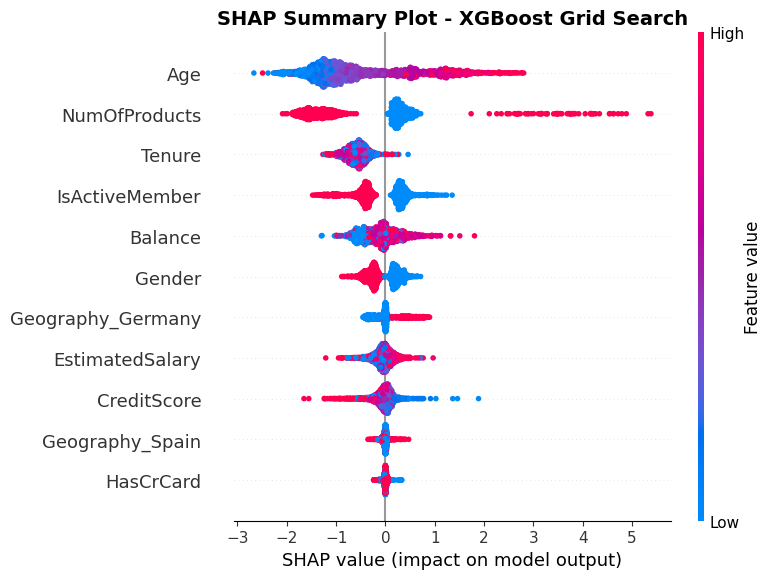

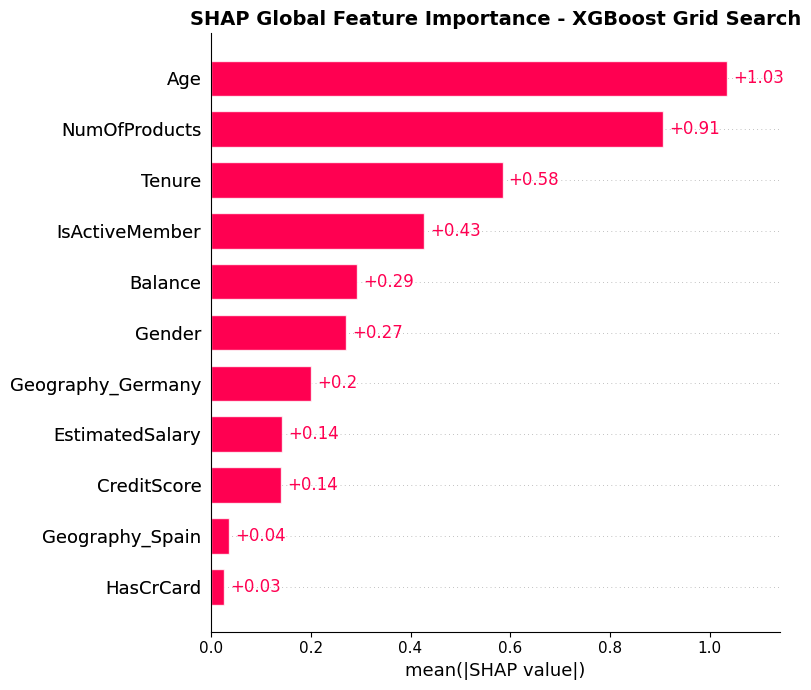


Top 15 Most Important Features


,Rank,Feature,Mean Absolute SHAP Value
0,1,Age,1.0350
1,2,NumOfProducts,0.9073
2,3,Tenure,0.5846
3,4,IsActiveMember,0.4265
4,5,Balance,0.2932
5,6,Gender,0.2711
6,7,Geography_Germany,0.2006
7,8,EstimatedSalary,0.1431
8,9,CreditScore,0.1408
9,10,Geography_Spain,0.0356



Most Influential Feature: Age


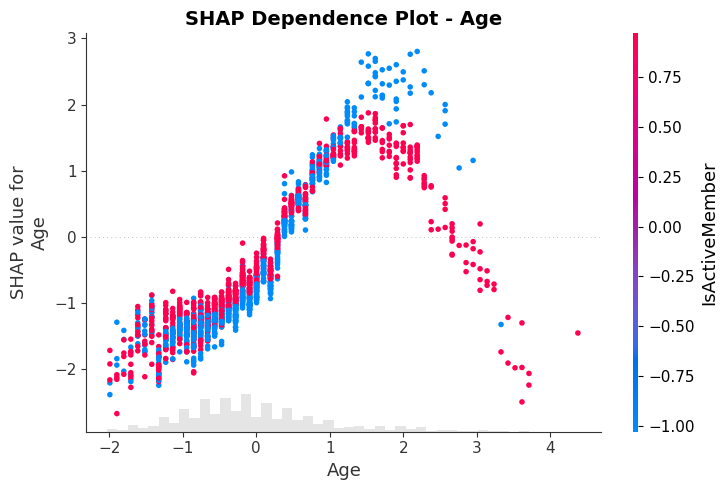


Individual Prediction Analysis
Predicted Class: 1
Predicted Probability: 0.586


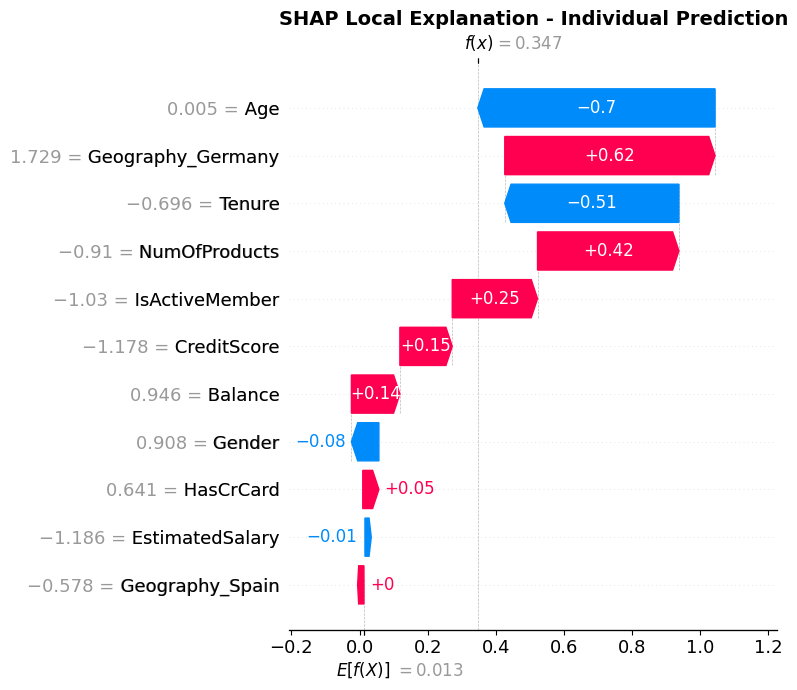

In [ ]:
# I imported the required libraries for SHAP analysis.
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# I selected the best-performing model identified after model comparison.
best_xgb_model = grid_xgb_best_model

# I obtained the original feature names.
feature_names = list(X.columns)

# I converted the scaled testing dataset into a DataFrame
# so that the original feature names are displayed in SHAP plots.
X_test_shap = pd.DataFrame(
    X_test_scaled,
    columns=feature_names
)

# I selected a sample from the testing dataset to make
# SHAP analysis computationally efficient.
shap_sample_size = min(10000, len(X_test_shap))

X_shap_sample = X_test_shap.sample(
    n=shap_sample_size,
    random_state=42
)

# I created the SHAP TreeExplainer because the selected
# best-performing model was XGBoost.
explainer = shap.TreeExplainer(best_xgb_model)

# I calculated SHAP values for the selected testing samples.
shap_values = explainer(X_shap_sample)

print("SHAP Analysis Completed Successfully")
print("Best Model: XGBoost with Grid Search")
print("Number of Samples Analysed:", shap_sample_size)


# I created the SHAP beeswarm plot to show both the
# importance and direction of influence of each feature.
plt.figure()

shap.plots.beeswarm(
    shap_values,
    max_display=15,
    show=False
)

plt.title(
    "SHAP Summary Plot - XGBoost Grid Search",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


# I created the SHAP bar plot to show global feature importance.
plt.figure()

shap.plots.bar(
    shap_values,
    max_display=15,
    show=False
)

plt.title(
    "SHAP Global Feature Importance - XGBoost Grid Search",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


# I calculated the mean absolute SHAP value for every feature.
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

# I created a feature importance table.
shap_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean Absolute SHAP Value": mean_abs_shap
})

# I sorted the features from most important to least important.
shap_importance_df = shap_importance_df.sort_values(
    by="Mean Absolute SHAP Value",
    ascending=False
).reset_index(drop=True)

# I stored the rank of each feature.
shap_importance_df["Rank"] = (
    np.arange(1, len(shap_importance_df) + 1)
)

# I rearranged the columns.
shap_importance_df = shap_importance_df[
    [
        "Rank",
        "Feature",
        "Mean Absolute SHAP Value"
    ]
]

print("\nTop 15 Most Important Features")

display(
    shap_importance_df.head(15).round(4)
)


# I stored the most influential feature.
top_shap_feature = shap_importance_df.iloc[0]["Feature"]

print(
    "\nMost Influential Feature:",
    top_shap_feature
)


# I created a SHAP scatter/dependence plot for the
# most influential feature.
shap.plots.scatter(
    shap_values[:, top_shap_feature],
    color=shap_values,
    show=False
)

plt.title(
    f"SHAP Dependence Plot - {top_shap_feature}",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


# I selected one individual prediction for local analysis.
instance_index = 0

# I obtained the model's predicted probability for this instance.
individual_probability = best_xgb_model.predict_proba(
    X_shap_sample.iloc[[instance_index]]
)[0, 1]

# I obtained the predicted class.
individual_prediction = best_xgb_model.predict(
    X_shap_sample.iloc[[instance_index]]
)[0]

print("\nIndividual Prediction Analysis")
print("Predicted Class:", individual_prediction)
print(
    "Predicted Probability:",
    round(individual_probability, 4)
)


# I created a SHAP waterfall plot to explain
# one individual prediction.
shap.plots.waterfall(
    shap_values[instance_index],
    max_display=15,
    show=False
)

plt.title(
    "SHAP Local Explanation - Individual Prediction",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# Real-World Banking Application Performance and Practical Customer Impact Analysis

In [ ]:
# I imported the required libraries.
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

# I used the predictions from the best-performing
# XGBoost model optimized using Grid Search.
best_model_predictions = y_pred_grid_xgb
best_model_probabilities = y_prob_grid_xgb

# I calculated the confusion matrix.
tn, fp, fn, tp = confusion_matrix(
    y_test,
    best_model_predictions
).ravel()

# I stored the total number of customers evaluated.
total_customers = len(y_test)

# I calculated the number of correct and incorrect predictions.
correct_predictions = tp + tn
incorrect_predictions = fp + fn

# I calculated percentages for real-world interpretation.
correct_percentage = (
    correct_predictions / total_customers
) * 100

incorrect_percentage = (
    incorrect_predictions / total_customers
) * 100

# I calculated the percentage of actual churn customers
# correctly identified by the model.
churn_detection_rate = (
    tp / (tp + fn)
) * 100 if (tp + fn) > 0 else 0

# I calculated the percentage of non-churn customers
# correctly identified by the model.
non_churn_detection_rate = (
    tn / (tn + fp)
) * 100 if (tn + fp) > 0 else 0

# I estimated the practical impact for every 1,000 customers.
customers_example = 1000

estimated_correct = round(
    customers_example * grid_xgb_accuracy
)

estimated_incorrect = (
    customers_example - estimated_correct
)

# I created a real-world banking interpretation table.
banking_impact_table = pd.DataFrame({

    "Performance Measure": [
        "Model Used",
        "Accuracy",
        "Weighted F1-Score",
        "ROC-AUC",
        "Correct Predictions",
        "Incorrect Predictions",
        "Churn Customers Correctly Identified",
        "Non-Churn Customers Correctly Identified"
    ],

    "Result": [
        "XGBoost - Grid Search",
        f"{grid_xgb_accuracy * 100:.2f}%",
        f"{grid_xgb_f1_weighted * 100:.2f}%",
        f"{grid_xgb_auc * 100:.2f}%",
        f"{correct_predictions} ({correct_percentage:.2f}%)",
        f"{incorrect_predictions} ({incorrect_percentage:.2f}%)",
        f"{churn_detection_rate:.2f}%",
        f"{non_churn_detection_rate:.2f}%"
    ],

    "Meaning for Banking Application": [

        "The selected predictive model used in the banking application.",

        "Shows how often the system makes the correct customer classification overall.",

        "Shows the model's balanced classification performance while considering both customer classes.",

        "Shows how effectively the system distinguishes customers with different churn outcomes.",

        "Customers for whom the banking system could make the correct predictive classification.",

        "Customers who could receive an incorrect classification and may require additional review.",

        "Shows how effectively the system identifies customers who may be at risk of leaving the bank.",

        "Shows how effectively the system identifies customers who are likely to remain with the bank."
    ]
})

# I displayed the real-world banking impact table.
print("Real-World Banking Application Analysis")

display(banking_impact_table)


# I displayed a simple 1,000-customer interpretation.
print("\nPractical Interpretation for 1,000 Customers")

print(
    "If the banking application analysed 1,000 customers, "
    f"approximately {estimated_correct} customers could be "
    "classified correctly and approximately "
    f"{estimated_incorrect} customers could be classified incorrectly, "
    "based on the observed test accuracy."
)

print(
    "\nAn accuracy of "
    f"{grid_xgb_accuracy * 100:.2f}% means that the model correctly "
    "classified approximately "
    f"{grid_xgb_accuracy * 100:.2f} out of every 100 customers "
    "in the held-out test data."
)

print(
    "\nThe Weighted F1-Score of "
    f"{grid_xgb_f1_weighted * 100:.2f}% indicates strong overall "
    "classification performance while accounting for the performance "
    "across the customer classes."
)

print(
    "\nThe ROC-AUC score of "
    f"{grid_xgb_auc * 100:.2f}% indicates that the model has a strong "
    "ability to distinguish between customers with different churn outcomes."
)

print(
    "\nBanking Application Meaning: "
    "These predictions could support customer-retention teams in "
    "prioritising customers identified as being at higher risk of churn. "
    "The predictions should support, rather than automatically determine, "
    "customer-level decisions."
)

Real-World Banking Application Analysis


,Performance Measure,Result,Meaning for Banking Application
0,Model Used,XGBoost - Grid Search,The selected predictive model used in the bank...
1,Accuracy,86.25%,Shows how often the system makes the correct c...
2,Weighted F1-Score,85.66%,Shows the model's balanced classification perf...
3,ROC-AUC,85.80%,Shows how effectively the system distinguishes...
4,Correct Predictions,1725 (86.25%),Customers for whom the banking system could ma...
5,Incorrect Predictions,275 (13.75%),Customers who could receive an incorrect class...
6,Churn Customers Correctly Identified,56.27%,Shows how effectively the system identifies cu...
7,Non-Churn Customers Correctly Identified,93.91%,Shows how effectively the system identifies cu...



Practical Interpretation for 1,000 Customers
If the banking application analysed 1,000 customers, approximately 862 customers could be classified correctly and approximately 138 customers could be classified incorrectly, based on the observed test accuracy.

An accuracy of 86.25% means that the model correctly classified approximately 86.25 out of every 100 customers in the held-out test data.

The Weighted F1-Score of 85.66% indicates strong overall classification performance while accounting for the performance across the customer classes.

The ROC-AUC score of 85.80% indicates that the model has a strong ability to distinguish between customers with different churn outcomes.

Banking Application Meaning: These predictions could support customer-retention teams in prioritising customers identified as being at higher risk of churn. The predictions should support, rather than automatically determine, customer-level decisions.


# Advanced Real-World Banking Application and Customer Churn Decision-Support Analysis

Real-World Banking Model Performance


,Performance Measure,Result (%),Banking Interpretation
0,Accuracy,86.25,Percentage of all customers correctly classifi...
1,Weighted F1-Score,85.66,Overall classification performance while accou...
2,ROC-AUC,85.80,Ability of the model to distinguish between cu...
3,Churn Precision,70.25,Percentage of customers predicted as churn ris...
4,Churn Detection Rate,56.27,Percentage of actual churn customers successfu...
5,Non-Churn Detection Rate,93.91,Percentage of actual non-churn customers corre...
6,False Alarm Rate,6.09,Percentage of non-churn customers incorrectly ...
7,Missed Churn Rate,43.73,Percentage of actual churn customers missed by...



Customer-Level Classification Outcomes


,Customer Outcome,Number of Customers,Banking Meaning
0,True Positive - Correct Churn Identification,229,Customers correctly identified as being at ris...
1,True Negative - Correct Non-Churn Identification,1496,Customers correctly identified as likely to re...
2,False Positive - False Churn Alert,97,"Customers incorrectly flagged as churn risks, ..."
3,False Negative - Missed Churn Customer,178,At-risk customers missed by the model who may ...



Customer Churn Risk Segmentation


,Risk Level,Customers,Average Churn Probability (%),Actual Churners,Actual Churn Rate (%)
0,Low Risk,1443,9.740000,117,8.11
1,Moderate Risk,231,39.310001,61,26.41
2,High Risk,144,59.790001,72,50.00
3,Very High Risk,182,88.199997,157,86.26


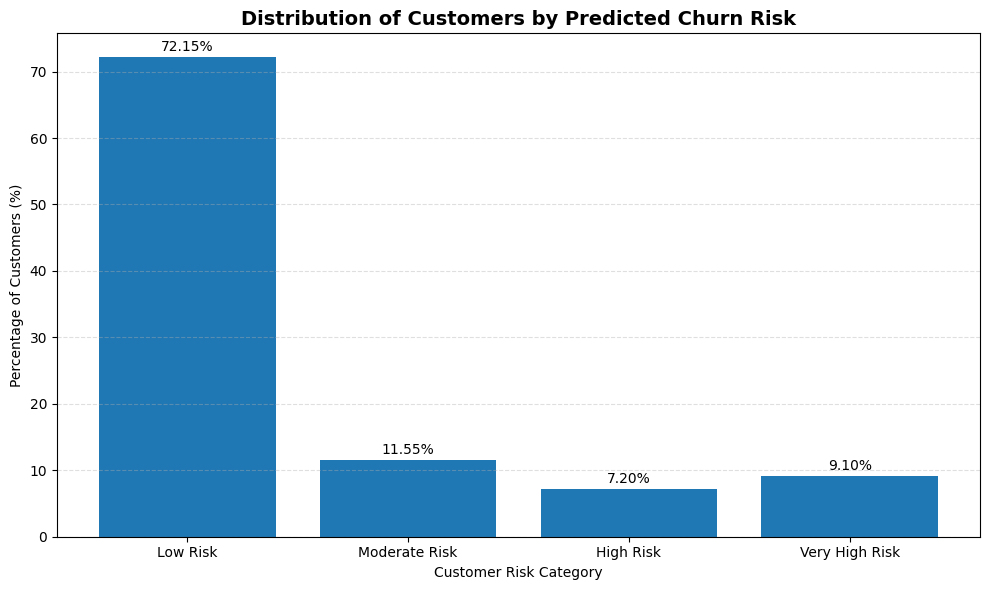


Targeted Customer Retention Analysis


,Business Measure,Result,Banking Meaning
0,Customers in Top 10% Risk Group,200,Number of customers the retention team would n...
1,Actual Churners Captured in Top 10%,168,Number of actual churn customers successfully ...
2,Capture Rate at Top 10%,41.28%,Percentage of all actual churners identified b...
3,Overall Customer Churn Rate,20.35%,Baseline proportion of customers who actually ...
4,Churn Rate in Top 10% Risk Group,84.00%,Concentration of actual churners among custome...
5,Lift at Top 10%,4.13x,Shows how much more effectively the model iden...



Banking Intervention Threshold Analysis


,Threshold,Customers Flagged,Customers Flagged (%),True Churners Identified,Missed Churners,False Alerts,Precision,Recall
0,0.3,557,27.85,290,117,267,0.5206,0.7125
1,0.4,433,21.65,263,144,170,0.6074,0.6462
2,0.5,326,16.30,229,178,97,0.7025,0.5627
3,0.6,253,12.65,196,211,57,0.7747,0.4816
4,0.7,182,9.10,157,250,25,0.8626,0.3857


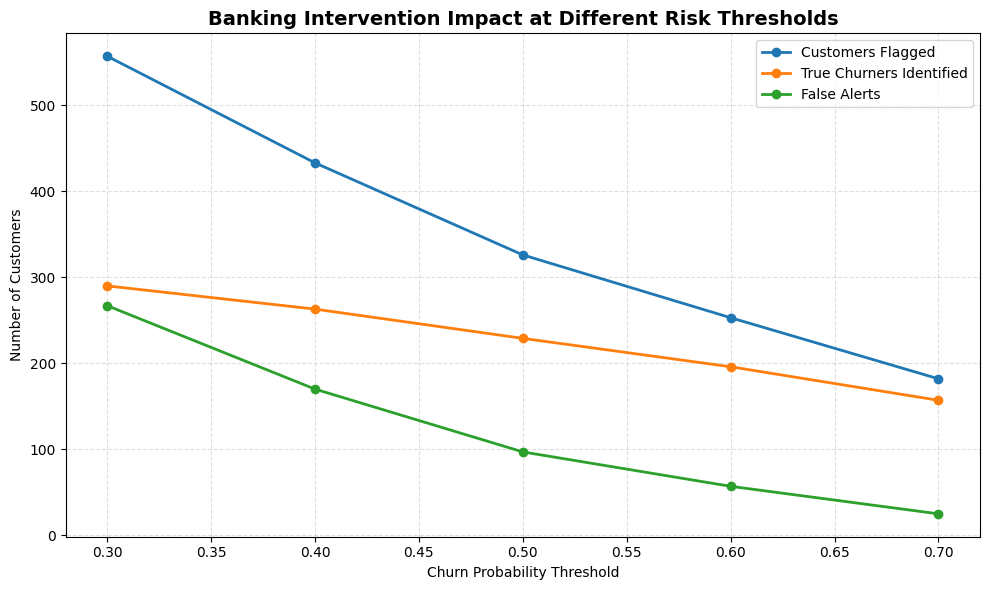

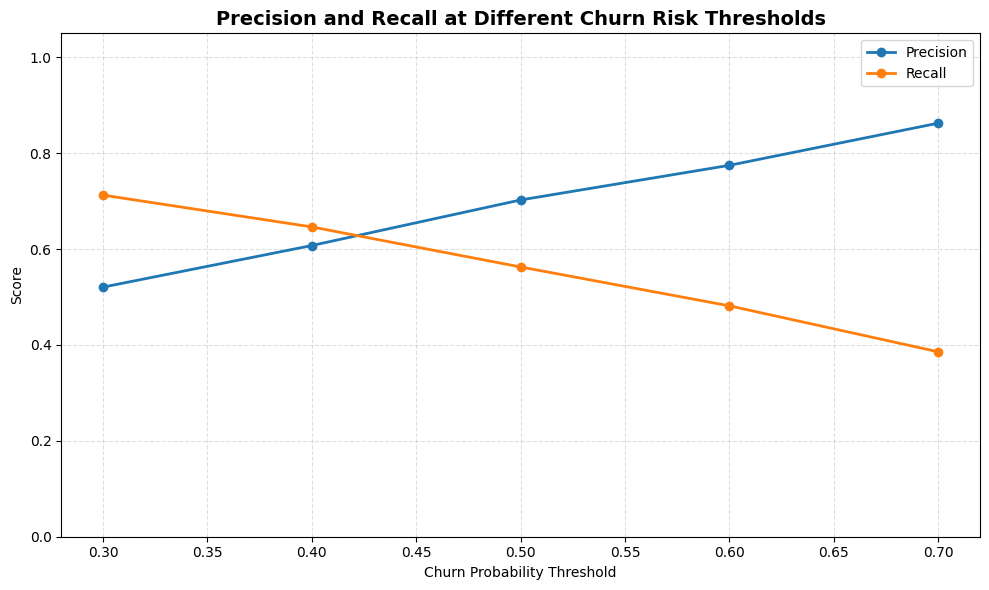


Estimated Real-World Impact per 1,000 Banking Customers


,"Scenario for 1,000 Customers",Estimated Customers,Practical Meaning
0,Expected Correct Classifications,862,Customers expected to receive the correct pred...
1,Expected Incorrect Classifications,138,Customers who could receive an incorrect predi...
2,Estimated Actual Churners,204,Estimated number of customers who may actually...
3,Estimated Churners Identified,115,Estimated churn-risk customers who could be id...
4,Estimated Churners Missed,89,Estimated churn customers who could remain uni...
5,Estimated Non-Churn Customers Correctly Identi...,748,Estimated customers correctly recognised as li...



Banking Decision-Support Application


,Banking Use Case,How the Model Supports the Banking User
0,Customer Risk Prioritisation,Ranks customers according to predicted churn p...
1,Targeted Retention,Supports targeted retention activity instead o...
2,High-Risk Customer Identification,Identifies customers with high or very high pr...
3,Resource Allocation,Helps retention teams focus limited staff time...
4,False Alert Management,Highlights the trade-off between identifying m...
5,Missed Churn Management,Shows how many actual churners may remain unid...
6,Decision Threshold Adjustment,Allows the organisation to adjust the probabil...



Advanced Real-World Banking Interpretation

1. Overall Classification Performance: The XGBoost Grid Search model achieved 86.25% accuracy. Under similar data conditions, this corresponds to approximately 862 correct classifications out of every 1,000 customers.

2. Churn Detection: The model identified 56.27% of actual churn customers. This indicates the proportion of customers at risk of leaving who could potentially be identified for retention review.

3. Missed Churn Risk: The missed churn rate was 43.73%. These customers represent potential churners who may not be identified for intervention by the predictive system.

4. False Alerts: The false alarm rate was 6.09%. These are non-churn customers who could be unnecessarily flagged for retention activity.

5. Targeted Retention: When focusing only on the top 10% highest-risk customers, the model captured 41.28% of all actual churners.

6. Lift Analysis: The Lift@10% was 4.13x. This indicates how much more concentrated actual churner

In [ ]:
# I imported the required libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    f1_score,
    roc_auc_score,
    precision_score,
    recall_score
)

# I selected the best-performing XGBoost model obtained using Grid Search.
best_banking_model = grid_xgb_best_model

# I generated class predictions using the best-performing model.
banking_pred = best_banking_model.predict(X_test_scaled)

# I generated churn probability scores for each customer.
banking_prob = best_banking_model.predict_proba(
    X_test_scaled
)[:, 1]

# I converted the actual target values into a one-dimensional NumPy array.
y_test_array = np.asarray(y_test).ravel()

# I converted the predictions and probabilities into one-dimensional arrays.
banking_pred = np.asarray(banking_pred).ravel()
banking_prob = np.asarray(banking_prob).ravel()

# I calculated the confusion matrix.
tn, fp, fn, tp = confusion_matrix(
    y_test_array,
    banking_pred
).ravel()

# I calculated the main model performance metrics.
banking_accuracy = accuracy_score(
    y_test_array,
    banking_pred
)

banking_f1 = f1_score(
    y_test_array,
    banking_pred,
    average="weighted"
)

banking_auc = roc_auc_score(
    y_test_array,
    banking_prob
)

banking_precision = precision_score(
    y_test_array,
    banking_pred,
    zero_division=0
)

banking_recall = recall_score(
    y_test_array,
    banking_pred,
    zero_division=0
)

# I calculated the total number of customers.
total_customers = len(y_test_array)

# I calculated the number of actual churn and non-churn customers.
actual_churners = int(
    np.sum(y_test_array == 1)
)

actual_non_churners = int(
    np.sum(y_test_array == 0)
)

# I calculated the number of correct and incorrect predictions.
correct_customers = tp + tn

incorrect_customers = fp + fn

# I calculated the percentage of correct and incorrect predictions.
correct_percentage = (
    correct_customers /
    total_customers
) * 100

incorrect_percentage = (
    incorrect_customers /
    total_customers
) * 100

# I calculated the percentage of actual churn customers
# correctly identified by the model.
churn_detection_rate = (
    tp / (tp + fn) * 100
    if (tp + fn) > 0
    else 0
)

# I calculated the percentage of actual non-churn customers
# correctly identified by the model.
non_churn_detection_rate = (
    tn / (tn + fp) * 100
    if (tn + fp) > 0
    else 0
)

# I calculated the false alarm rate.
false_alarm_rate = (
    fp / (fp + tn) * 100
    if (fp + tn) > 0
    else 0
)

# I calculated the missed churn rate.
missed_churn_rate = (
    fn / (fn + tp) * 100
    if (fn + tp) > 0
    else 0
)

# I created the overall real-world banking performance table.
banking_performance = pd.DataFrame({

    "Performance Measure": [
        "Accuracy",
        "Weighted F1-Score",
        "ROC-AUC",
        "Churn Precision",
        "Churn Detection Rate",
        "Non-Churn Detection Rate",
        "False Alarm Rate",
        "Missed Churn Rate"
    ],

    "Result (%)": [
        banking_accuracy * 100,
        banking_f1 * 100,
        banking_auc * 100,
        banking_precision * 100,
        churn_detection_rate,
        non_churn_detection_rate,
        false_alarm_rate,
        missed_churn_rate
    ],

    "Banking Interpretation": [

        "Percentage of all customers correctly classified by the model.",

        "Overall classification performance while accounting for both customer classes.",

        "Ability of the model to distinguish between customers with different churn outcomes.",

        "Percentage of customers predicted as churn risks who actually churned.",

        "Percentage of actual churn customers successfully identified by the model.",

        "Percentage of actual non-churn customers correctly identified by the model.",

        "Percentage of non-churn customers incorrectly flagged as churn risks.",

        "Percentage of actual churn customers missed by the predictive model."
    ]
})

print("Real-World Banking Model Performance")

display(
    banking_performance.round(2)
)

# I created a detailed customer classification outcome table.
customer_outcomes = pd.DataFrame({

    "Customer Outcome": [
        "True Positive - Correct Churn Identification",
        "True Negative - Correct Non-Churn Identification",
        "False Positive - False Churn Alert",
        "False Negative - Missed Churn Customer"
    ],

    "Number of Customers": [
        tp,
        tn,
        fp,
        fn
    ],

    "Banking Meaning": [

        "Customers correctly identified as being at risk of churn who could be prioritised for retention support.",

        "Customers correctly identified as likely to remain with the bank.",

        "Customers incorrectly flagged as churn risks, potentially creating unnecessary retention activity.",

        "At-risk customers missed by the model who may not receive a timely retention intervention."
    ]
})

print("\nCustomer-Level Classification Outcomes")

display(customer_outcomes)

# I created a customer-level risk analysis dataset.
customer_risk_analysis = pd.DataFrame({

    "Actual Outcome": y_test_array,

    "Predicted Outcome": banking_pred,

    "Churn Probability": banking_prob
})

# I classified customers into four risk categories
# based on their predicted churn probabilities.
customer_risk_analysis["Risk Level"] = pd.cut(

    customer_risk_analysis[
        "Churn Probability"
    ],

    bins=[
        0.00,
        0.30,
        0.50,
        0.70,
        1.00
    ],

    labels=[
        "Low Risk",
        "Moderate Risk",
        "High Risk",
        "Very High Risk"
    ],

    include_lowest=True
)

# I grouped customers according to their predicted risk category.
risk_summary = (

    customer_risk_analysis

    .groupby(
        "Risk Level",
        observed=True
    )

    .agg(

        Customers=(
            "Churn Probability",
            "count"
        ),

        Average_Churn_Probability=(
            "Churn Probability",
            "mean"
        ),

        Actual_Churners=(
            "Actual Outcome",
            "sum"
        )
    )

    .reset_index()
)

# I calculated the actual churn rate within each risk category.
risk_summary[
    "Actual_Churn_Rate"
] = (

    risk_summary[
        "Actual_Churners"
    ]

    /

    risk_summary[
        "Customers"
    ]

) * 100

# I converted the average predicted churn probability
# into percentage format.
risk_summary[
    "Average_Churn_Probability"
] = (

    risk_summary[
        "Average_Churn_Probability"
    ] * 100
)

# I renamed the columns after completing all calculations
# to prevent column-name errors.
risk_summary = risk_summary.rename(

    columns={

        "Average_Churn_Probability":
        "Average Churn Probability (%)",

        "Actual_Churners":
        "Actual Churners",

        "Actual_Churn_Rate":
        "Actual Churn Rate (%)"
    }
)

# I selected the final columns for presentation.
risk_summary = risk_summary[

    [
        "Risk Level",
        "Customers",
        "Average Churn Probability (%)",
        "Actual Churners",
        "Actual Churn Rate (%)"
    ]
]

print("\nCustomer Churn Risk Segmentation")

display(
    risk_summary.round(2)
)

# I calculated the percentage distribution of customers
# across the four risk categories.
risk_distribution = (

    customer_risk_analysis[
        "Risk Level"
    ]

    .value_counts(
        normalize=True
    )

    .sort_index()

    * 100
)

# I plotted the distribution of customers by predicted churn risk.
plt.figure(
    figsize=(10, 6)
)

bars = plt.bar(

    risk_distribution.index.astype(str),

    risk_distribution.values
)

# I displayed the percentage value above each bar.
for bar in bars:

    height = bar.get_height()

    plt.text(

        bar.get_x()
        + bar.get_width() / 2,

        height + 0.5,

        f"{height:.2f}%",

        ha="center",

        va="bottom",

        fontsize=10
    )

plt.title(
    "Distribution of Customers by Predicted Churn Risk",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "Customer Risk Category"
)

plt.ylabel(
    "Percentage of Customers (%)"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

plt.show()

# I sorted customers from the highest predicted churn risk
# to the lowest predicted churn risk.
ranked_customers = (

    customer_risk_analysis

    .sort_values(

        by="Churn Probability",

        ascending=False
    )

    .reset_index(
        drop=True
    )
)

# I calculated the number of customers representing
# the top 10% highest-risk group.
top_10_count = max(

    1,

    int(
        len(ranked_customers)
        * 0.10
    )
)

# I selected the top 10% highest-risk customers.
top_10_risk_customers = (

    ranked_customers

    .head(
        top_10_count
    )
)

# I calculated the number of actual churners captured
# within the top 10% highest-risk customers.
top_10_churners_captured = int(

    top_10_risk_customers[
        "Actual Outcome"
    ].sum()
)

# I calculated the percentage of all actual churners
# captured within the top 10% risk group.
capture_rate_top_10 = (

    top_10_churners_captured
    / actual_churners
    * 100

    if actual_churners > 0

    else 0
)

# I calculated the overall churn rate.
overall_churn_rate = (

    actual_churners
    / total_customers

    if total_customers > 0

    else 0
)

# I calculated the actual churn rate
# among the top 10% highest-risk customers.
top_10_churn_rate = (

    top_10_risk_customers[
        "Actual Outcome"
    ].mean()

    if len(
        top_10_risk_customers
    ) > 0

    else 0
)

# I calculated Lift at 10%.
lift_at_10 = (

    top_10_churn_rate
    / overall_churn_rate

    if overall_churn_rate > 0

    else 0
)

# I created the targeted customer retention analysis table.
targeting_analysis = pd.DataFrame({

    "Business Measure": [

        "Customers in Top 10% Risk Group",

        "Actual Churners Captured in Top 10%",

        "Capture Rate at Top 10%",

        "Overall Customer Churn Rate",

        "Churn Rate in Top 10% Risk Group",

        "Lift at Top 10%"
    ],

    "Result": [

        str(
            top_10_count
        ),

        str(
            top_10_churners_captured
        ),

        f"{capture_rate_top_10:.2f}%",

        f"{overall_churn_rate * 100:.2f}%",

        f"{top_10_churn_rate * 100:.2f}%",

        f"{lift_at_10:.2f}x"
    ],

    "Banking Meaning": [

        "Number of customers the retention team would need to prioritise when focusing only on the highest-risk 10%.",

        "Number of actual churn customers successfully concentrated within the highest-risk 10%.",

        "Percentage of all actual churners identified by targeting only the highest-risk 10% of customers.",

        "Baseline proportion of customers who actually churn.",

        "Concentration of actual churners among customers ranked as the highest risk.",

        "Shows how much more effectively the model identifies churners in the top-risk group compared with untargeted customer selection."
    ]
})

print(
    "\nTargeted Customer Retention Analysis"
)

display(
    targeting_analysis
)

# I defined different probability thresholds
# to analyse alternative banking intervention strategies.
thresholds = [

    0.30,
    0.40,
    0.50,
    0.60,
    0.70
]

# I created an empty list to store threshold results.
threshold_results = []

# I evaluated model performance at each probability threshold.
for threshold in thresholds:

    # I converted probabilities into predictions
    # using the selected threshold.
    threshold_predictions = (

        banking_prob
        >= threshold

    ).astype(int)

    # I calculated the confusion matrix
    # at the selected threshold.
    threshold_tn, \
    threshold_fp, \
    threshold_fn, \
    threshold_tp = confusion_matrix(

        y_test_array,

        threshold_predictions

    ).ravel()

    # I calculated precision at the selected threshold.
    threshold_precision = (

        threshold_tp

        /

        (
            threshold_tp
            + threshold_fp
        )

        if (
            threshold_tp
            + threshold_fp
        ) > 0

        else 0
    )

    # I calculated recall at the selected threshold.
    threshold_recall = (

        threshold_tp

        /

        (
            threshold_tp
            + threshold_fn
        )

        if (
            threshold_tp
            + threshold_fn
        ) > 0

        else 0
    )

    # I calculated the total number of customers
    # that would be flagged for intervention.
    customers_flagged = (

        threshold_tp
        + threshold_fp
    )

    # I calculated the percentage of all customers
    # that would be flagged.
    customers_flagged_percentage = (

        customers_flagged
        / total_customers
        * 100

        if total_customers > 0

        else 0
    )

    # I stored the threshold results.
    threshold_results.append({

        "Threshold":
        threshold,

        "Customers Flagged":
        customers_flagged,

        "Customers Flagged (%)":
        customers_flagged_percentage,

        "True Churners Identified":
        threshold_tp,

        "Missed Churners":
        threshold_fn,

        "False Alerts":
        threshold_fp,

        "Precision":
        threshold_precision,

        "Recall":
        threshold_recall
    })

# I converted the threshold results into a DataFrame.
threshold_analysis = pd.DataFrame(
    threshold_results
)

print(
    "\nBanking Intervention Threshold Analysis"
)

display(
    threshold_analysis.round(4)
)

# I plotted the impact of different thresholds
# on banking intervention workload.
plt.figure(
    figsize=(10, 6)
)

plt.plot(

    threshold_analysis[
        "Threshold"
    ],

    threshold_analysis[
        "Customers Flagged"
    ],

    marker="o",

    linewidth=2,

    label="Customers Flagged"
)

plt.plot(

    threshold_analysis[
        "Threshold"
    ],

    threshold_analysis[
        "True Churners Identified"
    ],

    marker="o",

    linewidth=2,

    label="True Churners Identified"
)

plt.plot(

    threshold_analysis[
        "Threshold"
    ],

    threshold_analysis[
        "False Alerts"
    ],

    marker="o",

    linewidth=2,

    label="False Alerts"
)

plt.title(
    "Banking Intervention Impact at Different Risk Thresholds",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "Churn Probability Threshold"
)

plt.ylabel(
    "Number of Customers"
)

plt.legend()

plt.grid(
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

plt.show()

# I created a second threshold graph
# comparing precision and recall.
plt.figure(
    figsize=(10, 6)
)

plt.plot(

    threshold_analysis[
        "Threshold"
    ],

    threshold_analysis[
        "Precision"
    ],

    marker="o",

    linewidth=2,

    label="Precision"
)

plt.plot(

    threshold_analysis[
        "Threshold"
    ],

    threshold_analysis[
        "Recall"
    ],

    marker="o",

    linewidth=2,

    label="Recall"
)

plt.title(
    "Precision and Recall at Different Churn Risk Thresholds",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "Churn Probability Threshold"
)

plt.ylabel(
    "Score"
)

plt.ylim(
    0,
    1.05
)

plt.legend()

plt.grid(
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

plt.show()

# I estimated the practical model impact
# for every 1,000 banking customers.
example_customers = 1000

# I estimated how many customers would be classified correctly.
estimated_correct = round(

    banking_accuracy
    * example_customers
)

# I estimated how many customers would be classified incorrectly.
estimated_incorrect = (

    example_customers
    - estimated_correct
)

# I estimated the number of actual churners
# among every 1,000 customers.
estimated_churners = round(

    overall_churn_rate
    * example_customers
)

# I estimated how many churners would be identified.
estimated_churners_detected = round(

    estimated_churners
    * banking_recall
)

# I estimated how many churners could be missed.
estimated_churners_missed = (

    estimated_churners
    - estimated_churners_detected
)

# I estimated the number of non-churn customers.
estimated_non_churners = (

    example_customers
    - estimated_churners
)

# I estimated correctly identified non-churn customers.
estimated_non_churn_correct = round(

    estimated_non_churners

    * (
        non_churn_detection_rate
        / 100
    )
)

# I created the 1,000-customer practical scenario table.
customer_scenario = pd.DataFrame({

    "Scenario for 1,000 Customers": [

        "Expected Correct Classifications",

        "Expected Incorrect Classifications",

        "Estimated Actual Churners",

        "Estimated Churners Identified",

        "Estimated Churners Missed",

        "Estimated Non-Churn Customers Correctly Identified"
    ],

    "Estimated Customers": [

        estimated_correct,

        estimated_incorrect,

        estimated_churners,

        estimated_churners_detected,

        estimated_churners_missed,

        estimated_non_churn_correct
    ],

    "Practical Meaning": [

        "Customers expected to receive the correct predictive classification under similar data conditions.",

        "Customers who could receive an incorrect predictive classification.",

        "Estimated number of customers who may actually churn.",

        "Estimated churn-risk customers who could be identified for possible retention intervention.",

        "Estimated churn customers who could remain unidentified by the model.",

        "Estimated customers correctly recognised as likely to remain with the bank."
    ]
})

print(
    "\nEstimated Real-World Impact per 1,000 Banking Customers"
)

display(
    customer_scenario
)

# I created a model decision-support summary table.
banking_decision_support = pd.DataFrame({

    "Banking Use Case": [

        "Customer Risk Prioritisation",

        "Targeted Retention",

        "High-Risk Customer Identification",

        "Resource Allocation",

        "False Alert Management",

        "Missed Churn Management",

        "Decision Threshold Adjustment"
    ],

    "How the Model Supports the Banking User": [

        "Ranks customers according to predicted churn probability so staff can prioritise higher-risk customers.",

        "Supports targeted retention activity instead of applying the same intervention to every customer.",

        "Identifies customers with high or very high predicted churn risk for further review.",

        "Helps retention teams focus limited staff time and resources on customers with greater predicted risk.",

        "Highlights the trade-off between identifying more churners and unnecessarily contacting non-churn customers.",

        "Shows how many actual churners may remain unidentified, helping users understand model limitations.",

        "Allows the organisation to adjust the probability threshold according to retention capacity and business priorities."
    ]
})

print(
    "\nBanking Decision-Support Application"
)

display(
    banking_decision_support
)

# I displayed the final advanced interpretation.
print(
    "\nAdvanced Real-World Banking Interpretation"
)

print(
    f"\n1. Overall Classification Performance: "
    f"The XGBoost Grid Search model achieved "
    f"{banking_accuracy * 100:.2f}% accuracy. "
    f"Under similar data conditions, this corresponds to approximately "
    f"{estimated_correct} correct classifications out of every "
    f"1,000 customers."
)

print(
    f"\n2. Churn Detection: "
    f"The model identified "
    f"{churn_detection_rate:.2f}% of actual churn customers. "
    f"This indicates the proportion of customers at risk of leaving "
    f"who could potentially be identified for retention review."
)

print(
    f"\n3. Missed Churn Risk: "
    f"The missed churn rate was "
    f"{missed_churn_rate:.2f}%. "
    f"These customers represent potential churners who may not be "
    f"identified for intervention by the predictive system."
)

print(
    f"\n4. False Alerts: "
    f"The false alarm rate was "
    f"{false_alarm_rate:.2f}%. "
    f"These are non-churn customers who could be unnecessarily "
    f"flagged for retention activity."
)

print(
    f"\n5. Targeted Retention: "
    f"When focusing only on the top 10% highest-risk customers, "
    f"the model captured "
    f"{capture_rate_top_10:.2f}% of all actual churners."
)

print(
    f"\n6. Lift Analysis: "
    f"The Lift@10% was "
    f"{lift_at_10:.2f}x. "
    f"This indicates how much more concentrated actual churners were "
    f"in the highest-risk 10% compared with selecting customers "
    f"without using the model's risk ranking."
)

print(
    "\n7. Risk Segmentation: "
    "Customers were grouped into Low, Moderate, High, and Very High "
    "risk categories based on predicted churn probability. "
    "This can provide banking users with a prioritised view rather "
    "than only a binary churn or non-churn prediction."
)

print(
    "\n8. Threshold-Based Decision Support: "
    "The threshold analysis demonstrates that the banking application "
    "does not need to rely only on the default 0.50 threshold. "
    "Lower thresholds generally identify more potential churners but "
    "can increase false alerts and intervention workload. Higher "
    "thresholds focus on customers with stronger predicted risk but "
    "may result in more churners being missed."
)

print(
    "\n9. Practical Application: "
    "The model can support customer-retention teams by ranking customers "
    "according to predicted churn risk, identifying high-priority cases, "
    "and supporting more targeted allocation of retention resources."
)

print(
    "\n10. Decision-Support Limitation: "
    "The predictions should be treated as decision-support information. "
    "Customer-level actions should not be determined solely by the model, "
    "particularly where incorrect predictions could affect customers."
)